![alt text](./Cerny_logo_1.jpg)

# Analysis of Cerny ventilation recordings

## Yearly comparison of ventilator data for quality improvement indicators

 Author: Dr Gusztav Belteki

Study period: Every year between 2017 - 2025. Ventilator data recording started at 20/03/2017 and ended at 23/08/2025. Recordings `AL000001 - AL001100` and `AT000001 - AT001942`. Infants receiving  mechanical ventilation via endotracheal tube.

**Quality indicators:**

- QI-1. Proportion of infants ventilated with conventional mechanical ventilation modes during transport who had **the volume guarantee option switched-on for >50% of the time**. 
- QI-1A. As Q1 but for a subgroup of infants born at <32 weeks gestation <14 days of age
- QI-2. Proportion of infants receiving **conventional ventilation with volume guarantee who had the set target expired tidal volume between 4-6 mL/kg** for >90% of the time
- QI-3. Proportion infants ventilated with **conventional ventilation without volume guarantee where the mean expired tidal volume between 4-6 mL/kg**
- QI-4. Proportion of infants ventilated using **conventional ventilation with volume guarantee where the median difference between Pmax and PIP was 5-15 cmH2O.**
- QI-5. Proportion of infants when **in the blood gases at arrival the pCO2 was >30 mmHg (4kPa) AND either pCO2 was <52.5 mmHg (7 kPa) or pH was >7.2**
- QI-6. Percentage of **time spent with active ventilator alarms**


### 1. Import the required libraries and set options

In [5]:
!conda info --envs


# conda environments:
#
base                 * /Users/guszti/opt/anaconda3
LLMs                   /Users/guszti/opt/anaconda3/envs/LLMs
dgai                   /Users/guszti/opt/anaconda3/envs/dgai
dgai2                  /Users/guszti/opt/anaconda3/envs/dgai2
homlp                  /Users/guszti/opt/anaconda3/envs/homlp
introp3                /Users/guszti/opt/anaconda3/envs/introp3
jupyter-ai             /Users/guszti/opt/anaconda3/envs/jupyter-ai
pvi                    /Users/guszti/opt/anaconda3/envs/pvi
ventilation            /Users/guszti/opt/anaconda3/envs/ventilation



In [6]:
import IPython
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as dates

import os
import sys
import pickle

from scipy import stats
from pandas import Series, DataFrame
from datetime import datetime, timedelta
from collections import defaultdict

%matplotlib inline
matplotlib.style.use('classic')
matplotlib.rcParams['figure.facecolor'] = 'w'

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('future.no_silent_downcasting', True)
pd.set_option('mode.chained_assignment', None) 

In [7]:
print("Python version: {}".format(sys.version))
print("pandas version: {}".format(pd.__version__))
print("matplotlib version: {}".format(matplotlib.__version__))
print("NumPy version: {}".format(np.__version__))
print("IPython version: {}".format(IPython.__version__))

Python version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:22:19) [Clang 14.0.6 ]
pandas version: 2.2.2
matplotlib version: 3.9.2
NumPy version: 1.26.4
IPython version: 8.27.0


### 2. List and set the working directory and the directory to write out data

In [9]:
# Topic of the Notebook which will also be the name of the subfolder containing results
TOPIC = 'Quality_improvement'

# Name of the external hard drive
DRIVE = 'GB_1'

# Path to project folder containing ventilation research results
PATH = os.path.join(os.sep, 'Users', 'guszti', 'Library', 'Mobile Documents', 'com~apple~CloudDocs', 
                            'Documents', 'Research', 'Ventilation')

# Folders to read ventilator data from
# Data from the old fabian (fabian +ncpap)
DIR_READ_1 = os.path.join(os.sep, 'Volumes', DRIVE, 'data_dump', 'fabian')
# Data from the new fabian (fabian HFOi)
DIR_READ_2 = os.path.join(os.sep, 'Volumes', DRIVE, 'data_dump', 'fabian_new')
# Some data from both dataset
DIR_READ_3 = os.path.join(os.sep, 'Volumes', DRIVE, 'data_dump', 'fabian_combined', 'Analysis_all_upto_AT001942')

# Folder to export the result of analysis
DIR_WRITE = os.path.join(PATH, 'ventilation_fabian_combined', 'Analyses', TOPIC)
os.makedirs(DIR_WRITE, exist_ok = True)

# Images and raw data will be written on an external hard drive
DATA_DUMP = os.path.join(os.sep, 'Volumes', DRIVE, 'data_dump', 'fabian_combined', TOPIC)
os.makedirs(DATA_DUMP, exist_ok=True)

DIR_READ_1, DIR_READ_2, DIR_READ_3, DIR_WRITE, DATA_DUMP

('/Volumes/GB_1/data_dump/fabian',
 '/Volumes/GB_1/data_dump/fabian_new',
 '/Volumes/GB_1/data_dump/fabian_combined/Analysis_all_upto_AT001942',
 '/Users/guszti/Library/Mobile Documents/com~apple~CloudDocs/Documents/Research/Ventilation/ventilation_fabian_combined/Analyses/Quality_improvement',
 '/Volumes/GB_1/data_dump/fabian_combined/Quality_improvement')

### 3. Import ventilator data

#### A. All recordings where ventilator and clinical data are available

Ventilator data can be of any length and include segments when the infant was not connected to the ventilator (unedited / untrimmed ventilator data)

In [12]:
with open(os.path.join(DIR_READ_3, 'ventilation_modes.pickle'), 'rb') as handle:
    ventilation_modes_all = pickle.load(handle)
# Total number of cases with downloaded ventilator data
len(ventilation_modes_all)

2504

#### B. Ventilated recordings

All these recordings have >10 minutes of mechanical ventilation after manual review and removal of parts from the beginning and the end when the infant was not connected to the ventilator

In [14]:
with open(os.path.join(DIR_READ_1, 'data_pars_measurements_ventilated_1_1100.pickle'), 'rb') as handle:
    measurements_old = pickle.load(handle)
with open(os.path.join(DIR_READ_1, 'data_pars_settings_ventilated_1_1100.pickle'), 'rb') as handle:
    settings_old = pickle.load(handle)
with open(os.path.join(DIR_READ_1, 'data_pars_alarms_ventilated_1_1100.pickle'), 'rb') as handle:
    alarms_old = pickle.load(handle)
   
with open(os.path.join(DIR_READ_2, 'data_pars_measurements_ventilated_new.pickle'), 'rb') as handle:
    measurements_new = pickle.load(handle)
with open(os.path.join(DIR_READ_2, 'data_pars_settings_ventilated_new.pickle'), 'rb') as handle:
    settings_new = pickle.load(handle)
with open(os.path.join(DIR_READ_2, 'data_pars_alarms_ventilated_new.pickle'), 'rb') as handle:
    alarms_new = pickle.load(handle)

measurements_ventilated = {**measurements_old, **measurements_new}
settings_ventilated = {**settings_old, **settings_new}
alarms_ventilated = {**alarms_old, **alarms_new}
len(measurements_ventilated), len(settings_ventilated), len(alarms_ventilated)

(1206, 1206, 1206)

Exclude those recordings which have been collected after the end date of the study

In [16]:
# Recordings collected after the end date of the study (23/08/2025)
recs_after_end_date = []
for recording in measurements_ventilated.keys():
    if recording[1] == 'T' and int(recording[2:].lstrip('0')) > 1942:
        recs_after_end_date.append(recording)
recs_after_end_date;

In [17]:
measurements_ventilated = {recording:dta for recording, dta in measurements_ventilated.items() if recording not in recs_after_end_date}
settings_ventilated = {recording:dta for recording, dta in settings_ventilated.items() if recording not in recs_after_end_date}
alarms_ventilated = {recording:dta for recording, dta in alarms_ventilated.items() if recording not in recs_after_end_date}

len(measurements_ventilated), len(settings_ventilated), len(alarms_ventilated)

(1104, 1104, 1104)

### 4. Import Clinical data and blood gases

#### A. Clinical data

In [20]:
with open(os.path.join(DIR_READ_1, 'clin_df_1_1100.pickle'), 'rb') as handle:
    clin_df_old = pickle.load(handle)
with open(os.path.join(DIR_READ_2, 'clin_df_new.pickle'), 'rb') as handle:
    clin_df_new = pickle.load(handle)

clinical_data_all = pd.concat([clin_df_old, clin_df_new])
clinical_data_all['Birth Weight'] = clinical_data_all['Birth Weight'].astype(float)

# Limit clinical data to recordings with ventilator data
clinical_data = clinical_data_all.loc[measurements_ventilated.keys()]
len(clinical_data_all), len(clinical_data)

(2628, 1104)

#### B. Total number of ventilated cases transferred by the service in each year

In [22]:
service_activity = pd.read_excel(os.path.join(DIR_WRITE, 'Cerny_ventilated_activity.xlsx'), index_col='Year')
service_activity

,Number of cases
Year,
2017,348
2018,431
2019,490
2020,321
2021,435
2022,407
2023,341
2024,365
2025,215


#### C. Blood gases

In [24]:
with open(os.path.join(DIR_READ_1, 'blood_gases_1_1100.pickle'), 'rb') as handle:
    blood_gases_old = pickle.load(handle)
with open(os.path.join(DIR_READ_2, 'blood_gases_new.pickle'), 'rb') as handle:
    blood_gases_new = pickle.load(handle)

blood_gases = {**blood_gases_old, **blood_gases_new,}
for case in blood_gases:
    blood_gases[case] = blood_gases[case].reset_index()

# Limit blood gases to recordings with ventilator data
blood_gases = {case: dta for case, dta in blood_gases.items() if case in measurements_ventilated.keys()}
len(blood_gases)

1060

### 5. Identify the proportion of ventilated cases among all recordings

In [26]:
# Clinical data is available for all of them 
len(ventilation_modes_all), len(set(ventilation_modes_all.index) & set(clinical_data_all.index))

(2504, 2504)

In [27]:
ventilation_modes_all.columns

Index(['CPAP_unedited', 'DUOPAP_unedited', 'IPPV_unedited', 'NCPAP_unedited',
       'O2therapy_unedited', 'PSV_unedited', 'SIMV_unedited',
       'SIMVPSV_unedited', 'SIPPV_unedited', 'ventilation_unedited',
       'noninvasive_unedited', 'total_unedited', 'HFO_unedited', 'VG_unedited',
       'IPPV_trimmed_ventilated', 'PSV_trimmed_ventilated',
       'SIMV_trimmed_ventilated', 'SIMVPSV_trimmed_ventilated',
       'SIPPV_trimmed_ventilated', 'VG_off_trimmed_ventilated',
       'VG_on_trimmed_ventilated', 'total_trimmed_ventilated',
       'HFO_trimmed_ventilated', 'VG_trimmed_ventilated',
       'CPAP_trimmed_noninvasive', 'DUOPAP_trimmed_noninvasive',
       'NCPAP_trimmed_noninvasive', 'O2therapy_trimmed_noninvasive',
       'total_trimmed_noninvasive', 'total_trimmed'],
      dtype='object')

In [28]:
noninvasive_recordings = ventilation_modes_all[(ventilation_modes_all['total_trimmed_ventilated'] < 600) & 
                                               (ventilation_modes_all['total_trimmed_noninvasive'] >= 600)]
len(noninvasive_recordings)

1347

In [29]:
ventilated_recordings = ventilation_modes_all[(ventilation_modes_all['total_trimmed_ventilated'] >= 600) | 
                                               (ventilation_modes_all['total_trimmed_noninvasive'] < 600)]
len(ventilated_recordings)

1157

In [30]:
# Longer than 10 minutes of mechanical ventilation after trimming
len(ventilated_recordings[ventilated_recordings['total_trimmed_ventilated'] >= 600])

1104

### 6. Exclude infants whose postmenstrual age exceeded 46 weeks

In [32]:
len(clinical_data[clinical_data['Corrected gestational Age (weeks)'] >= 46])

69

In [33]:
# The final dataset
clinical_data = clinical_data[clinical_data['Corrected gestational Age (weeks)'] < 46]
len(clinical_data)

1035

### 7. Identify incorrect clinical data and correct them if possible

In [35]:
# Check if there are data errors identified as major discrepancy between gestation and weight
pot_abnormal_weight_1 = clinical_data[(clinical_data['Corrected gestational Age (weeks)'] < 29) & (clinical_data['Weight'] > 1500)]
pot_abnormal_weight_1

,Case ID,Date of Birth,Gestational Age (weeks),Birth Weight,Postnatal Age,Corrected gestational Age (weeks),Weight,ICD,Pathology_English,Recording start,Recording end,Duration
AL000132,44119,2017-08-09 00:30:00,26.0,750.0,10 days 18:43:48,27.5,1785.0,"[P072, P369, P704, P523, P015]","[Extreme immaturity of newborn, unspecified we...",2017-08-19 18:26:56,2017-08-19 19:13:48,0 days 00:46:52
AL000475,50297,2019-03-21 00:00:00,27.0,3646.0,0 days 18:49:43,27.1,3646.0,"[P964, P293, P399, P159]","[Term newborn, Persistent fetal circulation, I...",2019-03-21 17:55:27,2019-03-21 18:49:43,0 days 00:54:16
AT000935,62200,2023-01-09 01:27:00,26.0,4090.0,0 days 04:22:42,26.0,4090.0,"[P072, P22, _000, R571]","[Extreme immaturity of newborn, unspecified we...",2023-01-09 02:49:56,2023-01-09 05:49:42,0 days 02:59:46


In [36]:
# Check if there are data errors identified as major discrepancy between gestation and weight
pot_abnormal_weight_2 = clinical_data[(clinical_data['Corrected gestational Age (weeks)'] < 33) & (clinical_data['Weight'] > 2500)]
pot_abnormal_weight_2

,Case ID,Date of Birth,Gestational Age (weeks),Birth Weight,Postnatal Age,Corrected gestational Age (weeks),Weight,ICD,Pathology_English,Recording start,Recording end,Duration
AL000475,50297,2019-03-21 00:00:00,27.0,3646.0,0 days 18:49:43,27.1,3646.0,"[P964, P293, P399, P159]","[Term newborn, Persistent fetal circulation, I...",2019-03-21 17:55:27,2019-03-21 18:49:43,0 days 00:54:16
AT000263,57494,2021-06-03 14:09:00,32.0,2650.0,0 days 08:50:19,32.1,2650.0,"[P073, P22, R100, _000]","[Preterm newborn, unspecified weeks of gestati...",2021-06-03 22:18:17,2021-06-03 22:59:19,0 days 00:41:02
AT000463,58626,2021-10-18 02:25:00,32.0,3650.0,0 days 13:36:09,32.1,3650.0,"[P073, P8302, _000, Q621]","[Preterm newborn, unspecified weeks of gestati...",2021-10-18 15:25:39,2021-10-18 16:01:09,0 days 00:35:30
AT000517,58953,2021-11-23 21:38:00,32.0,2540.0,0 days 23:20:08,32.1,2540.0,"[P073, P8302, _000]","[Preterm newborn, unspecified weeks of gestati...",2021-11-24 20:20:45,2021-11-24 20:58:08,0 days 00:37:23
AT000935,62200,2023-01-09 01:27:00,26.0,4090.0,0 days 04:22:42,26.0,4090.0,"[P072, P22, _000, R571]","[Extreme immaturity of newborn, unspecified we...",2023-01-09 02:49:56,2023-01-09 05:49:42,0 days 02:59:46
AT001310,65897,2024-05-10 05:41:00,32.0,3100.0,0 days 09:30:47,32.1,3100.0,"[P073, P832, N179, G709, Q336]","[Preterm newborn, unspecified weeks of gestati...",2024-05-10 14:10:31,2024-05-10 15:11:47,0 days 01:01:16


In [37]:
# Check if there are data errors identified as major discrepancy between gestation and weight
pot_abnormal_weight_3 = clinical_data[(clinical_data['Corrected gestational Age (weeks)'] > 36) & 
                   (clinical_data['Weight'] < 2000)].sort_values('Weight')
pot_abnormal_weight_3

,Case ID,Date of Birth,Gestational Age (weeks),Birth Weight,Postnatal Age,Corrected gestational Age (weeks),Weight,ICD,Pathology_English,Recording start,Recording end,Duration
AL001040,55306,2020-08-18 02:00:00,37.0,1100.0,0 days 03:21:12,37.0,1100.0,"[P22, P964, P059, P021, _000]","[Respiratory distress syndrome of newborn , Te...",2020-08-18 02:59:05,2020-08-18 05:21:12,0 days 02:22:07
AL000491,50453,2019-01-31 00:00:00,36.0,1490.0,68 days 12:22:42,45.8,1490.0,"[P073, Q900, P290, P271, I500, Q212]","[Preterm newborn, unspecified weeks of gestati...",2019-04-09 10:02:15,2019-04-09 12:22:42,0 days 02:20:27
AT001428,66496,2024-07-21 10:00:00,39.0,1650.0,0 days 01:54:47,39.0,1650.0,"[P219, P059, P809, P073]","[Perinatal asphyxia, Newborn affected by slow ...",2024-07-21 11:20:29,2024-07-21 11:54:47,0 days 00:34:18
AT001444,66588,2024-07-03 00:00:00,32.0,1380.0,29 days 11:48:02,36.2,1680.0,"[P073, P285, P942, P612, G939]","[Preterm newborn, unspecified weeks of gestati...",2024-08-01 10:54:32,2024-08-01 11:48:02,0 days 00:53:30
AT000722,60274,2022-03-21 00:00:00,33.0,1360.0,71 days 14:43:33,43.2,1730.0,"[P073, _000, Q251, P399, D849]","[Preterm newborn, unspecified weeks of gestati...",2022-05-31 13:18:08,2022-05-31 14:43:33,0 days 01:25:25
AT001029,62712,2023-03-17 10:40:00,37.0,1770.0,0 days 04:38:29,37.0,1770.0,"[Q790, P285, P809, _000, P964]","[Congenital diaphragmatic hernia, Respiratory ...",2023-03-17 12:16:02,2023-03-17 15:18:29,0 days 03:02:27
AT001270,65659,2024-01-26 00:00:00,31.0,600.0,77 days 11:54:39,42.1,1820.0,"[P0734, P015, P271, K409, H351]","[Preterm newborn, gestational age 31 completed...",2024-04-12 11:13:43,2024-04-12 11:54:39,0 days 00:40:56
AT001448,66606,2024-07-03 00:00:00,32.0,1380.0,30 days 19:08:14,36.4,1860.0,"[G709, P073]","[Myoneural disorder, unspecified, Preterm newb...",2024-08-02 18:20:13,2024-08-02 19:08:14,0 days 00:48:01
AL000100,43779,2017-04-01 00:00:00,25.0,490.0,114 days 09:18:56,41.3,1890.0,"[H351, P271]","[Retinopathy of prematurity, unspecified, Bron...",2017-07-24 08:35:40,2017-07-24 09:18:56,0 days 00:43:16
AL000101,43781,2017-04-01 00:00:00,25.0,490.0,114 days 11:49:54,41.4,1890.0,"[H351, P271]","[Retinopathy of prematurity, unspecified, Bron...",2017-07-24 11:08:10,2017-07-24 11:49:54,0 days 00:41:44


In [38]:
# Manually review these recordings which are most likely abnormal
pot_abnormal_weight = pd.concat([pot_abnormal_weight_1, pot_abnormal_weight_2, pot_abnormal_weight_3]).sort_index()
pot_abnormal_weight = pot_abnormal_weight[~pot_abnormal_weight.index.duplicated()]
len(pot_abnormal_weight)

20

In [39]:
pot_abnormal_weight

,Case ID,Date of Birth,Gestational Age (weeks),Birth Weight,Postnatal Age,Corrected gestational Age (weeks),Weight,ICD,Pathology_English,Recording start,Recording end,Duration
AL000100,43779,2017-04-01 00:00:00,25.0,490.0,114 days 09:18:56,41.3,1890.0,"[H351, P271]","[Retinopathy of prematurity, unspecified, Bron...",2017-07-24 08:35:40,2017-07-24 09:18:56,0 days 00:43:16
AL000101,43781,2017-04-01 00:00:00,25.0,490.0,114 days 11:49:54,41.4,1890.0,"[H351, P271]","[Retinopathy of prematurity, unspecified, Bron...",2017-07-24 11:08:10,2017-07-24 11:49:54,0 days 00:41:44
AL000132,44119,2017-08-09 00:30:00,26.0,750.0,10 days 18:43:48,27.5,1785.0,"[P072, P369, P704, P523, P015]","[Extreme immaturity of newborn, unspecified we...",2017-08-19 18:26:56,2017-08-19 19:13:48,0 days 00:46:52
AL000475,50297,2019-03-21 00:00:00,27.0,3646.0,0 days 18:49:43,27.1,3646.0,"[P964, P293, P399, P159]","[Term newborn, Persistent fetal circulation, I...",2019-03-21 17:55:27,2019-03-21 18:49:43,0 days 00:54:16
AL000491,50453,2019-01-31 00:00:00,36.0,1490.0,68 days 12:22:42,45.8,1490.0,"[P073, Q900, P290, P271, I500, Q212]","[Preterm newborn, unspecified weeks of gestati...",2019-04-09 10:02:15,2019-04-09 12:22:42,0 days 02:20:27
AL000642,51874,2019-05-16 15:13:00,27.0,460.0,93 days 01:11:18,40.3,1890.0,"[P77, P271, A419, P285]","[Necrotizing enterocolitis of newborn, Broncho...",2019-08-17 15:36:38,2019-08-17 16:24:18,0 days 00:47:40
AL001040,55306,2020-08-18 02:00:00,37.0,1100.0,0 days 03:21:12,37.0,1100.0,"[P22, P964, P059, P021, _000]","[Respiratory distress syndrome of newborn , Te...",2020-08-18 02:59:05,2020-08-18 05:21:12,0 days 02:22:07
AT000252,57426,2021-05-26 08:45:00,38.0,1930.0,0 days 03:02:43,38.0,1930.0,"[P964, P219, P22, _000]","[Term newborn, Perinatal asphyxia, Respiratory...",2021-05-26 09:59:26,2021-05-26 11:47:43,0 days 01:48:17
AT000263,57494,2021-06-03 14:09:00,32.0,2650.0,0 days 08:50:19,32.1,2650.0,"[P073, P22, R100, _000]","[Preterm newborn, unspecified weeks of gestati...",2021-06-03 22:18:17,2021-06-03 22:59:19,0 days 00:41:02
AT000463,58626,2021-10-18 02:25:00,32.0,3650.0,0 days 13:36:09,32.1,3650.0,"[P073, P8302, _000, Q621]","[Preterm newborn, unspecified weeks of gestati...",2021-10-18 15:25:39,2021-10-18 16:01:09,0 days 00:35:30


In [40]:
# After manual review limit it to the ones truly abnormal / infeasible
pot_abnormal_weight_rev = ['AL000132',  'AL000475', 'AL000491',  'AL001040', 'AT000463', 'AT000935', 'AT001310',]
pot_abnormal_weight_rev = pot_abnormal_weight.loc[pot_abnormal_weight_rev]
len(pot_abnormal_weight_rev)

7

In [41]:
pot_abnormal_weight_rev

,Case ID,Date of Birth,Gestational Age (weeks),Birth Weight,Postnatal Age,Corrected gestational Age (weeks),Weight,ICD,Pathology_English,Recording start,Recording end,Duration
AL000132,44119,2017-08-09 00:30:00,26.0,750.0,10 days 18:43:48,27.5,1785.0,"[P072, P369, P704, P523, P015]","[Extreme immaturity of newborn, unspecified we...",2017-08-19 18:26:56,2017-08-19 19:13:48,0 days 00:46:52
AL000475,50297,2019-03-21 00:00:00,27.0,3646.0,0 days 18:49:43,27.1,3646.0,"[P964, P293, P399, P159]","[Term newborn, Persistent fetal circulation, I...",2019-03-21 17:55:27,2019-03-21 18:49:43,0 days 00:54:16
AL000491,50453,2019-01-31 00:00:00,36.0,1490.0,68 days 12:22:42,45.8,1490.0,"[P073, Q900, P290, P271, I500, Q212]","[Preterm newborn, unspecified weeks of gestati...",2019-04-09 10:02:15,2019-04-09 12:22:42,0 days 02:20:27
AL001040,55306,2020-08-18 02:00:00,37.0,1100.0,0 days 03:21:12,37.0,1100.0,"[P22, P964, P059, P021, _000]","[Respiratory distress syndrome of newborn , Te...",2020-08-18 02:59:05,2020-08-18 05:21:12,0 days 02:22:07
AT000463,58626,2021-10-18 02:25:00,32.0,3650.0,0 days 13:36:09,32.1,3650.0,"[P073, P8302, _000, Q621]","[Preterm newborn, unspecified weeks of gestati...",2021-10-18 15:25:39,2021-10-18 16:01:09,0 days 00:35:30
AT000935,62200,2023-01-09 01:27:00,26.0,4090.0,0 days 04:22:42,26.0,4090.0,"[P072, P22, _000, R571]","[Extreme immaturity of newborn, unspecified we...",2023-01-09 02:49:56,2023-01-09 05:49:42,0 days 02:59:46
AT001310,65897,2024-05-10 05:41:00,32.0,3100.0,0 days 09:30:47,32.1,3100.0,"[P073, P832, N179, G709, Q336]","[Preterm newborn, unspecified weeks of gestati...",2024-05-10 14:10:31,2024-05-10 15:11:47,0 days 01:01:16


After manual review of the relevant clinical notes, correct data which are available

In [43]:
clinical_data.loc['AL000132', 'Weight'] = 785

clinical_data.loc['AL000475', 'Gestational Age (weeks)'] = 37; 
clinical_data.loc['AL000475', 'Corrected gestational Age (weeks)'] = 37.1

clinical_data.loc['AL001040', 'Gestational Age (weeks)'] = 1100
clinical_data.loc['AL001040', 'Corrected gestational Age (weeks)'] = 1100

clinical_data.loc['AT000935', 'Birth Weight'] = 1090
clinical_data.loc['AT000935', 'Weight'] = 1090

In [44]:
clinical_data.loc['AT000935']

Case ID                                                                          62200
Date of Birth                                                      2023-01-09 01:27:00
Gestational Age (weeks)                                                           26.0
Birth Weight                                                                    1090.0
Postnatal Age                                                          0 days 04:22:42
Corrected gestational Age (weeks)                                                 26.0
Weight                                                                          1090.0
ICD                                                            [P072, P22, _000, R571]
Pathology_English                    [Extreme immaturity of newborn, unspecified we...
Recording start                                                    2023-01-09 02:49:56
Recording end                                                      2023-01-09 05:49:42
Duration                                   

In [45]:
# Exclude the cases where the correct data cannot be retrieved
cases_to_exclude = ['AL000491', 'AL001040',  'AT000463', 'AT001310',]
cases_to_include = [case for case in clinical_data.index if case not in cases_to_exclude]
clinical_data = clinical_data.loc[cases_to_include]
len(clinical_data)

1031

In [46]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'abnormal_weight.xlsx'))
pot_abnormal_weight.to_excel(writer, sheet_name='pot_abnormal_weight')
pot_abnormal_weight_rev.to_excel(writer, sheet_name='abnormal_weight_rev')
writer.close()

In [47]:
# Limit ventilator data and blood gases to final dataset
measurements_ventilated = {case: dta for case, dta in measurements_ventilated.items() if case in clinical_data.index}
settings_ventilated = {case: dta for case, dta in settings_ventilated.items() if case in clinical_data.index}
alarms_ventilated = {case: dta for case, dta in alarms_ventilated.items() if case in clinical_data.index}
blood_gases = {case: dta for case, dta in blood_gases.items() if case in clinical_data.index}
len(measurements_ventilated), len(settings_ventilated), len(alarms_ventilated), len(blood_gases)

(1031, 1031, 1031, 994)

### 8. Identify the yearly datasets

#### A. Clinical data

In [50]:
clin_dta_years = {}
for year in range(2017, 2026):
    clin_dta_years[year] = clinical_data[clinical_data['Recording start'].dt.year == year]

In [51]:
for year in clin_dta_years:
    print(year, len(clin_dta_years[year]))

2017 92
2018 86
2019 103
2020 117
2021 184
2022 125
2023 107
2024 115
2025 102


#### B. Blood gases

In [53]:
blood_gases_years = defaultdict(dict)
for year in clin_dta_years:
    for case in clin_dta_years[year].index:
        if case in blood_gases:
            blood_gases_years[year][case] = blood_gases[case]

# Limit blood gases to recordings with ventilator data
blood_gases = {case: dta for case, dta in blood_gases.items() if case in measurements_ventilated.keys()}
len(blood_gases)

994

In [54]:
blood_gas_type = []

for case, gas in blood_gases.items():
    if 'Type' in gas.columns:
        blood_gas_type.append((case, *list(gas['Type'].unique())))
    elif 'Sample site' in gas.columns:
        blood_gas_type.append((case, *list(gas['Sample site'].unique())))
    else:
        blood_gas_type.append((case, np.nan))

blood_gas_type[:10]

[('AL000003', 'Capillaris'),
 ('AL000006', 'Capillaris'),
 ('AL000008', 'Capillaris', nan),
 ('AL000009', nan, 'Capillaris'),
 ('AL000011', nan, 'Capillaris'),
 ('AL000014', nan),
 ('AL000018', 'Capillaris'),
 ('AL000019', 'Capillaris'),
 ('AL000020', 'Capillaris'),
 ('AL000021', nan, 'Capillaris')]

In [55]:
arterial_gases = {}

for lst in blood_gas_type:
    for gas in lst[1:]:
        if str(gas).startswith('Art'):
            arterial_gases[lst[0]] = lst[1:]

arterial_gases

{'AL000250': ('Art',),
 'AL000273': ('Art',),
 'AL000750': ('Art',),
 'AL000854': ('Capillaris', 'Art', nan),
 'AL000945': ('Capillaris', 'Art'),
 'AL000993': ('Art',),
 'AT000144': ('Art',),
 'AT000254': ('Art',),
 'AT000453': ('Art', 'Capillaris'),
 'AT000543': ('Capillaris', 'Art'),
 'AT000552': ('Art',),
 'AT000877': ('Capillaris', 'Art'),
 'AT000962': ('Art',),
 'AT001168': ('Art', 'Capillaris'),
 'AT001409': ('ArtÃ©riÃ¡s',),
 'AT001471': ('ArtÃ©riÃ¡s', 'capillaris'),
 'AT001472': ('ArtÃ©riÃ¡s',),
 'AT001616': ('capillaris', 'ArtÃ©riÃ¡s'),
 'AT001631': ('ArtÃ©riÃ¡s', 'capillaris'),
 'AT001679': ('ArtÃ©riÃ¡s',),
 'AT001685': ('ArtÃ©riÃ¡s',),
 'AT001769': ('ArtÃ©riÃ¡s', 'capillaris', nan),
 'AT001865': ('ArtÃ©riÃ¡s', 'capillaris')}

In [56]:
# How many patients had arterial gases
len(arterial_gases), len(blood_gases)

(23, 994)

In [57]:
# Cases where blood gases are available
for year in blood_gases_years:
    print(year, len(blood_gases_years[year]))

2017 90
2018 82
2019 97
2020 111
2021 173
2022 124
2023 104
2024 112
2025 101


#### C. Ventilator data

In [59]:
measurements_years, settings_years, alarms_years = defaultdict(dict), defaultdict(dict), defaultdict(dict)

for year in clin_dta_years:
    for case in clin_dta_years[year].index:
        measurements_years[year][case] = measurements_ventilated[case]
        settings_years[year][case] = settings_ventilated[case]
        alarms_years[year][case] = alarms_ventilated[case]

In [60]:
# Cases where blood gases are available
for year in blood_gases_years:
    print(year, len(measurements_years[year]))

2017 92
2018 86
2019 103
2020 117
2021 184
2022 125
2023 107
2024 115
2025 102


### 9. Statistics on the yearly clinical data

#### A. Descriptive statistics on distribution of gestational age and weight

In [63]:
clinical_data.head(2)

,Case ID,Date of Birth,Gestational Age (weeks),Birth Weight,Postnatal Age,Corrected gestational Age (weeks),Weight,ICD,Pathology_English,Recording start,Recording end,Duration
AL000003,42543,2017-03-24 17:41:00,28.0,990.0,0 days 02:09:04,28.0,990.0,"[P073, P220, P704]","[Preterm newborn, unspecified weeks of gestati...",2017-03-24 18:05:07,2017-03-24 19:50:04,0 days 01:44:57
AL000006,42554,2017-03-26 23:37:00,31.0,1470.0,0 days 01:18:07,31.0,1470.0,"[P073, P015, Q792, Q205]","[Preterm newborn, unspecified weeks of gestati...",2017-03-27 00:04:21,2017-03-27 00:55:07,0 days 00:50:46


In [64]:
clinical_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1031 entries, AL000003 to AT001942
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype          
---  ------                             --------------  -----          
 0   Case ID                            1031 non-null   object         
 1   Date of Birth                      1031 non-null   datetime64[ns] 
 2   Gestational Age (weeks)            1031 non-null   float64        
 3   Birth Weight                       1031 non-null   float64        
 4   Postnatal Age                      1031 non-null   timedelta64[ns]
 5   Corrected gestational Age (weeks)  1031 non-null   float64        
 6   Weight                             1017 non-null   float64        
 7   ICD                                1031 non-null   object         
 8   Pathology_English                  1031 non-null   object         
 9   Recording start                    1031 non-null   datetime64[ns] 
 10  Recording end     

In [65]:
demographic_pars = ['Gestational Age (weeks)', 'Birth Weight', 'Corrected gestational Age (weeks)', 'Weight']
clinical_stats = {}
for year in clin_dta_years:
    clinical_stats[year] = round(clin_dta_years[year][demographic_pars].describe(),1).T

In [66]:
clinical_stats_all = round(clinical_data[demographic_pars].describe(), 1).T
clinical_stats_all

,count,mean,std,min,25%,50%,75%,max
Gestational Age (weeks),1031.0,34.4,5.4,21.0,30.0,36.0,39.0,41.0
Birth Weight,1031.0,2411.2,1103.0,280.0,1475.0,2600.0,3290.0,5330.0
Corrected gestational Age (weeks),1031.0,35.6,5.3,21.0,32.0,37.0,39.4,45.9
Weight,1017.0,2513.7,1084.2,280.0,1680.0,2700.0,3320.0,5500.0


In [67]:
clinical_stats_all_2 = pd.concat(clinical_stats)[['50%', '25%', '75%']].unstack(level=0).swaplevel(axis=1).sort_index(axis=1,)
clinical_stats_all_2

2017                    2018          \
                                      25%     50%     75%     25%     50%   
Gestational Age (weeks)              28.0    35.0    38.0    30.0    36.0   
Birth Weight                        990.0  2090.0  3230.0  1482.5  2600.0   
Corrected gestational Age (weeks)    29.0    36.0    40.0    31.0    36.6   
Weight                             1035.0  2210.0  3312.5  1667.5  2695.0   

                                             2019                    2020  \
                                      75%     25%     50%     75%     25%   
Gestational Age (weeks)              38.0    30.0    36.0    39.0    31.0   
Birth Weight                       3225.0  1510.0  2740.0  3300.0  1490.0   
Corrected gestational Age (weeks)    39.4    30.8    37.0    40.0    33.0   
Weight                             3290.0  1650.0  2850.0  3365.0  1600.0   

                                                     2021                  \
                                      50%     75%     25%     50%     75%   
Gestational Age (weeks)              36.0    38.0    32.0    37.0    39.0   
Birth Weight                       2410.0  3162.0  1782.5  2690.0  3200.0   
Corrected gestational Age (weeks)    36.0    39.0    32.1    38.0    40.0   
Weight                             2500.0  3250.0  1800.0  2700.0  3280.0   

                                     2022                    2023          \
                                      25%     50%     75%     25%     50%   
Gestational Age (weeks)              33.0    37.0    39.0    30.0    37.0   
Birth Weight                       1750.0  2710.0  3300.0  1257.5  2700.0   
Corrected gestational Age (weeks)    33.1    37.4    40.0    32.0    38.0   
Weight                             1800.0  2760.0  3360.0  1700.0  2730.0   

                                             2024                    2025  \
                                      75%     25%     50%     75%     25%   
Gestational Age (weeks)              39.0    32.0    37.0    39.0    28.0   
Birth Weight                       3305.0  1695.0  2770.0  3345.0  1220.0   
Corrected gestational Age (weeks)    39.0    34.0    38.0    40.0    29.5   
Weight                             3360.0  1961.0  2840.0  3465.0  1342.5   

                                                   
                                      50%     75%  
Gestational Age (weeks)              35.0    39.0  
Birth Weight                       2550.0  3170.0  
Corrected gestational Age (weeks)    36.1    39.9  
Weight                             2600.0  3380.0

In [68]:
clinical_stats_all_3 = pd.concat(clinical_stats)[['50%', 'min', 'max']]
clinical_stats_all_3['median'] = clinical_stats_all_3['50%'].apply(lambda x: str(x))
clinical_stats_all_3['min'] = clinical_stats_all_3['min'].apply(lambda x: str(x))
clinical_stats_all_3['max'] = clinical_stats_all_3['max'].apply(lambda x: str(x))
clinical_stats_all_3['median (range)'] = clinical_stats_all_3['median'] + ' (' + clinical_stats_all_3['min'] + '-' + \
                                      clinical_stats_all_3['max'] + ')'
clinical_stats_all_3 = clinical_stats_all_3[['median (range)']].unstack(level=0)
clinical_stats_all_3

median (range)  \
                                                    2017   
Gestational Age (weeks)                 35.0 (23.0-41.0)   
Birth Weight                       2090.0 (410.0-4850.0)   
Corrected gestational Age (weeks)       36.0 (23.0-45.9)   
Weight                             2210.0 (500.0-4850.0)   

                                                          \
                                                    2018   
Gestational Age (weeks)                 36.0 (21.0-41.0)   
Birth Weight                       2600.0 (300.0-4300.0)   
Corrected gestational Age (weeks)       36.6 (21.0-43.8)   
Weight                             2695.0 (300.0-5500.0)   

                                                          \
                                                    2019   
Gestational Age (weeks)                 36.0 (22.0-41.0)   
Birth Weight                       2740.0 (400.0-4900.0)   
Corrected gestational Age (weeks)       37.0 (22.0-45.2)   
Weight                             2850.0 (400.0-4900.0)   

                                                          \
                                                    2020   
Gestational Age (weeks)                 36.0 (22.0-41.0)   
Birth Weight                       2410.0 (520.0-5330.0)   
Corrected gestational Age (weeks)       36.0 (22.0-45.8)   
Weight                             2500.0 (520.0-5330.0)   

                                                          \
                                                    2021   
Gestational Age (weeks)                 37.0 (23.0-41.0)   
Birth Weight                       2690.0 (460.0-4640.0)   
Corrected gestational Age (weeks)       38.0 (24.0-44.8)   
Weight                             2700.0 (520.0-4640.0)   

                                                          \
                                                    2022   
Gestational Age (weeks)                 37.0 (23.0-41.0)   
Birth Weight                       2710.0 (450.0-5240.0)   
Corrected gestational Age (weeks)       37.4 (23.0-45.0)   
Weight                             2760.0 (450.0-5240.0)   

                                                          \
                                                    2023   
Gestational Age (weeks)                 37.0 (22.0-41.0)   
Birth Weight                       2700.0 (280.0-4450.0)   
Corrected gestational Age (weeks)       38.0 (22.0-45.9)   
Weight                             2730.0 (280.0-4600.0)   

                                                          \
                                                    2024   
Gestational Age (weeks)                 37.0 (24.0-41.0)   
Birth Weight                       2770.0 (400.0-4450.0)   
Corrected gestational Age (weeks)       38.0 (24.0-44.9)   
Weight                             2840.0 (390.0-4750.0)   

                                                          
                                                    2025  
Gestational Age (weeks)                 35.0 (22.0-41.0)  
Birth Weight                       2550.0 (400.0-5000.0)  
Corrected gestational Age (weeks)       36.1 (22.0-45.8)  
Weight                             2600.0 (400.0-5000.0)

In [69]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'clinical_stats.xlsx'))
clinical_stats_all.to_excel(writer, sheet_name='all')
clinical_stats_all_2.to_excel(writer, sheet_name='all_2')
clinical_stats_all_3.to_excel(writer, sheet_name='all_3')
for year in clinical_stats:
    clinical_stats[year].to_excel(writer, sheet_name=f'{year}')
writer.close()

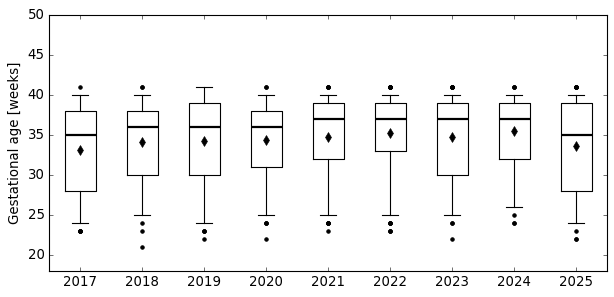

In [70]:
filetype='jpg'; dpi=200

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-'}; whiskerprops = {'color': 'black', 'linestyle': '-'}
capprops = {'color': 'black', 'linestyle': '-'}; flierprops = {'color': 'black', 'marker': '.'}

gestational_age = {}
for year in clin_dta_years:
    gestational_age[year] = clin_dta_years[year]['Gestational Age (weeks)']

fig, ax = plt.subplots(figsize = [9,4])
ax.boxplot(gestational_age.values(), tick_labels=gestational_age.keys(), whis = [5, 95], showfliers = True, showmeans = True, 
    meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.set_ylabel('Gestational age [weeks]')
ax.set_ylim(18,50)

fig.savefig(os.path.join(DIR_WRITE, f'gestational_age.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

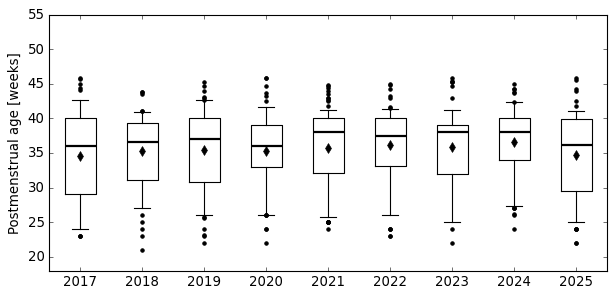

In [71]:
filetype='jpg'; dpi=200

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-'}; whiskerprops = {'color': 'black', 'linestyle': '-'}
capprops = {'color': 'black', 'linestyle': '-'}; flierprops = {'color': 'black', 'marker': '.'}

gestational_age = {}
for year in clin_dta_years:
    gestational_age[year] = clin_dta_years[year]['Corrected gestational Age (weeks)']

fig, ax = plt.subplots(figsize = [9,4])
ax.boxplot(gestational_age.values(), tick_labels=gestational_age.keys(), whis = [5, 95], showfliers = True, showmeans = True, 
    meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.set_ylabel('Postmenstrual age [weeks]')
ax.set_ylim(18, 55)

fig.savefig(os.path.join(DIR_WRITE, f'postmenstrual_age.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

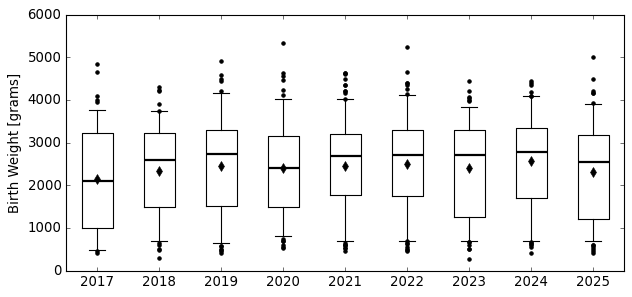

In [72]:
filetype='jpg'; dpi=200

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-'}; whiskerprops = {'color': 'black', 'linestyle': '-'}
capprops = {'color': 'black', 'linestyle': '-'}; flierprops = {'color': 'black', 'marker': '.'}

gestational_age = {}
for year in clin_dta_years:
    gestational_age[year] = clin_dta_years[year]['Birth Weight']

fig, ax = plt.subplots(figsize = [9,4])
ax.boxplot(gestational_age.values(), tick_labels=gestational_age.keys(), whis = [5, 95], showfliers = True, showmeans = True, 
    meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.set_ylabel('Birth Weight [grams]')
ax.set_ylim(0, 6000)

fig.savefig(os.path.join(DIR_WRITE, f'birth_weight.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

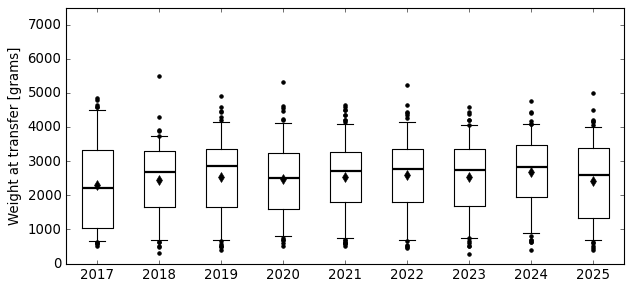

In [73]:
filetype='jpg'; dpi=200

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-'}; whiskerprops = {'color': 'black', 'linestyle': '-'}
capprops = {'color': 'black', 'linestyle': '-'}; flierprops = {'color': 'black', 'marker': '.'}

gestational_age = {}
for year in clin_dta_years:
    gestational_age[year] = clin_dta_years[year]['Weight'].dropna()

fig, ax = plt.subplots(figsize = [9,4])
ax.boxplot(gestational_age.values(), tick_labels=gestational_age.keys(), whis = [5, 95], showfliers = True, showmeans = True, 
    meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.set_ylabel('Weight at transfer [grams]')
ax.set_ylim(0, 7500)

fig.savefig(os.path.join(DIR_WRITE, f'actual_weight.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

#### B. Number of infants in specific gestational age bins

The number of infants in each gestational age range (≤28, 29-32, 33-36, ≥37 weeks) at birth and at the time of transfer. 

##### i. At birth

In [76]:
gest_age_bins = [0, 29, 33, 37, 50]
gest_age_birth_yearly = {}

for year, dta in clin_dta_years.items():
    cats_gest_age_birth = pd.cut(dta['Gestational Age (weeks)'], bins = gest_age_bins, right = False,)
    grouped_gest_age_birth = dta.groupby(cats_gest_age_birth, observed=False)
    gest_age_birth_yearly[year] = grouped_gest_age_birth.size()

gest_age_birth_yearly = DataFrame(gest_age_birth_yearly)
gest_age_birth_yearly.index = ['≤28', '29-32', '33-36', '≥37']
gest_age_birth_yearly.index.name = 'gestational age at birth [weeks]'
gest_age_birth_yearly

,2017,2018,2019,2020,2021,2022,2023,2024,2025
gestational age at birth [weeks],,,,,,,,,
≤28,29,18,23,22,35,18,22,14,27
29-32,12,12,11,14,23,13,10,17,14
33-36,12,18,21,30,30,27,17,22,15
≥37,39,38,48,51,96,67,58,62,46


In [77]:
gest_age_bins = [0, 29, 33, 37, 50]
cats_gest_age_birth = pd.cut(clinical_data['Gestational Age (weeks)'], bins = gest_age_bins, right = False,)
grouped_gest_age_birth_all = clinical_data.groupby(cats_gest_age_birth, observed=False)
grouped_gest_age_birth_all.size()

Gestational Age (weeks)
[0, 29)     208
[29, 33)    126
[33, 37)    192
[37, 50)    505
dtype: int64

##### ii. At the time of transfer

In [79]:
gest_age_bins = [0, 29, 33, 37, 50]
gest_age_transfer_yearly = {}

for year, dta in clin_dta_years.items():
    cats_gest_age_transfer = pd.cut(dta['Corrected gestational Age (weeks)'], bins = gest_age_bins, right = False,)
    grouped_gest_age_transfer = dta.groupby(cats_gest_age_transfer, observed=False)
    gest_age_transfer_yearly[year] = grouped_gest_age_transfer.size()

gest_age_transfer_yearly = DataFrame(gest_age_transfer_yearly)
gest_age_transfer_yearly.index = ['≤28', '29-32', '33-36', '≥37']
gest_age_transfer_yearly.index.name = 'post-conceptional age at transfer [weeks]'
gest_age_transfer_yearly

,2017,2018,2019,2020,2021,2022,2023,2024,2025
post-conceptional age at transfer [weeks],,,,,,,,,
≤28,21,13,16,17,30,13,15,10,23
29-32,13,13,15,12,23,15,13,12,13
33-36,16,17,18,33,25,24,16,25,16
≥37,42,43,54,55,106,73,63,68,50


In [80]:
gest_age_bins = [0, 29, 33, 37, 50]
cats_gest_age_transfer = pd.cut(clinical_data['Corrected gestational Age (weeks)'], bins = gest_age_bins, right = False,)
grouped_gest_age_transfer_all = clinical_data.groupby(cats_gest_age_transfer, observed=False)
grouped_gest_age_transfer_all.size()

Corrected gestational Age (weeks)
[0, 29)     158
[29, 33)    129
[33, 37)    190
[37, 50)    554
dtype: int64

In [81]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'gestational_age_binned.xlsx'))

gest_age_birth_yearly.to_excel(writer, sheet_name='at_birth_yearly')
grouped_gest_age_birth_all.size().to_excel(writer, sheet_name='at_birth_all')
gest_age_transfer_yearly.to_excel(writer, sheet_name='at_transfer_yearly')
grouped_gest_age_transfer_all.size().to_excel(writer, sheet_name='at_transfer_all')

writer.close()

### 10. Statistics on duration of recordings

In [83]:
recording_duration_recordings = {}

for year in measurements_years:
    for case, dta in measurements_years[year].items():
        # data points, minutes (0.5 Hz sampling rate)
        recording_duration_recordings[case] = (year, len(dta), len(dta) * 2 / 60)

recording_duration_recordings = DataFrame(recording_duration_recordings).T
recording_duration_recordings.columns = ['year', 'data points', 'duration [minutes]']
recording_duration_recordings

,year,data points,duration [minutes]
AL000003,2017.0,2580.0,86.000000
AL000006,2017.0,1140.0,38.000000
AL000008,2017.0,3121.0,104.033333
AL000009,2017.0,1125.0,37.500000
AL000011,2017.0,2700.0,90.000000
...,...,...,...
AT001936,2025.0,1245.0,41.500000
AT001937,2025.0,735.0,24.500000
AT001940,2025.0,1320.0,44.000000
AT001941,2025.0,1006.0,33.533333


In [84]:
recording_duration_stats_cohort = recording_duration_recordings.describe()
recording_duration_stats_cohort

,year,data points,duration [minutes]
count,1031.000000,1031.000000,1031.000000
mean,2021.138700,2159.543162,71.984772
std,2.408554,1243.416647,41.447222
min,2017.000000,300.000000,10.000000
25%,2019.000000,1179.000000,39.300000
50%,2021.000000,1948.000000,64.933333
75%,2023.000000,2918.500000,97.283333
max,2025.000000,8581.000000,286.033333


In [85]:
recording_duration_stats_yearly = np.round(recording_duration_recordings.groupby('year').describe(), 1)
recording_duration_stats_yearly

data points                                                         \
             count    mean     std    min     25%     50%     75%     max   
year                                                                        
2017.0        92.0  2258.1  1144.5  660.0  1306.0  2206.0  3007.0  7104.0   
2018.0        86.0  2256.9  1282.8  601.0  1219.8  1933.5  2997.2  7859.0   
2019.0       103.0  2208.8  1138.5  362.0  1275.5  1980.0  2954.0  5790.0   
2020.0       117.0  1895.5  1108.7  367.0  1125.0  1622.0  2460.0  5789.0   
2021.0       184.0  2022.8  1218.2  300.0  1035.8  1725.5  2805.0  7167.0   
2022.0       125.0  2159.3  1134.8  326.0  1202.0  2160.0  2995.0  5072.0   
2023.0       107.0  2051.7  1169.0  304.0  1089.0  1996.0  2835.0  5280.0   
2024.0       115.0  2299.0  1466.1  563.0  1260.5  1838.0  2951.0  8581.0   
2025.0       102.0  2444.8  1449.1  660.0  1247.8  2123.0  3254.8  8573.0   

       duration [minutes]                                              
                    count  mean   std   min   25%   50%    75%    max  
year                                                                   
2017.0               92.0  75.3  38.1  22.0  43.5  73.5  100.2  236.8  
2018.0               86.0  75.2  42.8  20.0  40.7  64.4   99.9  262.0  
2019.0              103.0  73.6  37.9  12.1  42.5  66.0   98.5  193.0  
2020.0              117.0  63.2  37.0  12.2  37.5  54.1   82.0  193.0  
2021.0              184.0  67.4  40.6  10.0  34.5  57.5   93.5  238.9  
2022.0              125.0  72.0  37.8  10.9  40.1  72.0   99.8  169.1  
2023.0              107.0  68.4  39.0  10.1  36.3  66.5   94.5  176.0  
2024.0              115.0  76.6  48.9  18.8  42.0  61.3   98.4  286.0  
2025.0              102.0  81.5  48.3  22.0  41.6  70.8  108.5  285.8

In [86]:
recording_duration_stats_yearly_2 = round(recording_duration_recordings.groupby('year').sum(), 0)
recording_duration_stats_yearly_2

,data points,duration [minutes]
year,,
2017.0,207741.0,6925.0
2018.0,194091.0,6470.0
2019.0,227502.0,7583.0
2020.0,221775.0,7392.0
2021.0,372189.0,12406.0
2022.0,269910.0,8997.0
2023.0,219532.0,7318.0
2024.0,264382.0,8813.0
2025.0,249367.0,8312.0


In [87]:
recording_duration_stats_yearly_2.sum()

data points           2226489.0
duration [minutes]      74216.0
dtype: float64

In [88]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'recording_duration_stats.xlsx'))
recording_duration_stats_yearly.to_excel(writer, sheet_name='stats_yearly')
recording_duration_stats_yearly_2.to_excel(writer, sheet_name='stats_yearly_2')
recording_duration_stats_cohort.to_excel(writer, sheet_name='stats_cohort')
writer.close()

### 11. Identify significant gaps in data collection

In [90]:
# Time after each case before the next case
time_between_cases = clinical_data_all[['Recording start', 'Recording end']]
time_between_cases['gap_after_case'] = clinical_data_all['Recording start'].shift(-1) - clinical_data_all['Recording end']
time_between_cases.index.name = 'Case ID'
time_between_cases

,Recording start,Recording end,gap_after_case
Case ID,,,
AL000003,2017-03-24 18:05:07,2017-03-24 19:50:04,1 days 23:24:49
AL000005,2017-03-26 19:14:53,2017-03-26 19:57:19,0 days 04:07:02
AL000006,2017-03-27 00:04:21,2017-03-27 00:55:07,1 days 23:53:22
AL000007,2017-03-29 00:48:29,2017-03-29 02:48:57,0 days 12:55:29
AL000008,2017-03-29 15:44:26,2017-03-29 17:42:48,1 days 11:56:41
...,...,...,...
AT002244,2026-04-29 04:05:25,2026-04-29 05:38:32,1 days 11:45:02
AT002246,2026-04-30 17:23:34,2026-04-30 18:13:54,0 days 00:33:43
AT002247,2026-04-30 18:47:37,2026-04-30 19:35:31,1 days 21:15:09


In [91]:
time_between_cases_over14d = time_between_cases[time_between_cases['gap_after_case'] > pd.to_timedelta('14d')]
time_between_cases_over14d['start_of_gap'] = time_between_cases_over14d['Recording end'].dt.date
time_between_cases_over14d['end_of_gap'] = time_between_cases_over14d['start_of_gap'] + time_between_cases['gap_after_case'].dropna()
time_between_cases_over14d = time_between_cases_over14d[['start_of_gap', 'end_of_gap', 'gap_after_case',]].reset_index()
time_between_cases_over14d

/var/folders/m8/7psgz80s2zjg355kk1kmgfc40000gn/T/ipykernel_97883/1559866722.py:3: PerformanceWarning: Adding/subtracting object-dtype array to TimedeltaArray not vectorized.
  time_between_cases_over14d['end_of_gap'] = time_between_cases_over14d['start_of_gap'] + time_between_cases['gap_after_case'].dropna()


,Case ID,start_of_gap,end_of_gap,gap_after_case
0,AL000056,2017-05-21,2017-06-07,17 days 13:49:34
1,AL000149,2017-09-02,2017-11-18,77 days 22:43:14
2,AL000193,2017-12-20,2018-02-19,61 days 19:44:05
3,AL000252,2018-04-16,2018-05-06,20 days 07:24:53
4,AL000255,2018-05-11,2018-06-01,21 days 13:17:04
5,AL000369,2018-09-07,2018-10-27,50 days 23:30:25
6,AL000428,2018-12-04,2019-01-10,37 days 20:59:22
7,AL000471,2019-02-26,2019-03-17,19 days 12:29:57
8,AL000619,2019-07-15,2019-07-31,16 days 18:36:03
9,AL000693,2019-09-23,2019-11-29,67 days 04:04:00


In [92]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'gaps_in_data_collection.xlsx'))
time_between_cases.to_excel(writer, sheet_name='time_between_cases')
time_between_cases_over14d.to_excel(writer, sheet_name='gaps_over_14days')
writer.close()

### 12. Identify ventilation modes

In [94]:
vent_modes_vent_all = defaultdict(dict)

for year in settings_years:
    for case, dta in settings_years[year].items():
        vent_modes_vent_all[case].update({'year' : year})
        all_modes = ['SIPPV', 'SIMV', 'SIMVPSV', 'PSV', 'IPPV', 'HFO']
        
        # Exclude noninvasive modes
        modes_used = [mode for mode in all_modes if mode in dta['Ventilator_mode'].unique()]
        for mode in all_modes:
            if mode in modes_used:
                vent_modes_vent_all[case].update({mode : sum(dta['Ventilator_mode'] == mode)})
            else:
                vent_modes_vent_all[case].update({mode : 0})

vent_modes_vent_all = DataFrame(vent_modes_vent_all).T
# Data points
vent_modes_vent_all.head()

,year,SIPPV,SIMV,SIMVPSV,PSV,IPPV,HFO
AL000003,2017,0,2580,0,0,0,0
AL000006,2017,0,0,1140,0,0,0
AL000008,2017,0,3121,0,0,0,0
AL000009,2017,1125,0,0,0,0,0
AL000011,2017,0,2700,0,0,0,0


### 13. Trends in ventilation modes used

#### A. What was the ventilator mode used during transport ?

Consider the mode used for the longest, if multiple modes were used

In [97]:
vent_mode_main = {}

for year in settings_years:
    for case in settings_years[year]:
        dta = vent_modes_vent_all.loc[case, all_modes]
        # The ventilation modes used for longest time in the recording
        pred_vent_mode = dta.index[dta.argmax()]
        vent_mode_main[case] = (year, pred_vent_mode)
        
vent_mode_main = DataFrame(vent_mode_main).T
vent_mode_main.columns = ['year', 'ventilation_mode']
vent_mode_main.head()

,year,ventilation_mode
AL000003,2017,SIMV
AL000006,2017,SIMVPSV
AL000008,2017,SIMV
AL000009,2017,SIPPV
AL000011,2017,SIMV


In [98]:
vent_modes_used =  {}

for year in clin_dta_years:
    dta = vent_mode_main[vent_mode_main['year'] == year]
    vent_modes_used[year] = (sum(dta['ventilation_mode'] == 'SIPPV'), sum(dta['ventilation_mode'] == 'SIMVPSV'),
                             sum(dta['ventilation_mode'] == 'SIMV'), sum(dta['ventilation_mode'] == 'PSV'), 
                             sum(dta['ventilation_mode'] == 'IPPV'), sum(dta['ventilation_mode'] == 'HFO'),
                             len(dta['ventilation_mode']))                                                 

vent_modes_used = DataFrame(vent_modes_used).T
vent_modes_used.columns = ['SIPPV', 'SIMV-PS','SIMV', 'PSV', 'IPPV', 'HFOV', 'total']
vent_modes_used

,SIPPV,SIMV-PS,SIMV,PSV,IPPV,HFOV,total
2017,19,7,62,0,4,0,92
2018,33,5,47,0,1,0,86
2019,31,4,66,0,2,0,103
2020,46,5,58,0,5,3,117
2021,67,36,64,1,1,15,184
2022,40,16,51,0,0,18,125
2023,43,3,42,1,2,16,107
2024,38,3,52,0,2,20,115
2025,52,2,25,0,2,21,102


In [99]:
vent_modes_used_pc = vent_modes_used.div(vent_modes_used['total']/100, axis=0)
vent_modes_used_pc

,SIPPV,SIMV-PS,SIMV,PSV,IPPV,HFOV,total
2017,20.652174,7.608696,67.391304,0.000000,4.347826,0.000000,100.0
2018,38.372093,5.813953,54.651163,0.000000,1.162791,0.000000,100.0
2019,30.097087,3.883495,64.077670,0.000000,1.941748,0.000000,100.0
2020,39.316239,4.273504,49.572650,0.000000,4.273504,2.564103,100.0
2021,36.413043,19.565217,34.782609,0.543478,0.543478,8.152174,100.0
2022,32.000000,12.800000,40.800000,0.000000,0.000000,14.400000,100.0
2023,40.186916,2.803738,39.252336,0.934579,1.869159,14.953271,100.0
2024,33.043478,2.608696,45.217391,0.000000,1.739130,17.391304,100.0
2025,50.980392,1.960784,24.509804,0.000000,1.960784,20.588235,100.0


In [100]:
vent_modes_used['total'] / service_activity['Number of cases']

2017    0.264368
2018    0.199536
2019    0.210204
2020    0.364486
2021    0.422989
2022    0.307125
2023    0.313783
2024    0.315068
2025    0.474419
dtype: float64

In [101]:
vent_modes_used['total'].sum(), service_activity['Number of cases'].sum(), 

(1031, 3353)

In [102]:
vent_modes_used['total'].sum() / service_activity['Number of cases'].sum() 

0.307485833581867

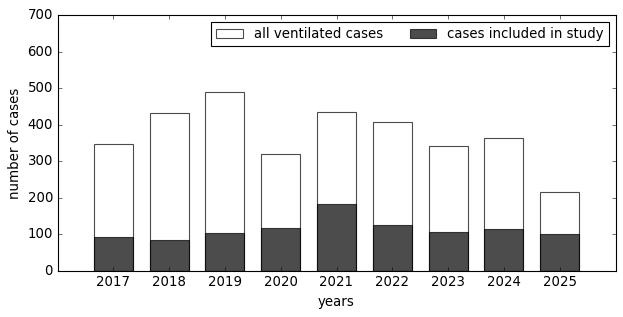

In [103]:
filetype='jpg'; dpi=200

fig, ax = plt.subplots(figsize = [9,4])
ax.bar(np.arange(len(service_activity.index)), service_activity['Number of cases'],  width=0.7, color='white', alpha=0.7)
ax.bar(np.arange(len(vent_modes_used)), vent_modes_used['total'], width=0.7, color='black', alpha=0.7)

ax.set_xticks(np.arange(len(vent_modes_used)), vent_modes_used.index, rotation=0)
ax.set_xlim(-1, len(vent_modes_used))
ax.set_ylim(0, 700)
ax.set_xlabel('years', size = 12)
ax.set_ylabel('number of cases', size = 12)
ax.legend(['all ventilated cases', 'cases included in study',], fontsize = 12, ncols=2)
   
fig.savefig(os.path.join(DIR_WRITE, f'number_of_cases.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

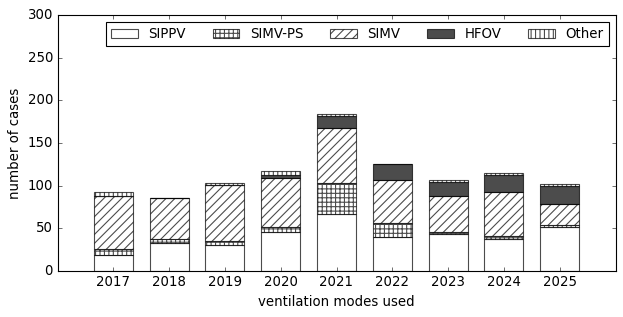

In [104]:
filetype='jpg'; dpi=200

fig, ax = plt.subplots(figsize = [9,4])
# SIPPV
ax.bar(np.arange(len(vent_modes_used)), vent_modes_used['SIPPV'], width=0.7, color='white', alpha=0.7)
bottom = vent_modes_used['SIPPV'].copy()
# SIMV-PS
ax.bar(np.arange(len(vent_modes_used)), vent_modes_used['SIMV-PS'], bottom=bottom, width=0.7, color='white', hatch='+++', alpha=0.7)
bottom += vent_modes_used['SIMV-PS']
# SIMV
ax.bar(np.arange(len(vent_modes_used)), vent_modes_used['SIMV'], bottom=bottom, width=0.7, color='white', hatch='///', alpha=0.7)
bottom += vent_modes_used['SIMV']
# HFOV
ax.bar(np.arange(len(vent_modes_used)), vent_modes_used['HFOV'], bottom=bottom, width=0.7, color='black', alpha=0.7)
bottom += vent_modes_used['HFOV']
# Other modes (PSV and IPPV)
ax.bar(np.arange(len(vent_modes_used)), (vent_modes_used['PSV'] + vent_modes_used['IPPV']), bottom=bottom, width=0.7, 
    color='white', hatch='|||', alpha=0.7)

ax.set_xticks(np.arange(len(vent_modes_used)), vent_modes_used.index, rotation=0)
ax.set_xlim(-1, len(vent_modes_used))
ax.set_ylim(0, 300)
ax.set_xlabel('ventilation modes used', size = 12)
ax.set_ylabel('number of cases', size = 12)
ax.legend(['SIPPV', 'SIMV-PS', 'SIMV', 'HFOV', 'Other'], fontsize = 12, ncols=5)
   
fig.savefig(os.path.join(DIR_WRITE, f'vent_modes_used.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

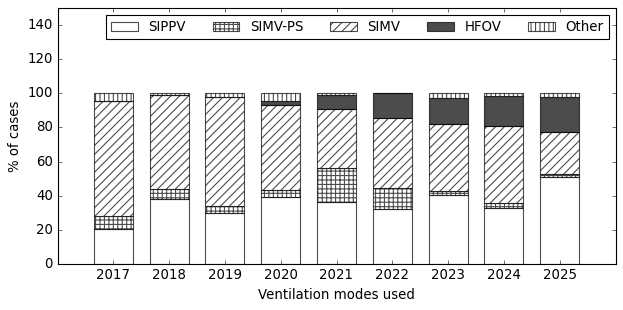

In [105]:
filetype='jpg'; dpi=200

fig, ax = plt.subplots(figsize = [9,4])
# SIPPV
ax.bar(np.arange(len(vent_modes_used_pc)), vent_modes_used_pc['SIPPV'], width=0.7, color='white', alpha=0.7)
bottom = vent_modes_used_pc['SIPPV'].copy()
# SIMV-PS
ax.bar(np.arange(len(vent_modes_used_pc)), vent_modes_used_pc['SIMV-PS'], bottom=bottom, width=0.7, color='white', hatch='+++', alpha=0.7)
bottom += vent_modes_used_pc['SIMV-PS']
# SIMV
ax.bar(np.arange(len(vent_modes_used_pc)), vent_modes_used_pc['SIMV'], bottom=bottom, width=0.7, color='white', hatch='///', alpha=0.7)
bottom += vent_modes_used_pc['SIMV']
# HFOV
ax.bar(np.arange(len(vent_modes_used_pc)), vent_modes_used_pc['HFOV'], bottom=bottom, width=0.7, color='black', alpha=0.7)
bottom += vent_modes_used_pc['HFOV']
# Other modes (PSV and IPPV)
ax.bar(np.arange(len(vent_modes_used_pc)), (vent_modes_used_pc['PSV'] + vent_modes_used_pc['IPPV']), bottom=bottom, width=0.7, 
    color='white', hatch='|||', alpha=0.7)

ax.set_xticks(np.arange(len(vent_modes_used_pc)), vent_modes_used_pc.index, rotation=0)
ax.set_xlim(-1, len(vent_modes_used_pc))
ax.set_ylim(0, 150)
ax.set_xlabel('Ventilation modes used', size = 12)
ax.set_ylabel('% of cases', size = 12)
ax.legend(['SIPPV', 'SIMV-PS', 'SIMV', 'HFOV', 'Other'], fontsize = 12, ncols=5)
   
fig.savefig(os.path.join(DIR_WRITE, f'vent_modes_used_pc.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

#### B. Increased use of the modes supporting all breaths

Batra D, Jaysainghe D, Batra N. Supporting all breaths versus supporting some breaths during synchronised mechanical ventilation in neonates: a systematic review and meta-analysis. Arch Dis Child Fetal Neonatal Ed. 2023 Jul;108(4):408-415. doi: 10.1136/archdischild-2022-324464. Epub 2023 Jan 11. PMID: 36631252.

In [107]:
vent_modes_used['supp_all_breath'] = vent_modes_used[['SIPPV', 'SIMV-PS', 'PSV']].sum(axis=1) # modes supporting all breaths
vent_modes_used['conventional_total'] = vent_modes_used[['SIPPV', 'SIMV-PS', 'SIMV', 'PSV', 'IPPV']].sum(axis=1)
vent_modes_used = vent_modes_used[['SIPPV', 'SIMV-PS', 'SIMV', 'PSV', 'IPPV', 'supp_all_breath', 'conventional_total', 'HFOV', 'total']]
vent_modes_used

,SIPPV,SIMV-PS,SIMV,PSV,IPPV,supp_all_breath,conventional_total,HFOV,total
2017,19,7,62,0,4,26,92,0,92
2018,33,5,47,0,1,38,86,0,86
2019,31,4,66,0,2,35,103,0,103
2020,46,5,58,0,5,51,114,3,117
2021,67,36,64,1,1,104,169,15,184
2022,40,16,51,0,0,56,107,18,125
2023,43,3,42,1,2,47,91,16,107
2024,38,3,52,0,2,41,95,20,115
2025,52,2,25,0,2,54,81,21,102


In [108]:
supp_all_breaths = vent_modes_used['supp_all_breath'] / vent_modes_used['conventional_total']
supp_all_breaths = DataFrame(supp_all_breaths, columns = ['supp_all_breaths [%]'])
supp_all_breaths

,supp_all_breaths [%]
2017,0.282609
2018,0.441860
2019,0.339806
2020,0.447368
2021,0.615385
2022,0.523364
2023,0.516484
2024,0.431579
2025,0.666667


In [109]:
vent_modes_used.loc[2017:2020, 'supp_all_breath'].sum() /  vent_modes_used.loc[2017:2020, 'conventional_total'].sum()

0.379746835443038

In [110]:
vent_modes_used.loc[2021:2025, 'supp_all_breath'].sum() /  vent_modes_used.loc[2021:2025, 'conventional_total'].sum()

0.5561694290976059

In [111]:
# Significant increase in VG from 2017-2020 to 2021-2025
# performing fishers exact test on the data
odd_ratio, p_value = stats.fisher_exact([
        [vent_modes_used.loc[2017:2020, 'supp_all_breath'].sum(), vent_modes_used.loc[2017:2020, 'SIMV'].sum()], 
        [vent_modes_used.loc[2021:2025, 'supp_all_breath'].sum(), vent_modes_used.loc[2021:2025, 'SIMV'].sum()]
                                        ], alternative='two-sided')
odd_ratio, p_value

(0.49882045305971634, 3.4327206514641785e-07)

#### C. Increased HFOV use

In [113]:
hfov_use = DataFrame(vent_modes_used['HFOV'] / vent_modes_used['total'] * 100, columns=['HFOV used [%]'])
hfov_use

,HFOV used [%]
2017,0.000000
2018,0.000000
2019,0.000000
2020,2.564103
2021,8.152174
2022,14.400000
2023,14.953271
2024,17.391304
2025,20.588235


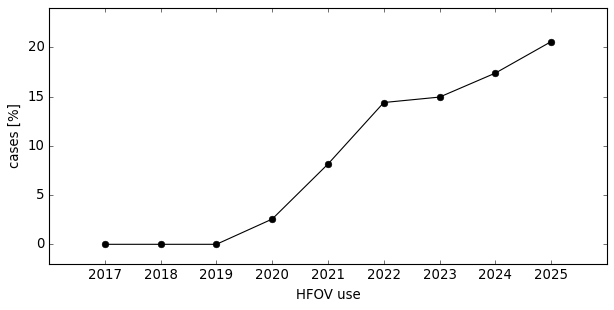

In [114]:
filetype='jpg'; dpi=200

fig, ax = plt.subplots(figsize = [9,4])
ax.plot(np.arange(len(hfov_use)), hfov_use['HFOV used [%]'], marker='o', markerfacecolor = 'black', color='black', )
ax.set_xticks(np.arange(len(hfov_use)), hfov_use.index, rotation=0)
ax.set_xlim(-1, len(hfov_use))
ax.set_ylim(-2, 24)
ax.set_xlabel('HFOV use', size = 12)
ax.set_ylabel('cases [%]', size = 12)

fig.savefig(os.path.join(DIR_WRITE, f'hfov_use.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

In [115]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'vent_modes_used_all.xlsx'))
vent_modes_vent_all.to_excel(writer, sheet_name='vent_modes_vent_all')
vent_mode_main.to_excel(writer, sheet_name='vent_mode_main')
vent_modes_used.to_excel(writer, sheet_name='yearly_data')
supp_all_breaths.to_excel(writer, sheet_name='supp_all_breath')
hfov_use.to_excel(writer, sheet_name='hfov_used')
writer.close()

### 14. Separate data to conventional ventilation and HFOV and separate both to VG and non-VG

Consider only recordings which have at least 10 minutes of conventional ventilation or HFOV.
Some recordings will be present in both datasets

#### A. Conventional ventilation

In [118]:
%%time

measurements_conv, settings_conv, alarms_conv = {}, {}, {}
conventional_modes = ['SIPPV', 'SIMV', 'SIMVPSV', 'PSV', 'IPPV']

for case in settings_ventilated:
    dta = settings_ventilated[case]
    dta = dta[dta['Ventilator_mode'].isin(conventional_modes)]
    settings_conv[case] = dta
    measurements_conv[case] = measurements_ventilated[case].reindex(dta.index)
    alarms_conv[case] = alarms_ventilated[case].reindex(dta.index)

CPU times: user 783 ms, sys: 450 ms, total: 1.23 s
Wall time: 1.13 s


In [119]:
# Limit to those recordings which have at least 10 minutes of conventional ventilation (0.5 Hz sampling rate)
measurements_conv = {case : dta for case, dta in measurements_conv.items() if len(dta) >= 300}
settings_conv = {case : dta for case, dta in settings_conv.items() if len(dta) >= 300}
alarms_conv = {case : dta for case, dta in alarms_conv.items() if len(dta) >= 300}
len(measurements_conv), len(settings_conv), len(alarms_conv), 

(952, 952, 952)

In [120]:
# Limit clinical data to recordings with conventional ventilation
clinical_data_conv = clinical_data.loc[settings_conv.keys()]
len(clinical_data_conv)

952

In [121]:
# Limit blood gases to recordings with conventional ventilation
blood_gases_conv = {case: dta for case, dta in blood_gases.items() if case in settings_conv.keys()}
len(blood_gases_conv)

916

In [122]:
# Produce yearly data
measurements_conv_years, settings_conv_years, alarms_conv_years = defaultdict(dict), defaultdict(dict), defaultdict(dict)

for year in clin_dta_years:
    for case in clin_dta_years[year].index:
        if case in settings_conv:
            measurements_conv_years[year][case] = measurements_conv[case]
            settings_conv_years[year][case] = settings_conv[case]
            alarms_conv_years[year][case] = alarms_conv[case]

In [123]:
# Cases with >10 minute of conventional ventilation
for year in measurements_conv_years:
    print(year, len(measurements_conv_years[year]))

2017 92
2018 86
2019 103
2020 114
2021 169
2022 109
2023 95
2024 99
2025 85


#### B. Conventional ventilation with VG or without VG

In [125]:
%%time

# Separate ventilator data into VG and non-VG parts for each recordings; some of these part are of zero length
measurements_conv_vg, settings_conv_vg, alarms_conv_vg = {}, {}, {}
measurements_conv_novg, settings_conv_novg, alarms_conv_novg = {}, {}, {}

for case, dta in settings_conv.items():
    if 'VG_state' in dta.columns:
        settings_conv_vg[case] = dta[dta['VG_state'] == 'on']
        settings_conv_novg[case] = dta[dta['VG_state'] != 'on']
    else:
        settings_conv_novg[case] = dta

CPU times: user 458 ms, sys: 237 ms, total: 695 ms
Wall time: 848 ms


In [126]:
for case in settings_conv_vg:
        measurements_conv_vg[case] = measurements_conv[case].reindex(settings_conv_vg[case].index)
        alarms_conv_vg[case] = alarms_conv[case].reindex(settings_conv_vg[case].index)

for case in settings_conv_novg:
    measurements_conv_novg[case] = measurements_conv[case].reindex(settings_conv_novg[case].index)
    alarms_conv_novg[case] = alarms_conv[case].reindex(settings_conv_novg[case].index)

In [127]:
# Some of them are of zero lengths
len(measurements_conv_vg), len(settings_conv_vg), len(alarms_conv_vg), 

(952, 952, 952)

In [128]:
# Some of them are of zero lengths
len(measurements_conv_novg), len(settings_conv_novg), len(alarms_conv_novg), 

(952, 952, 952)

In [129]:
# Produce yearly data
measurements_conv_vg_years, settings_conv_vg_years, alarms_conv_vg_years = defaultdict(dict), defaultdict(dict), defaultdict(dict)

for year in clin_dta_years:
    for case in clin_dta_years[year].index:
        if case in settings_conv_vg:
            measurements_conv_vg_years[year][case] = measurements_conv_vg[case]
            settings_conv_vg_years[year][case] = settings_conv_vg[case]
            alarms_conv_vg_years[year][case] = alarms_conv_vg[case]

In [130]:
# Produce yearly data
measurements_conv_novg_years, settings_conv_novg_years, alarms_conv_novg_years = defaultdict(dict), defaultdict(dict), defaultdict(dict)

for year in clin_dta_years:
    for case in clin_dta_years[year].index:
        if case in settings_conv_novg:
            measurements_conv_novg_years[year][case] = measurements_conv_novg[case]
            settings_conv_novg_years[year][case] = settings_conv_novg[case]
            alarms_conv_novg_years[year][case] = alarms_conv_novg[case]

In [131]:
# Cases with >10 minute of conventional ventilation which have at least some non-VG during them
for year in measurements_conv_novg_years:
    print(year, len(measurements_conv_novg_years[year]))

2017 92
2018 86
2019 103
2020 114
2021 169
2022 109
2023 95
2024 99
2025 85


#### C. HFOV

In [133]:
%%time

measurements_hfov, settings_hfov, alarms_hfov = {}, {}, {}

for case in settings_ventilated:
    dta = settings_ventilated[case]
    dta = dta[dta['Ventilator_mode'] == 'HFO']
    settings_hfov[case] = dta
    measurements_hfov[case] = measurements_ventilated[case].reindex(dta.index)
    alarms_hfov[case] = alarms_ventilated[case].reindex(dta.index)

CPU times: user 415 ms, sys: 110 ms, total: 525 ms
Wall time: 546 ms


In [134]:
# Limit to those recordings which have ≥10 minutes of hfov (0.5 Hz sampling rate)
measurements_hfov = {case : dta for case, dta in measurements_hfov.items() if len(dta) >= 300}
settings_hfov = {case : dta for case, dta in settings_hfov.items() if len(dta) >= 300}
alarms_hfov = {case : dta for case, dta in alarms_hfov.items() if len(dta) >= 300}
len(measurements_hfov), len(settings_hfov), len(alarms_hfov), 

(104, 104, 104)

In [135]:
measurements_hfov_years, settings_hfov_years, alarms_hfov_years = defaultdict(dict), defaultdict(dict), defaultdict(dict)

for year in clin_dta_years:
    for case in clin_dta_years[year].index:
        if case in settings_hfov:
            measurements_hfov_years[year][case] = measurements_hfov[case]
            settings_hfov_years[year][case] = settings_hfov[case]
            alarms_hfov_years[year][case] = alarms_hfov[case]

In [136]:
# Limit clinical data to recordings with HFOV
clinical_data_hfov = clinical_data.loc[measurements_hfov.keys()]
len(clinical_data_hfov)

104

In [137]:
# Limit blood gases to recordings with HFOV
blood_gases_hfov = {case: dta for case, dta in blood_gases.items() if case in measurements_hfov.keys()}
len(blood_gases_hfov)

101

In [138]:
# Cases with >10 minute of HFOV
for year in measurements_hfov_years:
    print(year, len(measurements_hfov_years[year]))

2020 3
2021 18
2022 22
2023 16
2024 21
2025 24


#### D. HFOV with VG or without VG

In [140]:
%%time

settings_hfov_vg, settings_hfov_novg = {}, {},

for case, dta in settings_hfov.items():
    if 'VG_state' in dta.columns:
        settings_hfov_vg[case] = dta[dta['VG_state'] == 'on']
        settings_hfov_novg[case] = dta[dta['VG_state'] != 'on']
    else:
        settings_hfov_novg[case] = dta

CPU times: user 53.2 ms, sys: 8.93 ms, total: 62.2 ms
Wall time: 61.9 ms


In [141]:
measurements_hfov_vg, alarms_hfov_vg = {}, {},
measurements_hfov_novg, alarms_hfov_novg = {}, {},

for case in settings_hfov_vg:
    measurements_hfov_vg[case] = measurements_hfov[case].reindex(settings_hfov_vg[case].index)
    alarms_hfov_vg[case] = alarms_hfov[case].reindex(settings_hfov_vg[case].index)

for case in settings_hfov_novg:
    measurements_hfov_novg[case] = measurements_hfov[case].reindex(settings_hfov_novg[case].index)
    alarms_hfov_novg[case] = alarms_hfov[case].reindex(settings_hfov_novg[case].index)

In [142]:
hfov_vg_use = []
hfov_novg_use = []

for case in measurements_hfov_vg:
    # More than half of the HFOV is HFOV-VG
    if len(measurements_hfov_vg[case]) / len(measurements_hfov[case]) > 0.5:
        hfov_vg_use.append(case)
    else:
        hfov_novg_use.append(case)

len(hfov_vg_use), len(hfov_novg_use)

(51, 53)

In [143]:
# Limit clinical data to recordings with conventional ventilation
clinical_data_hfov_vg = clinical_data.loc[hfov_vg_use]
clinical_data_hfov_novg = clinical_data.loc[hfov_novg_use]
len(clinical_data_hfov_vg), len(clinical_data_hfov_novg)

(51, 53)

In [144]:
# Limit blood gases to recordings with conventional ventilation
blood_gases_hfov_vg = {case: dta for case, dta in blood_gases.items() if case in hfov_vg_use}
blood_gases_hfov_novg = {case: dta for case, dta in blood_gases.items() if case in hfov_novg_use}
len(blood_gases_hfov_vg), len(blood_gases_hfov_novg)

(49, 52)

In [145]:
# Produce yearly data
measurements_hfov_vg_years, settings_hfov_vg_years, alarms_hfov_vg_years = defaultdict(dict), defaultdict(dict), defaultdict(dict)

for year in clin_dta_years:
    for case in clin_dta_years[year].index:
        if case in hfov_vg_use:
            measurements_hfov_vg_years[year][case] = measurements_hfov_vg[case]
            settings_hfov_vg_years[year][case] = settings_hfov_vg[case]
            alarms_hfov_vg_years[year][case] = alarms_hfov_vg[case]

In [146]:
# Cases with >10 minute of HFOV-VG
for year in measurements_hfov_vg_years:
    print(year, len(measurements_hfov_vg_years[year]))

2020 2
2021 10
2022 13
2023 7
2024 9
2025 10


In [147]:
# Produce yearly data
measurements_hfov_novg_years, settings_hfov_novg_years, alarms_hfov_novg_years = defaultdict(dict), defaultdict(dict), defaultdict(dict)

for year in clin_dta_years:
    for case in clin_dta_years[year].index:
        if case in hfov_novg_use:
            measurements_hfov_novg_years[year][case] = measurements_hfov_novg[case]
            settings_hfov_novg_years[year][case] = settings_hfov_novg[case]
            alarms_hfov_novg_years[year][case] = alarms_hfov_novg[case]

In [148]:
# Cases with >10 minute of HFOV without VG
for year in measurements_hfov_novg_years:
    print(year, len(measurements_hfov_novg_years[year]))

2020 1
2021 8
2022 9
2023 9
2024 12
2025 14


### 15. Proportion of recordings with VG used during conventional ventilation

#### A. For the whole dataset  - `QI-1`

QI-1. Proportion of infants ventilated with conventional mechanical ventilation modes during transport who had **the volume guarantee option switched-on for >50% of the time**. 

In [151]:
VG_duration = {}

for year in settings_conv_years:
    for case, dta in settings_conv_years[year].items():
        
        if case in settings_conv_vg_years[year]:
            VG_duration[case] = (year, len(settings_conv_vg_years[year][case]), len(dta))
        else:
            VG_duration[case] = (year, 0, len(dta)) # If there is no vg in the recording at all
                
VG_duration = DataFrame(VG_duration).T
VG_duration.columns = ['year', 'conv_vg', 'conv_total']
# In seconds (sampline rate was 0.5 Hz)
VG_duration[[ 'conv_vg', 'conv_total']] = VG_duration[[ 'conv_vg', 'conv_total']] * 2 
VG_duration['proportion'] = VG_duration['conv_vg'] / VG_duration['conv_total']
VG_duration.head()

,year,conv_vg,conv_total,proportion
AL000003,2017,0,5160,0.000000
AL000006,2017,0,2280,0.000000
AL000008,2017,6242,6242,1.000000
AL000009,2017,12,2250,0.005333
AL000011,2017,5322,5400,0.985556


In [152]:
# Recodings in which VG was used for >50% of the conventional ventilation period during the recording
VG_dominant = VG_duration[VG_duration['proportion'] > 0.5]
VG_dominant.head()

,year,conv_vg,conv_total,proportion
AL000008,2017,6242,6242,1.000000
AL000011,2017,5322,5400,0.985556
AL000023,2017,2940,2940,1.000000
AL000034,2017,5342,5580,0.957348
AL000036,2017,3962,3962,1.000000


In [153]:
# "VG_duration" includes all recordings with conventional ventilation, even the ones where VG duration was zero 
len(VG_dominant), len(VG_duration)

(772, 952)

In [154]:
# How many used VG for more than 50% of the recording time
sum(VG_duration['proportion'] > 0.5), sum(VG_duration['proportion'] <= 0.5), sum(VG_duration['proportion'] > 0.5) / len(VG_duration)

(772, 180, 0.8109243697478992)

In [155]:
# Proportion of conventional VG use over the years

VG_use =  {}
for year in clin_dta_years:
    dta = VG_duration[VG_duration['year'] == year]
    # VG used during >50% of the recording
    VG_use[year] = (year, sum(dta['proportion'] > 0.5), sum(dta['proportion'] <= 0.5), len(dta), sum(dta['proportion'] > 0.5) / len(dta) )

VG_use = DataFrame(VG_use).T
VG_use.columns = ['year', 'VG_cases', 'noVG_cases','total_cases', 'proportion']
VG_use

,year,VG_cases,noVG_cases,total_cases,proportion
2017,2017.0,45.0,47.0,92.0,0.489130
2018,2018.0,66.0,20.0,86.0,0.767442
2019,2019.0,88.0,15.0,103.0,0.854369
2020,2020.0,94.0,20.0,114.0,0.824561
2021,2021.0,146.0,23.0,169.0,0.863905
2022,2022.0,93.0,16.0,109.0,0.853211
2023,2023.0,81.0,14.0,95.0,0.852632
2024,2024.0,85.0,14.0,99.0,0.858586
2025,2025.0,74.0,11.0,85.0,0.870588


In [156]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'VG_use.xlsx'))
VG_duration.to_excel(writer, sheet_name='VG_duration')
VG_dominant.to_excel(writer, sheet_name='VG_dominant')
VG_use.to_excel(writer, sheet_name='yearly_data')
writer.close()

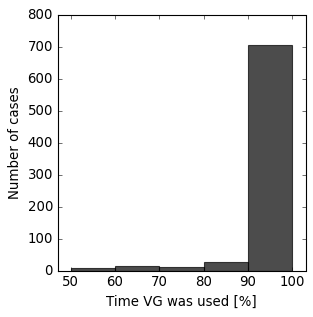

In [157]:
# In most VG cases when VG was used for >50% of the recording time it was used for >90% of the recording time

filetype='jpg'; dpi=200
bins = np.arange(50, 105, 10)

# Of those who had VG during >50% of time
dta = VG_duration[VG_duration['proportion'] > 0.5]

fig, ax = plt.subplots(figsize = [4,4])
ax.hist(dta['proportion'] * 100, bins=bins, color = 'black', alpha = 0.7) 

ax.set_xlim(47, 103)
ax.set_ylim(0, 800)
ax.set_xlabel('Time VG was used [%]', size = 12)
ax.set_ylabel('Number of cases', size = 12)
   
fig.savefig(os.path.join(DIR_WRITE, f'VG_proportion_conv.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

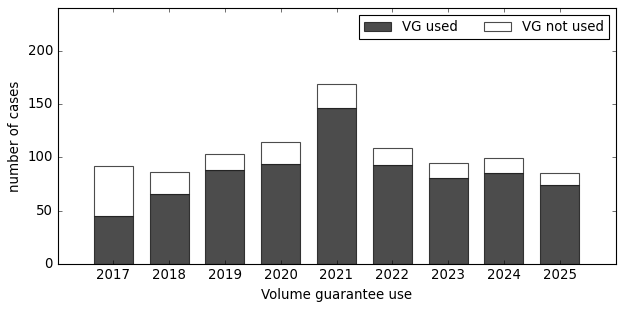

In [158]:
filetype='jpg'; dpi=200

fig, ax = plt.subplots(figsize = [9,4])
# plot the bar graph
ax.bar(np.arange(len(VG_use)), VG_use['VG_cases'], width=0.7, color='black', alpha=0.7)
ax.bar(np.arange(len(VG_use)), VG_use['noVG_cases'], bottom=VG_use['VG_cases'], width=0.7, color='white', alpha=0.7)

ax.set_xticks(np.arange(len(VG_use)), VG_use.index, rotation=0)
ax.set_xlim(-1, len(VG_use))
ax.set_ylim(0, 240)
ax.set_xlabel('Volume guarantee use', size = 12)
ax.set_ylabel('number of cases', size = 12)
ax.legend(['VG used', 'VG not used'], fontsize = 12, ncols=2)
   
fig.savefig(os.path.join(DIR_WRITE, f'VG_use_conventional.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

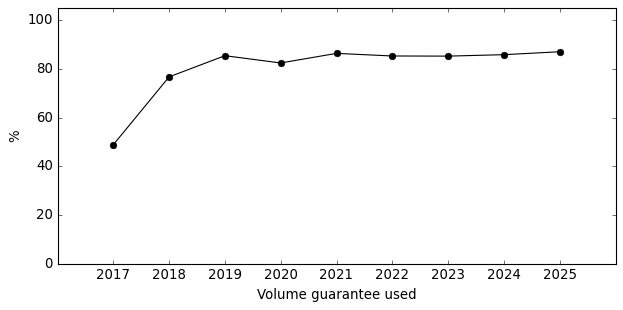

In [159]:
filetype='jpg'; dpi=200

fig, ax = plt.subplots(figsize = [9,4])
ax.plot(np.arange(len(VG_use)), VG_use['proportion'] * 100, marker='o', color='black', )

ax.set_xticks(np.arange(len(VG_use)), VG_use.index, rotation=0)
ax.set_xlim(-1, len(VG_use))
ax.set_ylim(0, 105)
ax.set_xlabel('Volume guarantee used', size = 12)
ax.set_ylabel('%', size = 12)
  
fig.savefig(os.path.join(DIR_WRITE, f'VG_use_conventional_proportion.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

In [160]:
# Significant increase in VG from 2017 to 2018
stats.fisher_exact([
                   [VG_use.loc[2017, 'VG_cases'], VG_use.loc[2017, 'noVG_cases']], 
                   [VG_use.loc[2018, 'VG_cases'], VG_use.loc[2018, 'noVG_cases']], 
                   ], alternative='two-sided')

SignificanceResult(statistic=0.2901353965183752, pvalue=0.00018253234025571353)

In [161]:
# Significant increase in VG from 2017 to 2018
stats.fisher_exact([
                   [VG_use.loc[2018, 'VG_cases'], VG_use.loc[2018, 'noVG_cases']], 
                   [VG_use.loc[2019, 'VG_cases'], VG_use.loc[2019, 'noVG_cases']], 
                   ], alternative='two-sided')

SignificanceResult(statistic=0.5625, pvalue=0.1365679088750305)

## B. For the subgroup of infants born at <32 weeks of gestation and transferred at <14 days of age - `QI-1a`

QI-1A. As Q1 but for a subgroup of infants born at <32 weeks gestation <14 days of age

In [163]:
VG_duration_below32 = {}

for year in settings_conv_years:
    for case, dta in settings_conv_years[year].items():

        # Only include infants with born at <32 weeks and transferred at <14 days of age
        if clinical_data.loc[case]['Gestational Age (weeks)'] >= 32 or clinical_data.loc[case]['Postnatal Age'] >= pd.to_timedelta('14d'):
            continue
        
        if case in settings_conv_vg_years[year]:
            VG_duration_below32[case] = (year, len(settings_conv_vg_years[year][case]), len(dta))
        else:
            VG_duration_below32[case] = (year, 0, len(dta)) # If there is no vg in the recording at all
        
VG_duration_below32 = DataFrame(VG_duration_below32).T
VG_duration_below32.columns = ['year', 'conv_vg', 'conv_total']
# In seconds (sampline rate was 0.5 Hz)
VG_duration_below32[[ 'conv_vg', 'conv_total']] = VG_duration_below32[[ 'conv_vg', 'conv_total']] * 2 
VG_duration_below32['proportion'] = VG_duration_below32['conv_vg'] / VG_duration_below32['conv_total']
VG_duration_below32.head()

,year,conv_vg,conv_total,proportion
AL000003,2017,0,5160,0.000000
AL000006,2017,0,2280,0.000000
AL000029,2017,0,2820,0.000000
AL000036,2017,3962,3962,1.000000
AL000052,2017,6138,6300,0.974286


In [164]:
# How many used VG for more than 50% of the recording time
(sum(VG_duration_below32['proportion'] > 0.5), sum(VG_duration_below32['proportion'] > 0.5), 
 sum(VG_duration_below32['proportion'] > 0.5) / len(VG_duration_below32))

(157, 157, 0.8486486486486486)

In [165]:
# The proportion of infants with VG used >50% of the time
VG_use_below32 =  {}
for year in clin_dta_years:
    dta = VG_duration_below32[VG_duration_below32['year'] == year]
    VG_use_below32[year] = (year, sum(dta['proportion'] > 0.5), sum(dta['proportion'] <= 0.5), len(dta), sum(dta['proportion'] >0.5)/len(dta))

VG_use_below32 = DataFrame(VG_use_below32).T
VG_use_below32.columns = ['year', 'VG_cases', 'noVG_cases', 'total_cases', 'proportion']
VG_use_below32

,year,VG_cases,noVG_cases,total_cases,proportion
2017,2017.0,12.0,11.0,23.0,0.521739
2018,2018.0,15.0,3.0,18.0,0.833333
2019,2019.0,20.0,1.0,21.0,0.952381
2020,2020.0,19.0,2.0,21.0,0.904762
2021,2021.0,26.0,2.0,28.0,0.928571
2022,2022.0,15.0,3.0,18.0,0.833333
2023,2023.0,18.0,2.0,20.0,0.900000
2024,2024.0,12.0,1.0,13.0,0.923077
2025,2025.0,20.0,3.0,23.0,0.869565


In [166]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'VG_use_below32.xlsx'))
VG_duration_below32.to_excel(writer, sheet_name='VG_duration')
VG_use_below32.to_excel(writer, sheet_name='yearly_data')
writer.close()

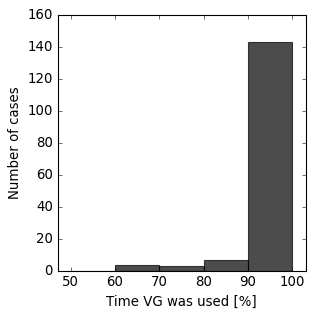

In [167]:
# In most VG cases when VG was used for >50% of the recording time it was used for >90% of the recording time

filetype='jpg'; dpi=200
bins = np.arange(50, 105, 10)

dta = VG_duration_below32[VG_duration_below32['proportion'] > 0.5]

fig, ax = plt.subplots(figsize = [4,4])
ax.hist(dta['proportion'] * 100, bins=bins, color = 'black', alpha = 0.7) 

ax.set_xlim(47, 103)
ax.set_ylim(0, 160)
ax.set_xlabel('Time VG was used [%]', size = 12)
ax.set_ylabel('Number of cases', size = 12)
   
fig.savefig(os.path.join(DIR_WRITE, f'VG_proportion_conv_below32.{filetype}'), dpi = dpi, format = filetype, 
    bbox_inches='tight', pad_inches=0.1)
plt.show();

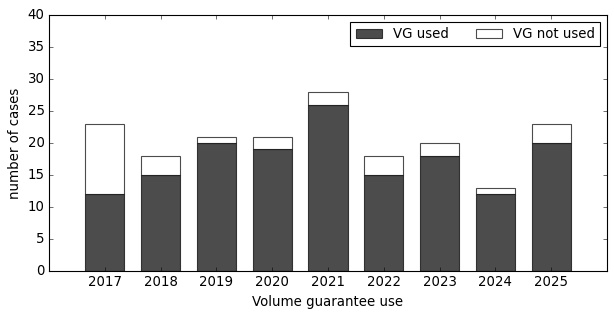

In [168]:
filetype='jpg'; dpi=200

fig, ax = plt.subplots(figsize = [9,4])
ax.bar(np.arange(len(VG_use_below32)), VG_use_below32['VG_cases'], width=0.7, color='black', alpha=0.7)
ax.bar(np.arange(len(VG_use_below32)), VG_use_below32['noVG_cases'], bottom=VG_use_below32['VG_cases'], width=0.7, color='white', alpha=0.7)

ax.set_xticks(np.arange(len(VG_use_below32)), VG_use_below32.index, rotation=0)
ax.set_xlim(-1, len(VG_use_below32))
ax.set_ylim(0, 40)
ax.set_xlabel('Volume guarantee use', size = 12)
ax.set_ylabel('number of cases', size = 12)
ax.legend(['VG used', 'VG not used'], fontsize = 12, ncols=2)
   
fig.savefig(os.path.join(DIR_WRITE, f'VG_use_below32_conventional.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

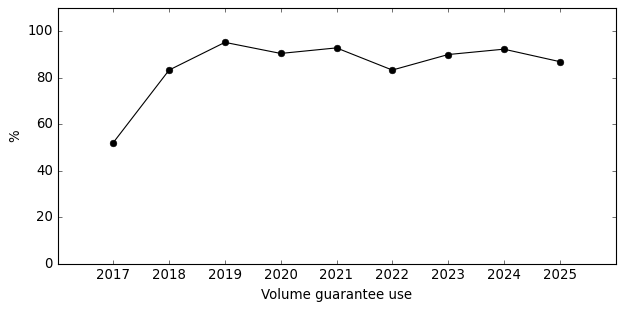

In [169]:
filetype='jpg'; dpi=200

fig, ax = plt.subplots(figsize = [9,4])
ax.plot(np.arange(len(VG_use_below32)), VG_use_below32['proportion'] * 100, marker='o', color='black', )

ax.set_xticks(np.arange(len(VG_use_below32)), VG_use_below32.index, rotation=0)
ax.set_xlim(-1, len(VG_use))
ax.set_ylim(0, 110)
ax.set_xlabel('Volume guarantee use', size = 12)
ax.set_ylabel('%', size = 12)

fig.savefig(os.path.join(DIR_WRITE, f'VG_use_conventional_proportion_below32.{filetype}'), 
            dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

In [170]:
# Significant increase in VG from 2017 to 2018
stats.fisher_exact([
                   [VG_use_below32.loc[2017, 'VG_cases'], VG_use_below32.loc[2017, 'noVG_cases']], 
                   [VG_use_below32.loc[2018, 'VG_cases'], VG_use_below32.loc[2018, 'noVG_cases']], 
                   ], alternative='two-sided')

SignificanceResult(statistic=0.21818181818181817, pvalue=0.05051930915695532)

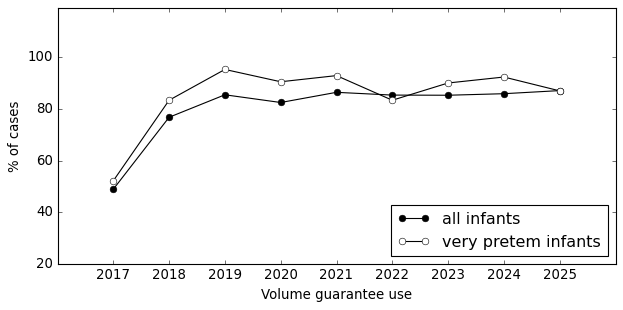

In [171]:
# Combine the the two graphs (all conventional VG cases and below 32/40 subset)

filetype='jpg'; dpi=200

fig, ax = plt.subplots(figsize = [9,4])
ax.plot(np.arange(len(VG_use)), VG_use['proportion'] * 100, marker='o', color='black', markerfacecolor='black')
ax.plot(np.arange(len(VG_use_below32)), VG_use_below32['proportion'] * 100, marker='o', color='black', markerfacecolor='white')

ax.set_xticks(np.arange(len(VG_use)), VG_use.index, rotation=0)
ax.set_xlim(-1, len(VG_use))
ax.set_ylim(20, 119)
ax.set_xlabel('Volume guarantee use', size = 12)
ax.set_ylabel('% of cases', size = 12)
ax.legend(['all infants', 'very pretem infants'], loc='lower right')

fig.savefig(os.path.join(DIR_WRITE, f'VG_use_conventional_proportion_both.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

### 16. Proportion of recordings with VG used during HFOV

Consider recordings where VG mode is used for >50% of the recording duration with HFOV

In [173]:
VG_duration_hfov = {}

for year in settings_hfov_years:
    for case, dta in settings_hfov_years[year].items():  
        if case in settings_hfov_vg_years[year]:
            VG_duration_hfov[case] = (year, len(settings_hfov_vg_years[year][case]), len(dta))
        else:
            VG_duration_hfov[case] = (year, 0, len(dta)) # If there is no hfov-vg in the recording at all
                
VG_duration_hfov = DataFrame(VG_duration_hfov).T
VG_duration_hfov.columns = ['year', 'hfov_vg', 'hfov_total']
# In seconds (sampline rate was 0.5 Hz)
VG_duration_hfov[['hfov_vg', 'hfov_total']] = VG_duration_hfov[['hfov_vg', 'hfov_total']] * 2 
VG_duration_hfov['proportion'] = VG_duration_hfov['hfov_vg'] / VG_duration_hfov['hfov_total']
VG_duration_hfov.head()

,year,hfov_vg,hfov_total,proportion
AT000033,2020,2424,2430,0.997531
AT000034,2020,1654,1654,1.000000
AT000048,2020,0,2844,0.000000
AT000081,2021,820,872,0.940367
AT000086,2021,0,2042,0.000000


In [174]:
# How many used VG for more than 50% of the recording time
(sum(VG_duration_hfov['proportion'] > 0.5), sum(VG_duration_hfov['proportion'] <= 0.5), 
 sum(VG_duration_hfov['proportion'] > 0.5) / len(VG_duration_hfov))

(51, 53, 0.49038461538461536)

In [175]:
VG_use_hfov =  {}

for year in clin_dta_years:
    dta = VG_duration_hfov[VG_duration_hfov['year'] == year]
    # VG used during >50% of the recording
    VG_use_hfov[year] = (year, sum(dta['proportion'] > 0.5), sum(dta['proportion'] <= 0.5), len(dta))

VG_use_hfov = DataFrame(VG_use_hfov).T
VG_use_hfov.columns = ['year', 'HFOV-VG_cases', 'HFOV-noVG_cases','total_cases',]
VG_use_hfov['proportion'] = VG_use_hfov['HFOV-VG_cases'] / VG_use_hfov['total_cases']
VG_use_hfov

,year,HFOV-VG_cases,HFOV-noVG_cases,total_cases,proportion
2017,2017,0,0,0,NaN
2018,2018,0,0,0,NaN
2019,2019,0,0,0,NaN
2020,2020,2,1,3,0.666667
2021,2021,10,8,18,0.555556
2022,2022,13,9,22,0.590909
2023,2023,7,9,16,0.437500
2024,2024,9,12,21,0.428571
2025,2025,10,14,24,0.416667


In [176]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'HFOV_VG_use.xlsx'))
VG_duration_hfov.to_excel(writer, sheet_name='VG_duration')
VG_use_hfov.to_excel(writer, sheet_name='yearly_data')
writer.close()

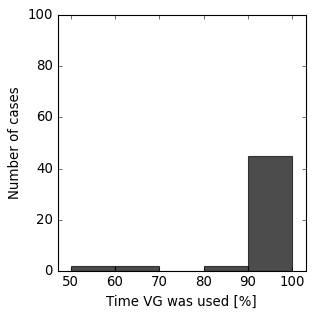

In [177]:
# In most HFOF-VG cases when VG was used for >50% of the recording time it was used for >90% of the recording time

filetype='jpg'; dpi=200
bins = np.arange(50, 105, 10)

# Of those who had VG during >50% of time
dta = VG_duration_hfov[VG_duration_hfov['proportion'] > 0.5]

fig, ax = plt.subplots(figsize = [4,4])
ax.hist(dta['proportion'] * 100, bins=bins, color = 'black', alpha = 0.7) 

ax.set_xlim(47, 103)
ax.set_ylim(0, 100)
ax.set_xlabel('Time VG was used [%]', size = 12)
ax.set_ylabel('Number of cases', size = 12)
   
fig.savefig(os.path.join(DIR_WRITE, f'VG_proportion_hfov.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

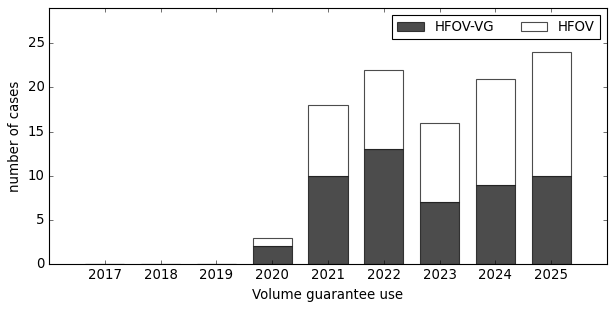

In [178]:
filetype='jpg'; dpi=200

fig, ax = plt.subplots(figsize = [9,4])
ax.bar(np.arange(len(VG_use_hfov)), VG_use_hfov['HFOV-VG_cases'], width=0.7, color='black', alpha=0.7)
ax.bar(np.arange(len(VG_use_hfov)), VG_use_hfov['HFOV-noVG_cases'], bottom=VG_use_hfov['HFOV-VG_cases'], width=0.7, color='white', alpha=0.7)

ax.set_xticks(np.arange(len(VG_use_hfov)), VG_use_hfov.index, rotation=0)
ax.set_xlim(-1, len(VG_use_hfov))
ax.set_ylim(0, 29)
ax.set_xlabel('Volume guarantee use', size = 12)
ax.set_ylabel('number of cases', size = 12)
ax.legend(['HFOV-VG', 'HFOV'], fontsize = 12, ncols=2)
   
fig.savefig(os.path.join(DIR_WRITE, f'VG_use_hfov.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

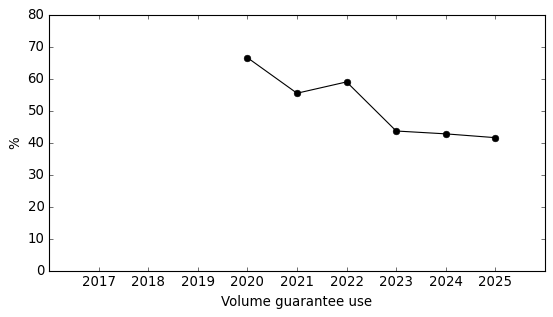

In [179]:
filetype='jpg'; dpi=200

fig, ax = plt.subplots(figsize = [8,4])

# plot the bar graph
ax.plot(np.arange(len(VG_use_hfov)), VG_use_hfov['proportion'] * 100, marker='o', color='black', )

ax.set_xticks(np.arange(len(VG_use)), VG_use.index, rotation=0)
ax.set_xlim(-1, len(VG_use_hfov))
ax.set_ylim(0, 80)
ax.set_xlabel('Volume guarantee use', size = 12)
ax.set_ylabel('%', size = 12)

fig.savefig(os.path.join(DIR_WRITE, f'VG_use_hfov_proportion.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

### 17. Proportion of cases with the VG set between 4 - 6 mL/kg in infants <14 days of age - `Q2`

QI-2. Proportion of infants receiving **conventional ventilation with volume guarantee who had the set target expired tidal volume between 4-6 mL/kg** for >90% of the time

- Only consider conventional VG recordings when VG was used for >50% of the recording time
- Consider recordings if VTset_kg was in the target range (4-6 mL/kg) for >90% of the recording
- The infant was younger than 14 days at the time of transfer

In [181]:
VG_in_target = {}

for year in settings_conv_vg_years:
    for case, dta in settings_conv_vg_years[year].items():
        
        # Exclude infants who were older than 2 weeks
        if clinical_data.loc[case]['Postnatal Age'] >= pd.to_timedelta('14day'):
            continue
        # Exclude if VG recordings was for <=50% of recording with conventional ventilation
        if case not in VG_dominant.index:
            continue
    
        # Calculate set VT to body weight kg
        dta['VG_set_kg'] = dta['VG_set'] / clin_dta_years[year].loc[case, 'Weight'] * 1000

        # Limit data to periods when target VT was 4-6 mL/kg
        dta_in_range = dta[(dta['VG_set_kg'] >= 4) & (dta['VG_set_kg'] <= 6)]
        VG_in_target[case] = (year, dta['VG_set_kg'].mean(), len(dta_in_range), len(dta))

VG_in_target = DataFrame(VG_in_target).T
VG_in_target.columns = ['year', 'VTset_mean [mL/kg]', 'VT_set_4_6', 'total']
VG_in_target['proportion'] = VG_in_target['VT_set_4_6'] / VG_in_target['total']
len(VG_in_target)

651

In [182]:
# Drop recordings which do not have the VTset values
VG_in_target = VG_in_target[VG_in_target['VTset_mean [mL/kg]'].notna()]
len(VG_in_target)

644

In [183]:
VG_in_target

,year,VTset_mean [mL/kg],VT_set_4_6,total,proportion
AL000008,2017.0,4.235663,3121.0,3121.0,1.000000
AL000011,2017.0,6.125799,0.0,2661.0,0.000000
AL000023,2017.0,2.095238,0.0,1470.0,0.000000
AL000034,2017.0,4.328096,2671.0,2671.0,1.000000
AL000036,2017.0,3.912346,0.0,1981.0,0.000000
...,...,...,...,...,...
AT001929,2025.0,4.922235,2063.0,2063.0,1.000000
AT001932,2025.0,4.659389,4515.0,4515.0,1.000000
AT001936,2025.0,5.483871,1245.0,1245.0,1.000000
AT001941,2025.0,3.846979,2.0,932.0,0.002146


In [184]:
sum(VG_in_target['proportion'] > 0.9), len(VG_in_target), sum(VG_in_target['proportion'] > 0.9) / len(VG_in_target), 

(483, 644, 0.75)

In [185]:
VG_in_target_years =  {}

for year in clin_dta_years:
    dta = VG_in_target[VG_in_target['year'] == year]
    VG_in_target_years[year] = (year, sum(dta['proportion'] >= 0.9), sum(dta['proportion'] < 0.9), len(dta), 
                                sum(dta['proportion'] >= 0.9) / len(dta) )

VG_in_target_years = DataFrame(VG_in_target_years).T
VG_in_target_years.columns = ['year', 'in_target_range', 'not_in_target_range', 'total_cases', 'proportion']
VG_in_target_years

,year,in_target_range,not_in_target_range,total_cases,proportion
2017,2017.0,25.0,11.0,36.0,0.694444
2018,2018.0,45.0,11.0,56.0,0.803571
2019,2019.0,59.0,16.0,75.0,0.786667
2020,2020.0,63.0,17.0,80.0,0.787500
2021,2021.0,84.0,34.0,118.0,0.711864
2022,2022.0,59.0,20.0,79.0,0.746835
2023,2023.0,46.0,20.0,66.0,0.696970
2024,2024.0,57.0,16.0,73.0,0.780822
2025,2025.0,45.0,16.0,61.0,0.737705


In [186]:
VG_in_target_years_pc = VG_in_target_years[['in_target_range', 'not_in_target_range', 'total_cases']].copy()
VG_in_target_years_pc = VG_in_target_years_pc.div(VG_in_target_years_pc['total_cases'] / 100, axis=0)
VG_in_target_years_pc

,in_target_range,not_in_target_range,total_cases
2017,69.444444,30.555556,100.0
2018,80.357143,19.642857,100.0
2019,78.666667,21.333333,100.0
2020,78.750000,21.250000,100.0
2021,71.186441,28.813559,100.0
2022,74.683544,25.316456,100.0
2023,69.696970,30.303030,100.0
2024,78.082192,21.917808,100.0
2025,73.770492,26.229508,100.0


In [187]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'VG_in_target.xlsx'))
VG_in_target.to_excel(writer, sheet_name='indiv_recs')
VG_in_target_years.to_excel(writer, sheet_name='yearly_data')
VG_in_target_years_pc.to_excel(writer, sheet_name='yearly_data_pc')
writer.close()

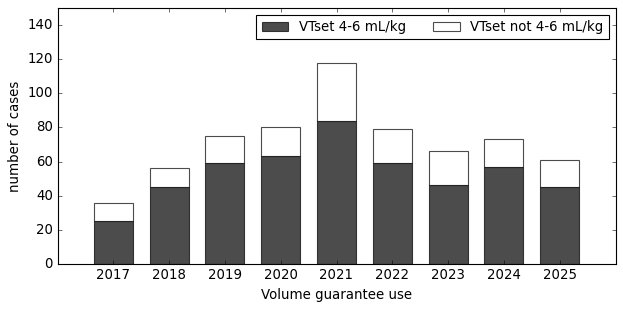

In [188]:
filetype='jpg'; dpi=200

fig, ax = plt.subplots(figsize = [9,4])
ax.bar(np.arange(len(VG_in_target_years)), VG_in_target_years['in_target_range'], width=0.7, color='black', alpha=0.7)
ax.bar(np.arange(len(VG_in_target_years)), VG_in_target_years['not_in_target_range'], 
       bottom=VG_in_target_years['in_target_range'], width=0.7, color='white', alpha=0.7)

ax.set_xticks(np.arange(len(VG_in_target_years)), VG_in_target_years.index, rotation=0)
ax.set_xlim(-1, len(VG_in_target_years))
ax.set_ylim(0, 150)
ax.set_xlabel('Volume guarantee use', size = 12)
ax.set_ylabel('number of cases', size = 12)
ax.legend(['VTset 4-6 mL/kg', 'VTset not 4-6 mL/kg'], fontsize = 12, ncols=2)
   
fig.savefig(os.path.join(DIR_WRITE, f'VG_in_target_years.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

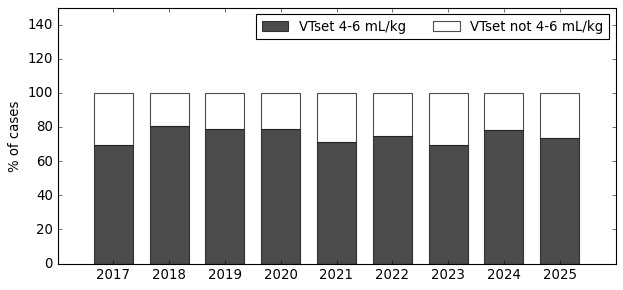

In [189]:
filetype='jpg'; dpi=200

fig, ax = plt.subplots(figsize = [9,4])
ax.bar(np.arange(len(VG_in_target_years_pc)), VG_in_target_years_pc['in_target_range'], width=0.7, color='black', alpha=0.7)
ax.bar(np.arange(len(VG_in_target_years_pc)), VG_in_target_years_pc['not_in_target_range'], 
       bottom=VG_in_target_years_pc['in_target_range'], width=0.7, color='white', alpha=0.7)

ax.set_xticks(np.arange(len(VG_in_target_years_pc)), VG_in_target_years_pc.index, rotation=0)
ax.set_xlim(-1, len(VG_in_target_years_pc))
ax.set_ylim(0, 150)
ax.set_xlabel('', size = 12)
ax.set_ylabel('% of cases', size = 12)
ax.legend(['VTset 4-6 mL/kg', 'VTset not 4-6 mL/kg'], fontsize = 12, ncols=2)
   
fig.savefig(os.path.join(DIR_WRITE, f'VG_in_target_years_pc.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

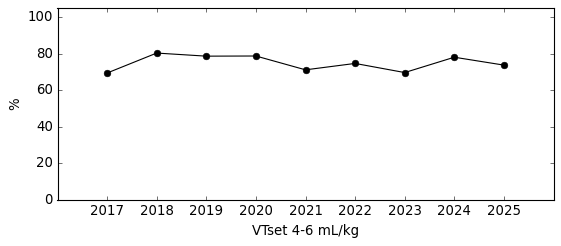

In [190]:
filetype='jpg'; dpi=200

fig, ax = plt.subplots(figsize = [8,3])
ax.plot(np.arange(len(VG_in_target_years)), VG_in_target_years['proportion'] * 100, marker='o', color='black', )

ax.set_xticks(np.arange(len(VG_in_target_years)), VG_in_target_years.index, rotation=0)
ax.set_xlim(-1, len(VG_in_target_years))
ax.set_ylim(0, 105)
ax.set_xlabel('VTset 4-6 mL/kg', size = 12)
ax.set_ylabel('%', size = 12)
   
fig.savefig(os.path.join(DIR_WRITE, f'VG_in_target_range_proportion.{filetype}'), dpi = dpi, format = filetype, 
    bbox_inches='tight', pad_inches=0.1)
plt.show();

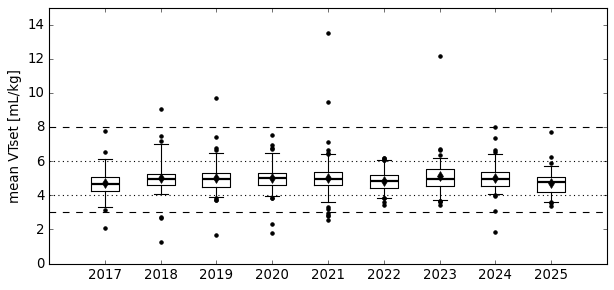

In [191]:
filetype='jpg'; dpi=200

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-'}; whiskerprops = {'color': 'black', 'linestyle': '-'}
capprops = {'color': 'black', 'linestyle': '-'}; flierprops = {'color': 'black', 'marker': '.'}

fig, ax = plt.subplots(figsize = [9,4])

VG_set_kg_mean = {}
for year in clin_dta_years:
    VG_set_kg_mean[year] = VG_in_target[VG_in_target['year'] == year]['VTset_mean [mL/kg]']

ax.boxplot(VG_set_kg_mean.values(), tick_labels = VG_set_kg_mean.keys(), whis = [5, 95], showfliers = True, showmeans = True, 
    meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)
ax.hlines(6, 0, len(clin_dta_years)+1, linestyle='dotted', color='black')
ax.hlines(4, 0, len(clin_dta_years)+1, linestyle='dotted', color='black')
ax.hlines(8, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')
ax.hlines(3, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')

ax.set_ylabel('mean VTset [mL/kg]')
ax.set_ylim(0, 15)

fig.savefig(os.path.join(DIR_WRITE, f'VT_set_mean.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

#### Look at the extremes

In [193]:
len(VG_in_target[VG_in_target['VTset_mean [mL/kg]'] > 6])

61

In [194]:
over_8 = VG_in_target[VG_in_target['VTset_mean [mL/kg]'] > 8]
over_8

,year,VTset_mean [mL/kg],VT_set_4_6,total,proportion
AL000374,2018.0,9.036937,0.0,2821.0,0.0
AL000465,2019.0,9.676368,0.0,2010.0,0.0
AT000204,2021.0,9.480159,0.0,5400.0,0.0
AT000574,2021.0,13.484723,0.0,6742.0,0.0
AT001235,2023.0,12.142857,0.0,1926.0,0.0


In [195]:
# All infants with >8 mL/kg target VT weighed <=1000 grams
over_8_clinical = clinical_data.loc[over_8.index]
over_8_clinical

,Case ID,Date of Birth,Gestational Age (weeks),Birth Weight,Postnatal Age,Corrected gestational Age (weeks),Weight,ICD,Pathology_English,Recording start,Recording end,Duration
AL000374,48806,2018-10-31 08:40:00,23.0,500.0,0 days 02:44:20,23.0,500.0,"[P072, P015, P22, P809, I959]","[Extreme immaturity of newborn, unspecified we...",2018-10-31 09:01:31,2018-10-31 11:24:20,0 days 02:22:49
AL000465,50028,2019-02-23 05:48:00,23.0,400.0,0 days 02:38:53,23.0,400.0,"[P22, P809, P072]","[Respiratory distress syndrome of newborn , Hy...",2019-02-23 07:12:23,2019-02-23 08:26:53,0 days 01:14:30
AT000204,57045,2021-04-03 11:22:00,27.0,700.0,0 days 04:28:14,27.0,700.0,"[P072, P015, P22, P809, P059, P704, _000]","[Extreme immaturity of newborn, unspecified we...",2021-04-03 12:45:29,2021-04-03 15:50:14,0 days 03:04:45
AT000574,59235,2021-12-28 17:13:00,27.0,1000.0,0 days 05:31:21,27.0,1000.0,"[P072, P22, I959, U072, _000]","[Extreme immaturity of newborn, unspecified we...",2021-12-28 18:27:55,2021-12-28 22:44:21,0 days 04:16:26
AT001235,63907,2023-08-30 12:41:00,22.0,280.0,0 days 02:58:33,22.0,280.0,"[P072, P22, P809, Z518, _000, P059]","[Extreme immaturity of newborn, unspecified we...",2023-08-30 14:18:35,2023-08-30 15:39:33,0 days 01:20:58


In [196]:
len(VG_in_target[VG_in_target['VTset_mean [mL/kg]'] < 4])

66

In [197]:
VTset_below_3 = VG_in_target[VG_in_target['VTset_mean [mL/kg]'] < 3]
VTset_below_3

,year,VTset_mean [mL/kg],VT_set_4_6,total,proportion
AL000023,2017.0,2.095238,0.0,1470.0,0.0
AL000239,2018.0,2.660324,0.0,3111.0,0.0
AL000405,2018.0,2.728056,0.0,3284.0,0.0
AL000428,2018.0,1.235636,0.0,7728.0,0.0
AL000450,2019.0,1.645911,0.0,2884.0,0.0
AL000935,2020.0,2.340702,0.0,1771.0,0.0
AL001003,2020.0,1.763602,0.0,619.0,0.0
AT000171,2021.0,2.941176,0.0,614.0,0.0
AT000228,2021.0,2.527233,0.0,507.0,0.0
AT000314,2021.0,2.864289,0.0,2319.0,0.0


In [198]:
VTset_below_3_clinical = clinical_data.loc[VTset_below_3.index]
len(VTset_below_3_clinical)

12

In [199]:
# All 11 infants with target VT <3 mL/kg were born at >35 weeks of gestation
VTset_below_3_clinical[['Postnatal Age', 'Corrected gestational Age (weeks)', 'Weight']]

,Postnatal Age,Corrected gestational Age (weeks),Weight
AL000023,0 days 02:23:39,35.0,2100.0
AL000239,1 days 15:00:53,39.2,3000.0
AL000405,0 days 06:30:04,38.0,3385.0
AL000428,2 days 14:37:50,40.4,3890.0
AL000450,0 days 07:09:02,37.0,2850.0
AL000935,0 days 09:02:16,37.1,3845.0
AL001003,0 days 13:28:16,38.1,5330.0
AT000171,0 days 05:56:14,39.0,3400.0
AT000228,0 days 03:26:58,37.0,2295.0
AT000314,0 days 04:33:37,40.0,3500.0


In [200]:
# 7 of the 11 infants with target VT <3 mL/kg had HIE
for i, dta in VTset_below_3_clinical.iterrows():
    print(i, dta['Pathology_English'])   

AL000023 ['Preterm newborn, unspecified weeks of gestation', 'Perinatal asphyxia', 'Newborn affected by other forms of placental separation and hemorrhage', 'Hypothermia of newborn, unspecified']
AL000239 ['Exstrophy of urinary bladder', 'Preterm newborn, unspecified weeks of gestation', 'Syndactyly, unspecified', 'Newborn affected by slow intrauterine growth, unspecified', 'Respiratory failure of newborn']
AL000405 ['Term newborn', 'Perinatal asphyxia', 'Convulsions of newborn', 'Hyperglycaemia']
AL000428 ['Term newborn', 'Convulsions of newborn', 'Tremor, unspecified']
AL000450 ['Term newborn', 'Perinatal asphyxia', 'Meconium aspiration', 'Other specified congenital malformations of intestine']
AL000935 ['Term newborn', 'Other heavy for gestational age newborn', 'Other respiratory distress of newborn']
AL001003 ['Term newborn', 'Syndrome of infant of a diabetic mother', 'Respiratory failure of newborn', '??']
AT000171 ['Term newborn', 'Other respiratory distress of newborn', 'Other n

### 18. Expired tidal volume of the recordings

#### A. non-VG recordings

QI-3: Proportion infants ventilated with conventional ventilation without volume guarantee where the mean expired tidal volume between 4-6 mL/kg

- Only consider conventional ventilation recordings when VG was used for <=50% of the recording time
- Only consider the non-VG part of recordings when there was both VG and non-VG ventilation

In [203]:
novg_VTemand = {}
VTemand_data_missing = []

for year in measurements_conv_novg_years:
    for case in measurements_conv_novg_years[year]:
        pars = measurements_conv_novg_years[year][case]

        # Exclude if VG recordings was for >50% of recording with conventional ventilation
        if case in VG_dominant.index:
            continue
        # No VTemand data (e.g, no flow sensor, IPPV)
        if 'VTemand_kg' not in pars:
            VTemand_data_missing.append(case)
            continue
        # Exclude data points when VTemand was zero as they most likely represent missing data points
        dta = pars[pars['VTemand_kg'] > 0]
        # Add one to avoid division by zero if always VTemand is always zero; multiply by 100 to make it percentage
        novg_VTemand[case] = (year, len(pars) * 2, dta['VTemand_kg'].mean(), 
                              len(dta[(dta['VTemand_kg'] >= 4) & (dta['VTemand_kg'] <= 6)]) / (len(dta)+1) * 100)

novg_VTemand = DataFrame(novg_VTemand).T
novg_VTemand.columns = ['year', 'novg_duration [s]', 'VTemand_mean [mL/kg]', 'VTemand_4_6 [%]']
len(novg_VTemand)

178

In [204]:
novg_VTemand.head()

,year,novg_duration [s],VTemand_mean [mL/kg],VTemand_4_6 [%]
AL000003,2017.0,5160.0,7.359800,20.728400
AL000006,2017.0,2280.0,3.332916,19.193690
AL000009,2017.0,2238.0,12.735319,0.000000
AL000014,2017.0,2340.0,3.163508,27.412468
AL000018,2017.0,2222.0,5.683203,63.873874


In [205]:
VTemand_data_missing

['AT000456', 'AT001172']

##### i. Group statistics on the mean expired tidal volume of each recording

In [207]:
novg_VTemand.groupby('year')['VTemand_mean [mL/kg]'].describe()

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2017.0,43.0,5.381280,2.303450,2.342781,3.718826,4.753480,6.385993,12.735319
2018.0,19.0,6.297306,3.043446,2.285559,3.976983,5.388725,8.061633,14.700923
2019.0,13.0,5.746260,2.748350,0.308431,3.938470,5.968468,6.972536,10.309135
2020.0,18.0,5.628965,3.888049,2.061355,3.480839,4.774143,6.383940,19.504820
2021.0,21.0,5.055056,3.597128,1.288997,2.317844,4.347022,6.287695,17.171601
2022.0,16.0,4.281048,1.552212,1.426270,3.047922,4.282740,5.481606,6.867554
2023.0,12.0,4.233066,2.655915,0.987982,2.078493,3.947835,5.335448,9.619171
2024.0,13.0,6.147953,3.751119,2.632765,4.499244,5.186529,7.237943,17.142472
2025.0,11.0,8.035621,6.894420,3.130165,5.774597,6.580453,6.949178,28.222656


In [208]:
novg_VTemand['VTemand_mean [mL/kg]'].describe()

count    166.000000
mean       5.547178
std        3.385064
min        0.308431
25%        3.546139
50%        5.094087
75%        6.602414
max       28.222656
Name: VTemand_mean [mL/kg], dtype: float64

In [209]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'noVG_VTemand_mean.xlsx'))
novg_VTemand.to_excel(writer, sheet_name='data')
novg_VTemand.groupby('year')['VTemand_mean [mL/kg]'].describe().to_excel(writer, sheet_name='yearly_stats')
novg_VTemand['VTemand_mean [mL/kg]'].describe().to_excel(writer, sheet_name='combined_stats')
writer.close()

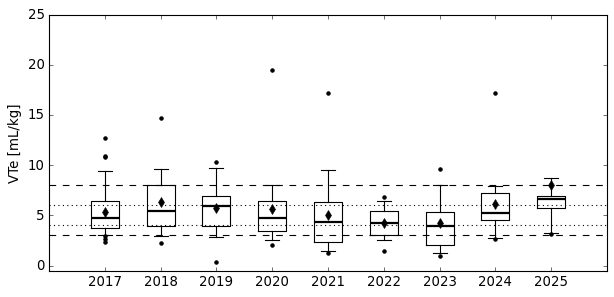

In [210]:
filetype='jpg'; dpi=200

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-'}; whiskerprops = {'color': 'black', 'linestyle': '-'}
capprops = {'color': 'black', 'linestyle': '-'}; flierprops = {'color': 'black', 'marker': '.'}

fig, ax = plt.subplots(figsize = [9,4])

VTemand_kg = {}
for year in clin_dta_years:
    VTemand_kg[year] = novg_VTemand[novg_VTemand['year'] == year]['VTemand_mean [mL/kg]'].dropna()
ax.boxplot(VTemand_kg.values(), tick_labels=VTemand_kg.keys(), whis = [5, 95], showfliers = True, showmeans = True, 
    meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)
ax.hlines(6, 0, len(clin_dta_years)+1, linestyle='dotted', color='black')
ax.hlines(4, 0, len(clin_dta_years)+1, linestyle='dotted', color='black')
ax.hlines(8, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')
ax.hlines(3, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')
ax.set_ylabel('VTe [mL/kg]')
ax.set_ylim(-0.5, 25)

fig.savefig(os.path.join(DIR_WRITE, f'VTemand_kg_novg_mean.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

##### ii. Group statistics on the % time the expired tidal volume is between 4-6 mL/kg

In [212]:
novg_VTemand.groupby('year')['VTemand_4_6 [%]'].describe()

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2017.0,47.0,29.397551,23.529946,0.0,8.210227,31.250000,44.630835,81.307794
2018.0,20.0,22.487022,25.478277,0.0,1.498809,12.307957,34.549274,90.048154
2019.0,15.0,22.175148,27.750902,0.0,0.480399,10.415671,37.691349,84.049080
2020.0,20.0,24.099822,22.688398,0.0,7.537728,15.112089,42.307179,64.098728
2021.0,22.0,23.656841,30.045429,0.0,0.689034,7.092956,39.753440,98.745174
2022.0,16.0,33.055025,27.734848,0.0,4.802584,36.354036,54.120841,75.108899
2023.0,13.0,32.002198,36.331167,0.0,2.744739,12.422907,61.025224,91.724138
2024.0,14.0,29.246105,34.007393,0.0,3.446959,7.683949,59.647253,86.690018
2025.0,11.0,28.226908,27.941648,0.0,3.646941,28.447025,40.122167,90.505676


In [213]:
novg_VTemand['VTemand_4_6 [%]'].describe()

count    178.000000
mean      27.142415
std       27.098617
min        0.000000
25%        2.825798
50%       17.616072
75%       44.544658
max       98.745174
Name: VTemand_4_6 [%], dtype: float64

In [214]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'noVG_VTemand_4_6_pc.xlsx'))
novg_VTemand.to_excel(writer, sheet_name='data')
novg_VTemand.groupby('year')['VTemand_4_6 [%]'].describe().to_excel(writer, sheet_name='yearly_stats')
novg_VTemand['VTemand_4_6 [%]'].describe().to_excel(writer, sheet_name='combined_stats')
writer.close()

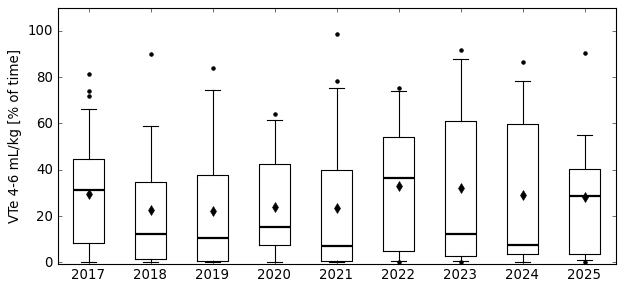

In [215]:
filetype='jpg'; dpi=200

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-'}; whiskerprops = {'color': 'black', 'linestyle': '-'}
capprops = {'color': 'black', 'linestyle': '-'}; flierprops = {'color': 'black', 'marker': '.'}

fig, ax = plt.subplots(figsize = [9,4])

VTemand_kg = {}
for year in clin_dta_years:
    VTemand_kg[year] = novg_VTemand[novg_VTemand['year'] == year]['VTemand_4_6 [%]'].dropna()
ax.boxplot(VTemand_kg.values(), tick_labels=VTemand_kg.keys(), whis = [5, 95], showfliers = True, showmeans = True, 
    meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)
ax.set_ylabel('VTe 4-6 mL/kg [% of time]')
ax.set_ylim(-0.5, 110)

fig.savefig(os.path.join(DIR_WRITE, f'VTemand_kg_novg_4_6_pc.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

##### iii. Look at extreme values (mean VTe <3 mL/kg or >8 mL/kg)

In [217]:
# Below 3 mL/kg
novg_VTemand_below_3 = novg_VTemand[novg_VTemand['VTemand_mean [mL/kg]'] < 3].sort_values('VTemand_mean [mL/kg]')
len(novg_VTemand_below_3)

27

In [218]:
novg_VTemand_below_3.head(10)

,year,novg_duration [s],VTemand_mean [mL/kg],VTemand_4_6 [%]
AL000520,2019.0,2128.0,0.308431,0.000000
AT001223,2023.0,5116.0,0.987982,2.744739
AT001119,2023.0,3122.0,1.270699,2.149093
AT000503,2021.0,8570.0,1.288997,5.653626
AT000761,2022.0,5012.0,1.426270,0.634456
AT000247,2021.0,5690.0,1.467126,0.607477
AT001029,2023.0,1118.0,1.631946,0.387597
AT000207,2021.0,6990.0,1.633184,13.314883
AL000754,2020.0,3008.0,2.061355,2.054795
AT000142,2021.0,4738.0,2.157139,0.422654


In [219]:
# Over 8 mL/kg
novg_VTemand_over_8 = novg_VTemand[novg_VTemand['VTemand_mean [mL/kg]'] > 8].sort_values('VTemand_mean [mL/kg]')
len(novg_VTemand_over_8)

22

In [220]:
novg_VTemand_over_8.tail(10)

,year,novg_duration [s],VTemand_mean [mL/kg],VTemand_4_6 [%]
AL000707,2019.0,1650.0,9.692364,4.479419
AL000528,2019.0,10382.0,10.309135,0.057781
AL000117,2017.0,6000.0,10.813366,0.566478
AL000097,2017.0,1454.0,10.879033,5.339105
AL000009,2017.0,2238.0,12.735319,0.000000
AL000280,2018.0,3126.0,14.700923,0.000000
AT001572,2024.0,1742.0,17.142472,0.000000
AT000330,2021.0,1840.0,17.171601,0.000000
AL000951,2020.0,3648.0,19.504820,0.000000
AT001831,2025.0,5512.0,28.222656,0.000000


#### B. VG recordings

In [222]:
vg_VTemand = {}
VTemand_data_missing = []

for year in measurements_conv_vg_years:
    for case in measurements_conv_vg_years[year]:
        pars = measurements_conv_vg_years[year][case]

        # Exclude if VG recordings was for <=50% of recording with conventional ventilation
        if case not in VG_dominant.index:
            continue
        # No VTemand data (e.g, no flow sensor, IPPV)
        if 'VTemand_kg' not in pars:
            VTemand_data_missing.append(case)
            continue
        # Exclude data points when VTemand was zero as they most likely represent missing data points
        dta = pars[pars['VTemand_kg'] > 0]
        # Add one to avoid division by zero if always VTemand is always zero; multiply by 100 to make it percentage
        vg_VTemand[case] = (year, len(pars) * 2, dta['VTemand_kg'].mean(),
                           len(dta[(dta['VTemand_kg'] >= 4) & (dta['VTemand_kg'] <= 6)]) / (len(dta)+1) * 100)

vg_VTemand = DataFrame(vg_VTemand).T
vg_VTemand.columns = ['year', 'vg_duration [s]', 'VTemand_mean [mL/kg]', 'VTemand_4_6 [%]']
len(vg_VTemand)

760

In [223]:
vg_VTemand.head()

,year,vg_duration [s],VTemand_mean [mL/kg],VTemand_4_6 [%]
AL000008,2017.0,6242.0,5.149199,72.805894
AL000011,2017.0,5322.0,4.349247,72.802404
AL000023,2017.0,2940.0,3.329087,19.319728
AL000034,2017.0,5342.0,4.127933,63.708459
AL000036,2017.0,3962.0,4.019525,15.741675


##### i. Group statistics on the mean expired tidal volume of each recording

In [225]:
vg_VTemand.groupby('year')['VTemand_mean [mL/kg]'].describe()

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2017.0,45.0,4.858682,1.337457,1.753571,3.982011,4.806524,5.569683,7.953177
2018.0,65.0,4.974762,1.509598,1.123516,4.157268,4.824134,5.532140,11.673163
2019.0,88.0,5.168828,1.388239,1.616505,4.259549,4.882438,5.906378,9.566825
2020.0,94.0,4.936223,1.372755,1.546393,4.200098,4.791617,5.430143,10.260417
2021.0,140.0,5.081035,1.943066,2.503763,4.346909,4.885200,5.423743,22.531371
2022.0,89.0,4.952941,1.606747,2.677244,4.106920,4.709506,5.329839,14.823626
2023.0,78.0,4.762231,1.301655,1.070325,4.097877,4.810846,5.642382,7.899584
2024.0,85.0,4.999430,1.183307,1.933699,4.408836,4.929812,5.414424,9.327352
2025.0,74.0,4.948237,1.242306,2.376063,4.212739,4.775722,5.211755,10.676074


In [226]:
vg_VTemand['VTemand_mean [mL/kg]'].describe()

count    758.000000
mean       4.980995
std        1.493924
min        1.070325
25%        4.217982
50%        4.847548
75%        5.480242
max       22.531371
Name: VTemand_mean [mL/kg], dtype: float64

In [227]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'VG_VTemand.xlsx'))
vg_VTemand.to_excel(writer, sheet_name='data')
vg_VTemand.groupby('year')['VTemand_mean [mL/kg]'].describe().to_excel(writer, sheet_name='yearly_stats')
vg_VTemand['VTemand_mean [mL/kg]'].describe().to_excel(writer, sheet_name='combined_stats')
writer.close()

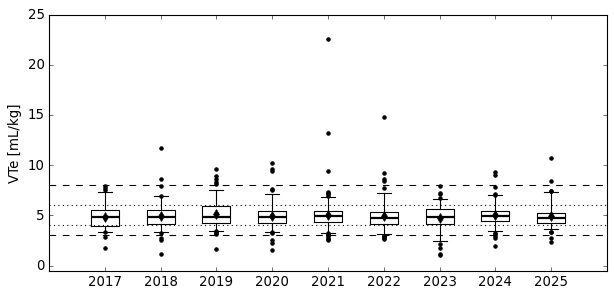

In [228]:
filetype='jpg'; dpi=200

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-'}; whiskerprops = {'color': 'black', 'linestyle': '-'}
capprops = {'color': 'black', 'linestyle': '-'}; flierprops = {'color': 'black', 'marker': '.'}

fig, ax = plt.subplots(figsize = [9,4])

VTemand_kg = {}
for year in clin_dta_years:
    VTemand_kg[year] = vg_VTemand[vg_VTemand['year'] == year]['VTemand_mean [mL/kg]'].dropna()

ax.boxplot(VTemand_kg.values(), tick_labels=VTemand_kg.keys(), whis = [5, 95], showfliers = True, showmeans = True, 
    meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)
ax.hlines(6, 0, len(clin_dta_years)+1, linestyle='dotted', color='black')
ax.hlines(4, 0, len(clin_dta_years)+1, linestyle='dotted', color='black')
ax.hlines(8, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')
ax.hlines(3, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')

ax.set_ylabel('VTe [mL/kg]')
ax.set_ylim(-0.5, 25)

fig.savefig(os.path.join(DIR_WRITE, f'VTemand_kg_vg_mean.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

##### ii. Group statistics on the % time the expired tidal volume is between 4-6 mL/kg

In [230]:
vg_VTemand.groupby('year')['VTemand_4_6 [%]'].describe()

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2017.0,45.0,47.507240,33.062640,0.140548,18.635438,50.458716,76.664056,99.037750
2018.0,66.0,53.925345,34.773716,0.000000,25.478918,57.120996,87.097474,99.652053
2019.0,88.0,53.215332,30.705582,0.000000,27.380575,55.358199,80.282631,99.777942
2020.0,94.0,59.884065,34.896894,0.000000,29.023804,67.060156,93.494185,99.954065
2021.0,140.0,59.539104,31.669215,0.000000,37.910231,69.410254,85.916405,99.941038
2022.0,89.0,57.566075,31.836210,0.000000,28.113590,64.122563,85.982340,99.950690
2023.0,79.0,56.148067,35.227347,0.000000,23.633134,62.439807,91.752787,98.703257
2024.0,85.0,61.564487,32.756974,0.000000,40.587695,70.097218,90.356977,99.914676
2025.0,74.0,62.606519,30.675998,0.722311,38.656152,71.354167,88.022249,99.960846


In [231]:
vg_VTemand['VTemand_4_6 [%]'].describe()

count    760.000000
mean      57.591271
std       32.823695
min        0.000000
25%       28.111542
50%       63.708799
75%       88.381201
max       99.960846
Name: VTemand_4_6 [%], dtype: float64

In [232]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'VG_VTemand_4_6_pc.xlsx'))
vg_VTemand.to_excel(writer, sheet_name='data')
vg_VTemand.groupby('year')['VTemand_4_6 [%]'].describe().to_excel(writer, sheet_name='yearly_stats')
vg_VTemand['VTemand_4_6 [%]'].describe().to_excel(writer, sheet_name='combined_stats')
writer.close()

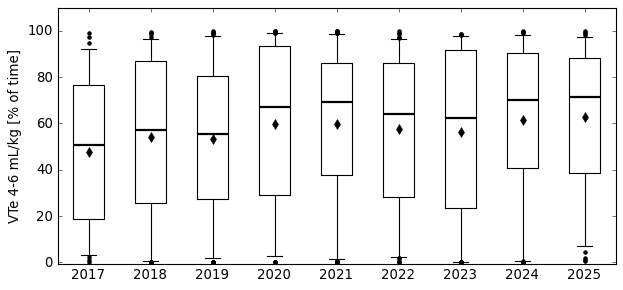

In [233]:
filetype='jpg'; dpi=200

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-'}; whiskerprops = {'color': 'black', 'linestyle': '-'}
capprops = {'color': 'black', 'linestyle': '-'}; flierprops = {'color': 'black', 'marker': '.'}

fig, ax = plt.subplots(figsize = [9,4])

VTemand_kg = {}
for year in clin_dta_years:
    VTemand_kg[year] = vg_VTemand[vg_VTemand['year'] == year]['VTemand_4_6 [%]'].dropna()
ax.boxplot(VTemand_kg.values(), tick_labels=VTemand_kg.keys(), whis = [5, 95], showfliers = True, showmeans = True, 
    meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)
ax.set_ylabel('VTe 4-6 mL/kg [% of time]')
ax.set_ylim(-0.5, 110)

fig.savefig(os.path.join(DIR_WRITE, f'VTemand_kg_vg_4_6_pc.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

##### iii. Look at extreme values (<3 mL/kg or >8 mL/kg)

In [235]:
vg_VTemand_below_3 = vg_VTemand[vg_VTemand['VTemand_mean [mL/kg]'] < 3].sort_values('VTemand_mean [mL/kg]')
len(vg_VTemand_below_3)

28

In [236]:
vg_VTemand_below_3.head(10)

,year,vg_duration [s],VTemand_mean [mL/kg],VTemand_4_6 [%]
AT001216,2023.0,1344.0,1.070325,0.000000
AT000935,2023.0,9462.0,1.110606,0.000000
AL000428,2018.0,15456.0,1.123516,0.000000
AL001003,2020.0,1238.0,1.546393,0.000000
AL000450,2019.0,5768.0,1.616505,0.000000
AT001077,2023.0,834.0,1.707599,0.000000
AL000038,2017.0,4830.0,1.753571,3.941909
AT001573,2024.0,2346.0,1.933699,0.000000
AT001022,2023.0,4276.0,2.118644,8.732394
AL000935,2020.0,3542.0,2.281887,0.000000


In [237]:
vg_VTemand_over_8 = vg_VTemand[vg_VTemand['VTemand_mean [mL/kg]'] > 8].sort_values('VTemand_mean [mL/kg]')
len(vg_VTemand_over_8)

21

In [238]:
vg_VTemand_over_8.tail(10)

,year,vg_duration [s],VTemand_mean [mL/kg],VTemand_4_6 [%]
AL000921,2020.0,4140.0,9.376225,5.024155
AT000204,2021.0,10800.0,9.413537,0.000000
AL000440,2019.0,3870.0,9.566825,0.154959
AL000981,2020.0,4358.0,9.609611,5.963303
AL000922,2020.0,960.0,10.260417,0.000000
AT001640,2025.0,2664.0,10.676074,0.826446
AL000348,2018.0,2422.0,11.673163,0.416667
AT000574,2021.0,13484.0,13.239597,0.317612
AT000851,2022.0,4530.0,14.823626,0.000000
AT000179,2021.0,1922.0,22.531371,0.000000


#### C. Compare occurrence of <6 or >4 mL/kg among VG and non-VG recordings

In [240]:
len(vg_VTemand[(vg_VTemand['VTemand_mean [mL/kg]'] >+ 4) & (vg_VTemand['VTemand_mean [mL/kg]'] <= 6)])

493

In [241]:
A = len(vg_VTemand[(vg_VTemand['VTemand_mean [mL/kg]'] >= 4) & (vg_VTemand['VTemand_mean [mL/kg]'] <=6)]) 
B = len(vg_VTemand[(vg_VTemand['VTemand_mean [mL/kg]'] < 4) | (vg_VTemand['VTemand_mean [mL/kg]'] > 6)])
C = len(novg_VTemand[(novg_VTemand['VTemand_mean [mL/kg]'] >= 4) & (novg_VTemand['VTemand_mean [mL/kg]'] <=6)]) 
D = len(novg_VTemand[(novg_VTemand['VTemand_mean [mL/kg]'] < 4) | (novg_VTemand['VTemand_mean [mL/kg]'] > 6)])

A, B, C, D

(493, 265, 52, 114)

In [242]:
# Proportion of infants ventilated with VG whose mean VTemand was 4-6 mL/kg
A / (A + B)

0.6503957783641161

In [243]:
# Proportion of infants ventilated without VG whose mean VTemand was 4-6 mL/kg (QI-3)
C / (C + D)

0.3132530120481928

In [244]:
stats.fisher_exact([[A, B], [C, D]], alternative='two-sided')

SignificanceResult(statistic=4.078519593613933, pvalue=2.2568241764618376e-15)

#### D. Compare the percentage of time spent in 4-6 mL/kg

In [246]:
stats.mannwhitneyu(vg_VTemand['VTemand_4_6 [%]'], novg_VTemand['VTemand_4_6 [%]'])

MannwhitneyuResult(statistic=102663.0, pvalue=5.0387217664478945e-27)

### 19. Proportion of infants with a median Pdiff (Pmax - PIP) was 5-15 cmH$_2$O - `QI-4`

I-4. Proportion of infants ventilated using **conventional ventilation with volume guarantee where the median difference between Pmax and PIP was 5-15 cmH2O.**

In [248]:
Pdiff_median = {}

for year in settings_conv_vg_years:
    for case in settings_conv_vg_years[year]:
        pars = measurements_conv_vg_years[year][case]
        settings = settings_conv_vg_years[year][case]

        # Exclude if VG recordings was for <=50% of recording with conventional ventilation
        if case not in VG_dominant.index:
            continue     
        Pdiff = settings['PIP_set'] - pars['PIP']
        Pdiff_median[case] = (year, Pdiff.median())

Pdiff_median = DataFrame(Pdiff_median).T
Pdiff_median.columns = ['year', 'Pdiff (median)']
Pdiff_median.head()

,year,Pdiff (median)
AL000008,2017.0,14.5
AL000011,2017.0,0.3
AL000023,2017.0,10.3
AL000034,2017.0,4.0
AL000036,2017.0,4.9


In [249]:
# Proportion of recordings in the target range (Pdiff 5-10 cmH2O)
Pdiff_in_target = Pdiff_median[(Pdiff_median['Pdiff (median)'] >= 5) & (Pdiff_median['Pdiff (median)'] <= 15)]
len(Pdiff_in_target), len(Pdiff_median), len(Pdiff_in_target) / len(Pdiff_median)

(328, 772, 0.42487046632124353)

In [250]:
# Proportion of infants in the target range during each year
Pdiff_median_in_target_yearly =  {}

for year in clin_dta_years:
    dta = Pdiff_median[Pdiff_median['year'] == year]
    in_range = sum((dta['Pdiff (median)'] >= 5) & (dta['Pdiff (median)'] <= 15))
    Pdiff_median_in_target_yearly[year] = (year, in_range, len(dta), in_range / len(dta) )

Pdiff_median_in_target_yearly = DataFrame(Pdiff_median_in_target_yearly).T
Pdiff_median_in_target_yearly.columns = ['year', 'in_target_range', 'total_cases', 'proportion']
Pdiff_median_in_target_yearly

,year,in_target_range,total_cases,proportion
2017,2017.0,23.0,45.0,0.511111
2018,2018.0,36.0,66.0,0.545455
2019,2019.0,30.0,88.0,0.340909
2020,2020.0,47.0,94.0,0.500000
2021,2021.0,40.0,146.0,0.273973
2022,2022.0,35.0,93.0,0.376344
2023,2023.0,35.0,81.0,0.432099
2024,2024.0,39.0,85.0,0.458824
2025,2025.0,43.0,74.0,0.581081


In [251]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'Pdiff_median.xlsx'))
Pdiff_median.to_excel(writer, sheet_name='Pdiff_median')
Pdiff_median_in_target_yearly.to_excel(writer, sheet_name='Pdiff_in_target_yearly')
writer.close()

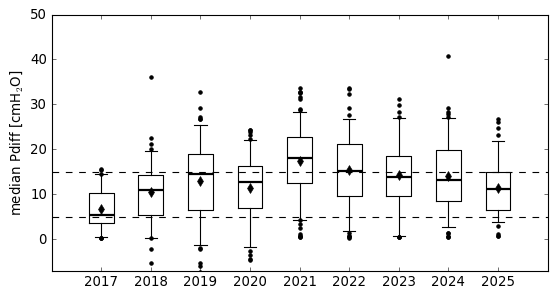

In [252]:
filetype='jpg'; dpi=200

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-'}; whiskerprops = {'color': 'black', 'linestyle': '-'}
capprops = {'color': 'black', 'linestyle': '-'}; flierprops = {'color': 'black', 'marker': '.'}

fig, ax = plt.subplots(figsize = [8,4])
Pdiff_median.groupby('year').boxplot(ax=ax, column=['Pdiff (median)'], whis = [5, 95], subplots=False, showfliers = True, 
    showmeans = True, grid=False, meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, 
    capprops=capprops, flierprops = flierprops)
ax.hlines(5, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')
ax.hlines(15, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')

ax.set_xticks(np.arange(1, len(Pdiff_median.groupby('year').groups)+1), np.arange(2017, 2026), rotation=0)
ax.set_ylabel('median Pdiff [cmH$_2$O]')
ax.set_ylim(-7,50)

fig.savefig(os.path.join(DIR_WRITE, f'Pdiff_median.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

#### A. In how many was cases were Pdiff outside the target range (<5 cmH2O or >15 cmH2O)

In [254]:
len(Pdiff_median[Pdiff_median['Pdiff (median)'] < 5]), len(Pdiff_median[Pdiff_median['Pdiff (median)'] < 5]) / len(Pdiff_median)

(120, 0.15544041450777202)

In [255]:
Pdiff_median[Pdiff_median['Pdiff (median)'] < 5].groupby('year').size() / Pdiff_median.groupby('year').size()

year
2017.0    0.444444
2018.0    0.242424
2019.0    0.204545
2020.0    0.159574
2021.0    0.061644
2022.0    0.096774
2023.0    0.135802
2024.0    0.117647
2025.0    0.162162
dtype: float64

In [256]:
# For some recordings the median Pdiff was zero or less (PIP reached Pmax in more the half of the inflations)
len(Pdiff_median[Pdiff_median['Pdiff (median)'] <= 0])

16

In [257]:
len(Pdiff_median[Pdiff_median['Pdiff (median)'] > 15]), len(Pdiff_median[Pdiff_median['Pdiff (median)'] > 15]) / len(Pdiff_median)

(324, 0.41968911917098445)

In [258]:
Pdiff_median[Pdiff_median['Pdiff (median)'] > 15].groupby('year').size() / Pdiff_median.groupby('year').size()

year
2017.0    0.044444
2018.0    0.212121
2019.0    0.454545
2020.0    0.340426
2021.0    0.664384
2022.0    0.526882
2023.0    0.432099
2024.0    0.423529
2025.0    0.256757
dtype: float64

#### B. Compare the first and second half of the period

In [260]:
Pdiff_median[Pdiff_median['Pdiff (median)'] < 5].groupby('year').size().loc[2017:2020].sum()

69

In [261]:
Pdiff_median.groupby('year').size().loc[2017:2020].sum()

293

In [262]:
(Pdiff_median[Pdiff_median['Pdiff (median)'] < 5].groupby('year').size().loc[2017:2020].sum() / 
    Pdiff_median.groupby('year').size().loc[2017:2020].sum())

0.2354948805460751

In [263]:
Pdiff_median[Pdiff_median['Pdiff (median)'] < 5].groupby('year').size().loc[2021:2025].sum()

51

In [264]:
Pdiff_median.groupby('year').size().loc[2021:2025].sum()

479

In [265]:
(Pdiff_median[Pdiff_median['Pdiff (median)'] < 5].groupby('year').size().loc[2021:2025].sum() / 
    Pdiff_median.groupby('year').size().loc[2021:2025].sum())

0.10647181628392484

In [266]:
# Significant increase in VG from 2017-2020 to 2021-2025, performing Fisher's exact test on the data
odd_ratio, p_value = stats.fisher_exact([
        [Pdiff_median[Pdiff_median['Pdiff (median)'] < 5].groupby('year').size().loc[2017:2020].sum(), 
         Pdiff_median.groupby('year').size().loc[2017:2020].sum()], 
        [Pdiff_median[Pdiff_median['Pdiff (median)'] < 5].groupby('year').size().loc[2021:2025].sum(),
         Pdiff_median.groupby('year').size().loc[2021:2025].sum()]
                                        ], alternative='two-sided')
odd_ratio, p_value

(2.2118048584621564, 8.54738571826924e-05)

### 20. What was the median leak in each recording over the years

In [268]:
Leak_median = {}

for year in settings_conv_vg_years:
    for case in settings_conv_vg_years[year]:
        pars = measurements_conv_vg_years[year][case]

        # Exclude if VG recordings was for <=50% of recording with conventional ventilation
        if case not in VG_dominant.index:
            continue     
        Leak_median[case] = (year, pars['Leak'].median())

Leak_median = DataFrame(Leak_median).T
Leak_median.columns = ['year', 'Leak (median)']
Leak_median.head()

,year,Leak (median)
AL000008,2017.0,0.0
AL000011,2017.0,0.0
AL000023,2017.0,38.0
AL000034,2017.0,0.0
AL000036,2017.0,0.0


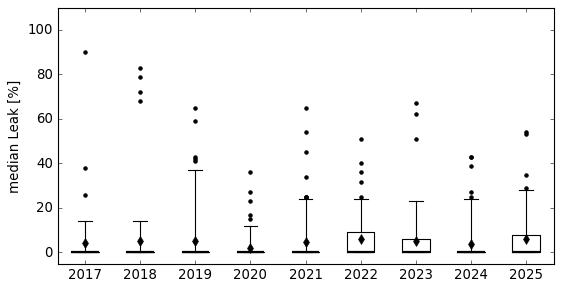

In [269]:
filetype='jpg'; dpi=200

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-'}; whiskerprops = {'color': 'black', 'linestyle': '-'}
capprops = {'color': 'black', 'linestyle': '-'}; flierprops = {'color': 'black', 'marker': '.'}

fig, ax = plt.subplots(figsize = [8,4])
Leak_median.groupby('year').boxplot(ax=ax, column=['Leak (median)'], whis = [5, 95], subplots=False, showfliers = True, 
    showmeans = True, grid=False, meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, 
    capprops=capprops, flierprops = flierprops)

ax.set_xticks(np.arange(1, len(Pdiff_median.groupby('year').groups)+1), np.arange(2017, 2026), rotation=0)
ax.set_ylabel('median Leak [%]')
ax.set_ylim(-5,110)

fig.savefig(os.path.join(DIR_WRITE, f'Leak_median.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

#### B. Compare the first and second half of the period

In [271]:
Leak_median.groupby('year').describe().loc[2017:2020]

Leak (median)                                               
               count      mean        std  min  25%  50%  75%   max
year                                                               
2017.0          45.0  4.022222  14.903460  0.0  0.0  0.0  0.0  90.0
2018.0          66.0  5.098485  18.242642  0.0  0.0  0.0  0.0  83.0
2019.0          88.0  4.954545  13.041850  0.0  0.0  0.0  0.0  65.0
2020.0          94.0  1.893617   5.930544  0.0  0.0  0.0  0.0  36.0

In [272]:
Leak_median.groupby('year').describe().loc[2021:2025]

Leak (median)                                               
               count      mean        std  min  25%  50%  75%   max
year                                                               
2021.0         146.0  4.729452  10.440493  0.0  0.0  0.0  0.0  65.0
2022.0          93.0  5.908602   9.948494  0.0  0.0  0.0  9.0  51.0
2023.0          81.0  5.234568  12.528240  0.0  0.0  0.0  6.0  67.0
2024.0          85.0  3.776471   9.518624  0.0  0.0  0.0  0.0  43.0
2025.0          74.0  5.864865  11.528790  0.0  0.0  0.0  8.0  54.0

### 21. Blood gases in target before at the end of transport - `QI5`

QI-5. Proportion of infants when **in the blood gases at arrival the pCO2 was >30 mmHg (4kPa) AND either pCO2 was <52.5 mmHg (7 kPa) or pH was >7.2**

#### A. Identify and clean-up blood gases at the end of transport (at arrival to the receiving unit)§

In [275]:
bg_at_arrival = {}
no_blood_gas_2 = []

for year in settings_years:
    for case in settings_years[year]:
        # If blood gas is not present at arrivalor pH or pCO2 is missing, skip
        if case in blood_gases and 'pCO2' in blood_gases[case] and 'pH' in blood_gases[case]: 
            dta = blood_gases[case].iloc[-1] # The last blood gas (for some recording it may be the only gas)
            dta_2 = measurements_years[year][case].index[0] # The start time of the trimmed recording
            dta_3 = clin_dta_years[year].loc[case, 'Recording end'] # The end time of the unedited recording
            bg_at_arrival[case] = (year, dta['Time'], dta_2, dta_3, dta['pCO2'], dta['pH'])
        else:
            no_blood_gas_2.append(case)
        
bg_at_arrival = DataFrame(bg_at_arrival).T
bg_at_arrival.columns = ['year', 'blood_gas_time', 'trimmed_rec_start_time', 'uned_rec_end_time', 'pCO2', 'pH']
time_cols = ['blood_gas_time', 'trimmed_rec_start_time', 'uned_rec_end_time']
bg_at_arrival[time_cols] = bg_at_arrival[time_cols].astype('datetime64[ns]')

bg_at_arrival['time_from_start'] = bg_at_arrival['blood_gas_time'] - bg_at_arrival['trimmed_rec_start_time']
bg_at_arrival['time_to_end'] = bg_at_arrival['uned_rec_end_time'] - bg_at_arrival['blood_gas_time']
len(bg_at_arrival)

991

In [276]:
len(no_blood_gas_2)

40

In [277]:
bg_at_arrival['year'] = bg_at_arrival['year'].astype(int)
bg_at_arrival[['pCO2', 'pH']] = bg_at_arrival[['pCO2', 'pH']].astype(float)

In [278]:
bg_at_arrival.info()

<class 'pandas.core.frame.DataFrame'>
Index: 991 entries, AL000003 to AT001942
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype          
---  ------                  --------------  -----          
 0   year                    991 non-null    int64          
 1   blood_gas_time          991 non-null    datetime64[ns] 
 2   trimmed_rec_start_time  991 non-null    datetime64[ns] 
 3   uned_rec_end_time       991 non-null    datetime64[ns] 
 4   pCO2                    982 non-null    float64        
 5   pH                      981 non-null    float64        
 6   time_from_start         991 non-null    timedelta64[ns]
 7   time_to_end             991 non-null    timedelta64[ns]
dtypes: datetime64[ns](3), float64(2), int64(1), timedelta64[ns](2)
memory usage: 69.7+ KB


##### Identify and correct errors

In [280]:
# Blood gas is >23 hours before the end of the recording
# In these recordings the blood gas time is one day behind the actual time (due to a bug in an earlier Notebook). Correct them.

wrong_gas_date = bg_at_arrival[bg_at_arrival['time_to_end'] >= pd.to_timedelta('23h')]
#bg_at_arrival = bg_at_arrival.drop(wrong_gas_date_2.index)
len(wrong_gas_date)

23

In [281]:
# Correct these off-by-one-day errors
for case in wrong_gas_date.index:
    bg_at_arrival.loc[case, 'blood_gas_time'] = bg_at_arrival.loc[case, 'blood_gas_time'] + pd.to_timedelta('1Day')

# Now update the table with the new times
bg_at_arrival['time_from_start'] = bg_at_arrival['blood_gas_time'] - bg_at_arrival['trimmed_rec_start_time']
bg_at_arrival['time_to_end'] = bg_at_arrival['uned_rec_end_time'] - bg_at_arrival['blood_gas_time']
len(bg_at_arrival)

991

In [282]:
bg_at_arrival[bg_at_arrival['time_to_end'] >= pd.to_timedelta('23h')].sort_values('time_to_end', ascending=False)

,year,blood_gas_time,trimmed_rec_start_time,uned_rec_end_time,pCO2,pH,time_from_start,time_to_end


In [283]:
# In some cases the last blood gas is <10 minutes after the start of the trimmed recording (= after the infant was connected to ventilator)
# Most of these gases represent gases done before the transport (when there was no gas later, they were the last gas)
# Some of them represent anomalies, when their time is many hours before the start of the trimmed ventilator recordings

len(bg_at_arrival[bg_at_arrival['time_from_start'] < pd.to_timedelta('10min')].sort_values('time_from_start'))

177

In [284]:
# Remove these gases
too_early_timestamp = bg_at_arrival[bg_at_arrival['time_from_start'] < pd.to_timedelta('10min')].sort_values('time_from_start')
bg_at_arrival = bg_at_arrival.drop(too_early_timestamp.index)
len(bg_at_arrival)

814

In [285]:
bg_at_arrival

,year,blood_gas_time,trimmed_rec_start_time,uned_rec_end_time,pCO2,pH,time_from_start,time_to_end
AL000003,2017,2017-03-24 19:44:00,2017-03-24 18:22:01,2017-03-24 19:50:04,58.0,7.300,0 days 01:21:59,0 days 00:06:04
AL000008,2017,2017-03-29 17:28:00,2017-03-29 15:50:00,2017-03-29 17:42:48,33.0,7.260,0 days 01:38:00,0 days 00:14:48
AL000009,2017,2017-03-31 06:25:00,2017-03-31 05:46:01,2017-03-31 06:26:05,32.0,6.940,0 days 00:38:59,0 days 00:01:05
AL000011,2017,2017-04-01 00:53:00,2017-04-01 00:20:01,2017-04-01 01:51:35,48.7,7.310,0 days 00:32:59,0 days 00:58:35
AL000018,2017,2017-04-13 16:29:00,2017-04-13 15:55:00,2017-04-13 16:34:48,59.0,7.420,0 days 00:34:00,0 days 00:05:48
...,...,...,...,...,...,...,...,...
AT001922,2025,2025-08-10 21:52:00,2025-08-10 21:05:01,2025-08-10 22:15:59,36.1,7.443,0 days 00:46:59,0 days 00:23:59
AT001929,2025,2025-08-15 04:39:00,2025-08-15 03:29:01,2025-08-15 04:45:19,46.2,7.290,0 days 01:09:59,0 days 00:06:19
AT001932,2025,2025-08-16 13:58:00,2025-08-16 11:28:16,2025-08-16 13:58:52,60.1,7.233,0 days 02:29:44,0 days 00:00:52
AT001937,2025,2025-08-20 17:39:00,2025-08-20 17:16:01,2025-08-20 17:41:59,52.4,7.445,0 days 00:22:59,0 days 00:02:59


#### B. Blood gases in target 

At arrival pCO2  was >30 mmHg (4kPa) and either pCO2 was <52.5 mmHg (7 kPa) or pH was >7.2

In [287]:
bg_in_target  = bg_at_arrival[(bg_at_arrival['pCO2'] > 30) & ((bg_at_arrival['pCO2'] > 52.5) | (bg_at_arrival['pH'] > 7.2))]
bg_in_target

,year,blood_gas_time,trimmed_rec_start_time,uned_rec_end_time,pCO2,pH,time_from_start,time_to_end
AL000003,2017,2017-03-24 19:44:00,2017-03-24 18:22:01,2017-03-24 19:50:04,58.0,7.300,0 days 01:21:59,0 days 00:06:04
AL000008,2017,2017-03-29 17:28:00,2017-03-29 15:50:00,2017-03-29 17:42:48,33.0,7.260,0 days 01:38:00,0 days 00:14:48
AL000011,2017,2017-04-01 00:53:00,2017-04-01 00:20:01,2017-04-01 01:51:35,48.7,7.310,0 days 00:32:59,0 days 00:58:35
AL000018,2017,2017-04-13 16:29:00,2017-04-13 15:55:00,2017-04-13 16:34:48,59.0,7.420,0 days 00:34:00,0 days 00:05:48
AL000020,2017,2017-04-14 14:56:00,2017-04-14 13:05:01,2017-04-14 15:03:31,52.0,7.300,0 days 01:50:59,0 days 00:07:31
...,...,...,...,...,...,...,...,...
AT001922,2025,2025-08-10 21:52:00,2025-08-10 21:05:01,2025-08-10 22:15:59,36.1,7.443,0 days 00:46:59,0 days 00:23:59
AT001929,2025,2025-08-15 04:39:00,2025-08-15 03:29:01,2025-08-15 04:45:19,46.2,7.290,0 days 01:09:59,0 days 00:06:19
AT001932,2025,2025-08-16 13:58:00,2025-08-16 11:28:16,2025-08-16 13:58:52,60.1,7.233,0 days 02:29:44,0 days 00:00:52
AT001937,2025,2025-08-20 17:39:00,2025-08-20 17:16:01,2025-08-20 17:41:59,52.4,7.445,0 days 00:22:59,0 days 00:02:59


In [288]:
len(bg_in_target) / len(bg_at_arrival)

0.8722358722358723

In [289]:
bg_in_target_years = DataFrame(bg_in_target.groupby('year').size() / bg_at_arrival.groupby('year').size() * 100, columns = ['%'])
bg_in_target_years

,%
year,
2017,88.157895
2018,90.625000
2019,85.714286
2020,86.956522
2021,90.769231
2022,85.294118
2023,82.022472
2024,89.010989
2025,86.046512


In [290]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'blood_gas_at_arrival.xlsx'))
bg_at_arrival.to_excel(writer, sheet_name='bg_at_arrival')
bg_in_target.to_excel(writer, sheet_name='bg_in_target')
bg_in_target_years.to_excel(writer, sheet_name='yearly_stats')
writer.close()

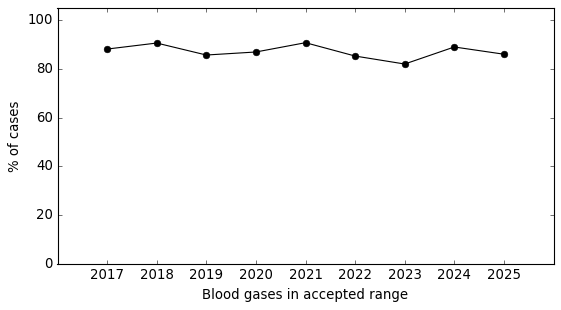

In [291]:
filetype='jpg'; dpi=200

fig, ax = plt.subplots(figsize = [8,4])

# plot the bar graph
ax.plot(np.arange(len(bg_in_target_years)), bg_in_target_years['%'], marker='o', color='black', )

ax.set_xticks(np.arange(len(bg_in_target_years)), bg_in_target_years.index, rotation=0)
ax.set_xlim(-1, len(bg_in_target_years))
ax.set_ylim(0, 105)
ax.set_xlabel('Blood gases in accepted range', size = 12)
ax.set_ylabel('% of cases', size = 12)
  
fig.savefig(os.path.join(DIR_WRITE, f'bg_in_target.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

### 22. Proportion of time spent with active ventilator alarms - `QI-6`

QI-6. Percentage of **time spent with active ventilator alarms**


In [293]:
alarms_all = set()
# Collect all alarms
for year in alarms_years:
    for case in alarms_years[year]:
        alarms_all.update(alarms_years[year][case].columns)
alarms_all

{'Alarm_CO2_check_airway_adapter',
 'Alarm_CO2_filterline_not_connected',
 'Alarm_CO2_module_not_connected',
 'Alarm_COM_interface',
 'Alarm_DCO2_high',
 'Alarm_DCO2_low',
 'Alarm_ETT_blocked',
 'Alarm_MV_high',
 'Alarm_MV_low',
 'Alarm_O2_sensor_cal_error',
 'Alarm_PEEP_high',
 'Alarm_PIP_not_reached',
 'Alarm_SPO2_module_not_connected',
 'Alarm_blender_defect',
 'Alarm_charge_battery_30min',
 'Alarm_etCO2_high',
 'Alarm_etCO2_low',
 'Alarm_flow_sensor_clean',
 'Alarm_flow_sensor_defect',
 'Alarm_flow_sensor_disconnected',
 'Alarm_input_pressure_O2_supply',
 'Alarm_input_pressure_air_supply',
 'Alarm_limited_volume',
 'Alarm_patient_disconnected',
 'Alarm_power_failure',
 'Alarm_pressure_high',
 'Alarm_pressure_low',
 'Alarm_susp',
 'Alarm_tube_occlusion',
 'Alarm_voltage_monit',
 'Alarm_volume_not_reached',
 'Oxyen_value_divergence',
 'Oxygen_sensor_defect',
 'Oxygen_sensor_used_up'}

In [294]:
alarms_to_consider = {'Alarm_DCO2_high', 'Alarm_DCO2_low', 'Alarm_ETT_blocked', 'Alarm_ETT_leak_high', 'Alarm_MV_high', 
                      'Alarm_MV_low', 'Alarm_PEEP_high', 'Alarm_PIP_not_reached',
                      'Alarm_limited_volume', 'Alarm_pressure_high', 'Alarm_pressure_low', 'Alarm_tube_occlusion', 
                      'Alarm_volume_not_reached'}

In [295]:
alarms_years_sel = defaultdict(dict)

for year in alarms_years:
    for case in alarms_years[year]:
        dta = alarms_years[year][case]
        # Keep only alarms relevant for QI
        dta = dta[sorted(set(alarms_years[year][case].columns) & alarms_to_consider)]
        # Keep only alarms which were active 
        for alarm in dta.columns:
            if dta[alarm].sum() == 0:
                del dta[alarm]
        # Eliminate duplicates, if more than one alarm is active
        dta['Alarm_active'] = np.where(dta.sum(axis=1) > 0, 1, 0)
        alarms_years_sel[year][case] = dta

In [296]:
alarm_duration = {}
for year in alarms_years_sel:
    for case in alarms_years_sel[year]:
        alarm_duration[year, case] = alarms_years_sel[year][case].sum()

alarm_duration = DataFrame(alarm_duration).T
alarm_duration = alarm_duration.fillna(0)
alarm_duration.head()

Alarm_DCO2_high  Alarm_DCO2_low  Alarm_ETT_blocked  \
2017 AL000003              0.0             0.0                0.0   
     AL000006              0.0             0.0                0.0   
     AL000008              0.0             0.0                0.0   
     AL000009              0.0             0.0                0.0   
     AL000011              0.0             0.0                0.0   

               Alarm_MV_high  Alarm_MV_low  Alarm_PEEP_high  \
2017 AL000003            0.0           0.0              0.0   
     AL000006            0.0           0.0              0.0   
     AL000008            0.0           0.0              0.0   
     AL000009            0.0           0.0              0.0   
     AL000011            0.0           0.0              0.0   

               Alarm_PIP_not_reached  Alarm_active  Alarm_limited_volume  \
2017 AL000003                    0.0           3.0                   0.0   
     AL000006                    0.0           1.0                   0.0   
     AL000008                    0.0          13.0                   0.0   
     AL000009                   20.0          23.0                   0.0   
     AL000011                    0.0         996.0                   0.0   

               Alarm_pressure_high  Alarm_pressure_low  Alarm_tube_occlusion  \
2017 AL000003                  2.0                 1.0                   0.0   
     AL000006                  0.0                 1.0                   0.0   
     AL000008                  0.0                 0.0                   0.0   
     AL000009                  1.0                 2.0                   0.0   
     AL000011                  1.0                 1.0                   2.0   

               Alarm_volume_not_reached  
2017 AL000003                       0.0  
     AL000006                       0.0  
     AL000008                      13.0  
     AL000009                       0.0  
     AL000011                     992.0

In [297]:
alarm_duration.sum()

Alarm_DCO2_high                  1.0
Alarm_DCO2_low                 403.0
Alarm_ETT_blocked             6489.0
Alarm_MV_high                 7277.0
Alarm_MV_low                 13337.0
Alarm_PEEP_high                 57.0
Alarm_PIP_not_reached         6163.0
Alarm_active                128557.0
Alarm_limited_volume          1882.0
Alarm_pressure_high           4961.0
Alarm_pressure_low            3127.0
Alarm_tube_occlusion           372.0
Alarm_volume_not_reached     84488.0
dtype: float64

In [298]:
alarm_duration['Alarm_active'].sum(), recording_duration_recordings['data points'].sum()

(128557.0, 2226489.0)

In [299]:
alarm_duration['Alarm_active'].sum() / recording_duration_recordings['data points'].sum()

0.057739786722503454

In [300]:
alarm_duration_years = alarm_duration.groupby(level=0).sum()
alarm_duration_years['data_point_years'] = recording_duration_stats_yearly_2['data points']

# Calculate percentage of time each alarms were active in each year
alarm_duration_years = alarm_duration_years.div(alarm_duration_years['data_point_years'], axis=0) * 100
alarm_duration_years = alarm_duration_years.drop('data_point_years', axis=1)
alarm_duration_years

,Alarm_DCO2_high,Alarm_DCO2_low,Alarm_ETT_blocked,Alarm_MV_high,Alarm_MV_low,Alarm_PEEP_high,Alarm_PIP_not_reached,Alarm_active,Alarm_limited_volume,Alarm_pressure_high,Alarm_pressure_low,Alarm_tube_occlusion,Alarm_volume_not_reached
2017,0.000000,0.000000,0.069317,0.000000,3.308447,0.025994,0.009627,6.070058,0.000000,0.114566,0.128525,0.053913,2.359669
2018,0.000000,0.000000,0.633723,0.000515,1.426650,0.000000,0.127260,5.942058,0.000000,0.014941,0.298829,0.041733,3.398406
2019,0.000000,0.000000,0.149889,0.000440,0.814498,0.000440,0.216701,4.305457,0.000000,0.764389,0.234723,0.010549,2.113828
2020,0.000000,0.000000,0.102356,0.205614,0.253410,0.000000,2.436253,5.504227,0.000000,0.019389,0.354864,0.000000,2.132341
2021,0.000269,0.004299,0.272980,0.697226,0.191032,0.000000,0.000000,3.652983,0.000000,0.092695,0.162014,0.016927,2.215541
2022,0.000000,0.003705,0.159312,1.398244,0.000741,0.000741,0.000000,6.195028,0.000000,0.140047,0.086696,0.007039,4.398503
2023,0.000000,0.171729,0.864566,0.193138,0.106590,0.000000,0.000000,7.229925,0.370333,0.269665,0.041452,0.000000,5.212452
2024,0.000000,0.000000,0.138436,0.007943,0.100990,0.000000,0.000000,5.783677,0.000000,0.550718,0.009078,0.001513,4.974998
2025,0.000000,0.000000,0.335650,0.002005,0.026467,0.000000,0.000000,8.394054,0.428685,0.056543,0.002807,0.027670,7.514226


In [301]:
alarm_duration_years['Alarm_active']

2017    6.070058
2018    5.942058
2019    4.305457
2020    5.504227
2021    3.652983
2022    6.195028
2023    7.229925
2024    5.783677
2025    8.394054
Name: Alarm_active, dtype: float64

In [302]:
alarm_duration_years['Alarm_active'].describe()

count    9.000000
mean     5.897496
std      1.408390
min      3.652983
25%      5.504227
50%      5.942058
75%      6.195028
max      8.394054
Name: Alarm_active, dtype: float64

In [303]:
alarm_duration_years['Alarm_volume_not_reached'] / alarm_duration_years['Alarm_active'] * 100

2017    38.873910
2018    57.192404
2019    49.096478
2020    38.740067
2021    60.650191
2022    71.000538
2023    72.095514
2024    86.017919
2025    89.518441
dtype: float64

In [304]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'alarm_durations.xlsx'))
alarm_duration.to_excel(writer, sheet_name='alarm_duration')
alarm_duration_years.to_excel(writer, sheet_name='yearly_stats')
writer.close()

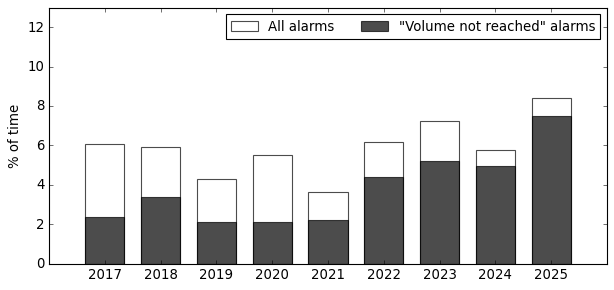

In [305]:
filetype='jpg'
dpi=200

fig, ax = plt.subplots(figsize = [9,4])
ax.bar(np.arange(len(alarm_duration_years)), alarm_duration_years['Alarm_active'], width=0.7, color='white', alpha=0.7)
ax.bar(np.arange(len(alarm_duration_years)), alarm_duration_years['Alarm_volume_not_reached'], width=0.7, color='black', alpha=0.7)

ax.set_xticks(np.arange(len(alarm_duration_years)), alarm_duration_years.index, rotation=0)
ax.set_xlim(-1, len(VG_in_target_years_pc))
ax.set_ylim(0, 13)
ax.set_xlabel('', size = 12)
ax.set_ylabel('% of time', size = 12)
ax.legend(['All alarms', '"Volume not reached" alarms'], fontsize = 12, ncols=2)
   
fig.savefig(os.path.join(DIR_WRITE, f'alarms_pc.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

### 23. Generate the figures of the paper

Figure 1 is not produced by this Notebook

#### A. Figure 2

##### Figure 2A

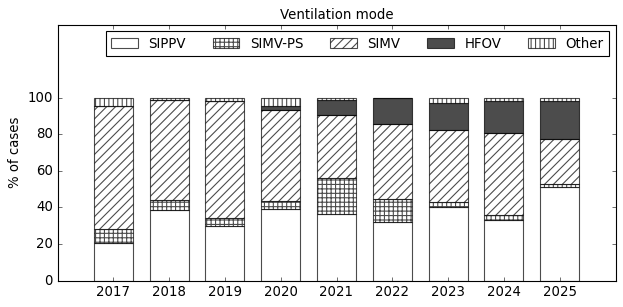

In [309]:
filetype='jpg'; dpi=200
fig, ax = plt.subplots(figsize = [9,4])

# SIPPV
ax.bar(np.arange(len(vent_modes_used_pc)), vent_modes_used_pc['SIPPV'], width=0.7, color='white', alpha=0.7)
bottom = vent_modes_used_pc['SIPPV'].copy()
# SIMV-PS
ax.bar(np.arange(len(vent_modes_used_pc)), vent_modes_used_pc['SIMV-PS'], bottom=bottom, width=0.7, color='white', hatch='+++', alpha=0.7)
bottom += vent_modes_used_pc['SIMV-PS']
# SIMV
ax.bar(np.arange(len(vent_modes_used_pc)), vent_modes_used_pc['SIMV'], bottom=bottom, width=0.7, color='white', hatch='///', alpha=0.7)
bottom += vent_modes_used_pc['SIMV']
# HFOV
ax.bar(np.arange(len(vent_modes_used_pc)), vent_modes_used_pc['HFOV'], bottom=bottom, width=0.7, color='black', alpha=0.7)
bottom += vent_modes_used_pc['HFOV']
# Other modes (PSV and IPPV)
ax.bar(np.arange(len(vent_modes_used_pc)), (vent_modes_used_pc['PSV'] + vent_modes_used_pc['IPPV']), bottom=bottom, width=0.7, 
    color='white', hatch='|||', alpha=0.7)

ax.set_xticks(np.arange(len(vent_modes_used_pc)), vent_modes_used_pc.index, rotation=0)
ax.set_yticks(np.arange(0, 110, 20), np.arange(0, 110, 20))
ax.set_xlim(-1, len(vent_modes_used_pc))
ax.set_ylim(0, 140)
ax.set_title('Ventilation mode', size = 12)
ax.set_ylabel('% of cases', size = 12)
ax.legend(['SIPPV', 'SIMV-PS', 'SIMV', 'HFOV', 'Other'], fontsize = 12, ncols=5)
   
fig.savefig(os.path.join(DIR_WRITE, f'Figure_2A.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

##### Figure 2B

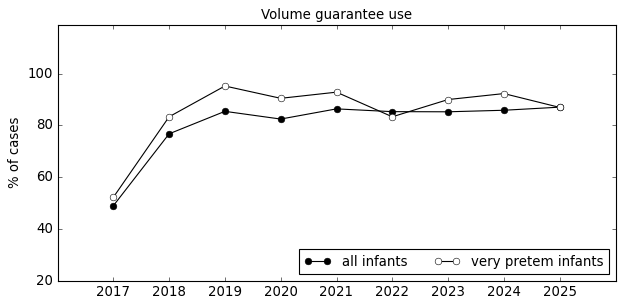

In [311]:
filetype='jpg'
dpi=200

fig, ax = plt.subplots(figsize = [9,4])

ax.plot(np.arange(len(VG_use)), VG_use['proportion'] * 100, marker='o', color='black', markerfacecolor='black')
ax.plot(np.arange(len(VG_use_below32)), VG_use_below32['proportion'] * 100, marker='o', color='black', markerfacecolor='white')

ax.set_xticks(np.arange(len(VG_use)), VG_use.index, rotation=0)
ax.set_xlim(-1, len(VG_use))
ax.set_ylim(20, 119)
ax.set_title('Volume guarantee use', size = 12)
ax.set_ylabel('% of cases', size = 12)
ax.legend(['all infants', 'very pretem infants'], loc='lower right', ncols=2, fontsize = 12,)

fig.savefig(os.path.join(DIR_WRITE, f'Figure_2B.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

##### Figure 2C

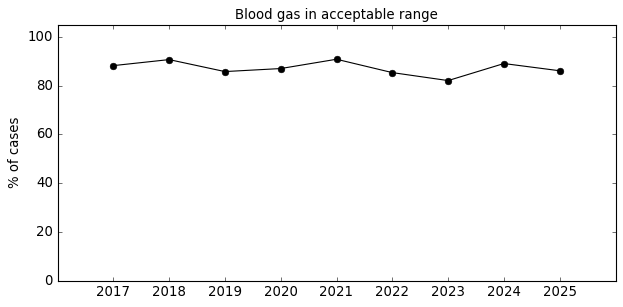

In [313]:
filetype='jpg'; dpi=200

fig, ax = plt.subplots(figsize = [9,4])

ax.plot(np.arange(len(bg_in_target_years)), bg_in_target_years['%'], marker='o', color='black', )

ax.set_xticks(np.arange(len(bg_in_target_years)), bg_in_target_years.index, rotation=0)
ax.set_xlim(-1, len(bg_in_target_years))
ax.set_ylim(0, 105)
ax.set_title('Blood gas in acceptable range', size = 12)
ax.set_ylabel('% of cases', size = 12)

fig.savefig(os.path.join(DIR_WRITE, f'Figure_2C.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

##### Figure 2 combined

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


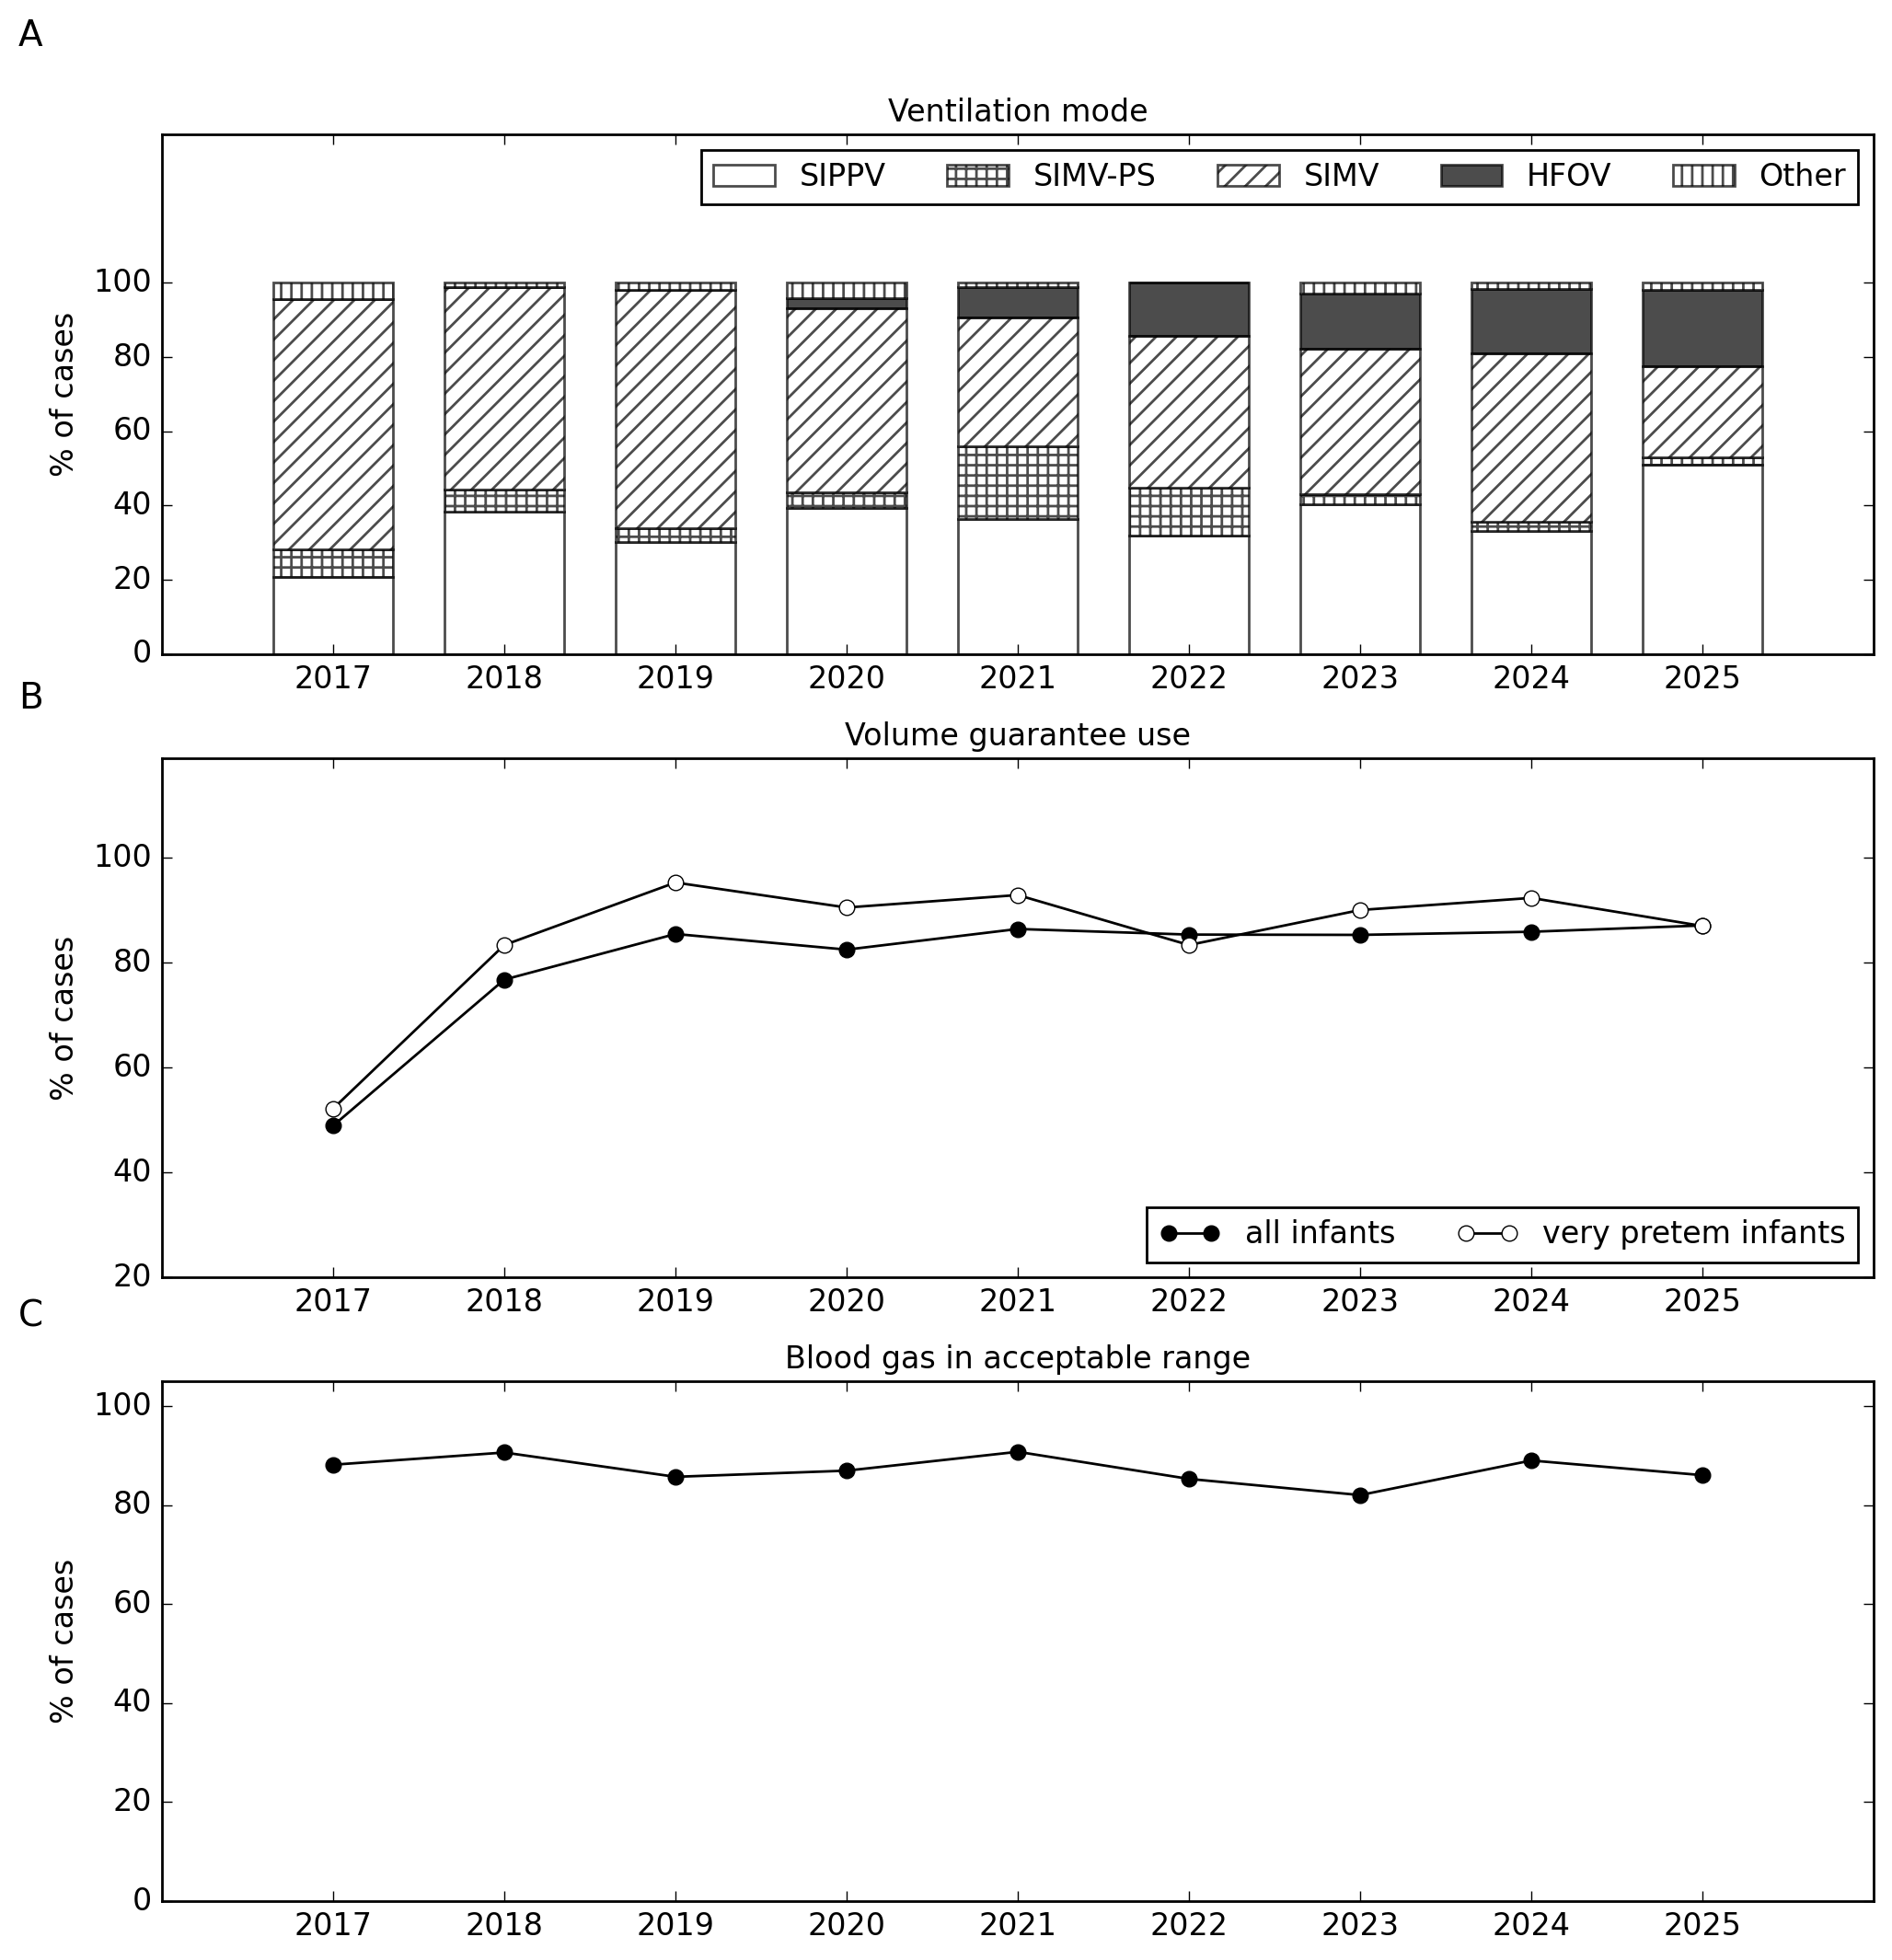

In [315]:
filetypes= ['jpg', 'eps', 'tiff']; dpis = [600, 600, 300]

fig, ax = plt.subplots(3,1, figsize = (12, 12), dpi = dpi)
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, hspace=None, wspace=None)

# Figure 2A

# SIPPV
ax[0].bar(np.arange(len(vent_modes_used_pc)), vent_modes_used_pc['SIPPV'], width=0.7, color='white', alpha=0.7)
bottom = vent_modes_used_pc['SIPPV'].copy()
# SIMV-PS
ax[0].bar(np.arange(len(vent_modes_used_pc)), vent_modes_used_pc['SIMV-PS'], bottom=bottom, width=0.7, color='white', hatch='+++', alpha=0.7)
bottom += vent_modes_used_pc['SIMV-PS']
# SIMV
ax[0].bar(np.arange(len(vent_modes_used_pc)), vent_modes_used_pc['SIMV'], bottom=bottom, width=0.7, color='white', hatch='///', alpha=0.7)
bottom += vent_modes_used_pc['SIMV']
# HFOV
ax[0].bar(np.arange(len(vent_modes_used_pc)), vent_modes_used_pc['HFOV'], bottom=bottom, width=0.7, color='black', alpha=0.7)
bottom += vent_modes_used_pc['HFOV']
# Other modes (PSV and IPPV)
ax[0].bar(np.arange(len(vent_modes_used_pc)), (vent_modes_used_pc['PSV'] + vent_modes_used_pc['IPPV']), bottom=bottom, width=0.7, 
    color='white', hatch='|||', alpha=0.7)

ax[0].set_xticks(np.arange(len(VG_use)), VG_use.index, rotation=0)
ax[0].set_yticks(np.arange(0, 110, 20), np.arange(0, 110, 20))
ax[0].set_xlim(-1, len(vent_modes_used_pc))
ax[0].set_ylim(0, 140)
ax[0].set_title('Ventilation mode', size = 12)
ax[0].set_ylabel('% of cases', size = 12)
ax[0].legend(['SIPPV', 'SIMV-PS', 'SIMV', 'HFOV', 'Other'], fontsize = 12, ncols=5)

# Figure 2B

ax[1].plot(np.arange(len(VG_use)), VG_use['proportion'] * 100, marker='o', color='black', markerfacecolor='black')
ax[1].plot(np.arange(len(VG_use_below32)), VG_use_below32['proportion'] * 100, marker='o', color='black', markerfacecolor='white')

ax[1].set_xticks(np.arange(len(VG_use)), VG_use.index, rotation=0)
ax[1].set_xlim(-1, len(VG_use))
ax[1].set_ylim(20, 119)
ax[1].set_title('Volume guarantee use', size = 12)
ax[1].set_ylabel('% of cases', size = 12)
ax[1].legend(['all infants', 'very pretem infants'], loc='lower right', ncols=2, fontsize = 12,)

# Figure 2C

ax[2].plot(np.arange(len(bg_in_target_years)), bg_in_target_years['%'], marker='o', color='black', )

ax[2].set_xticks(np.arange(len(VG_use)), VG_use.index, rotation=0)
ax[2].set_xlim(-1, len(bg_in_target_years))
ax[2].set_ylim(0, 105)
ax[2].set_title('Blood gas in acceptable range', size = 12)
ax[2].set_ylabel('% of cases', size = 12)

fig.text(0.06, 0.94, 'A', fontsize = 14)
fig.text(0.06, 0.64, 'B', fontsize = 14)
fig.text(0.06, 0.36, 'C', fontsize = 14)

for filetype, dpi in zip(filetypes, dpis):
    fig.savefig(os.path.join(DIR_WRITE, f'Figure_2.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)

plt.show();

#### B. Figure 3

##### Figure 3A

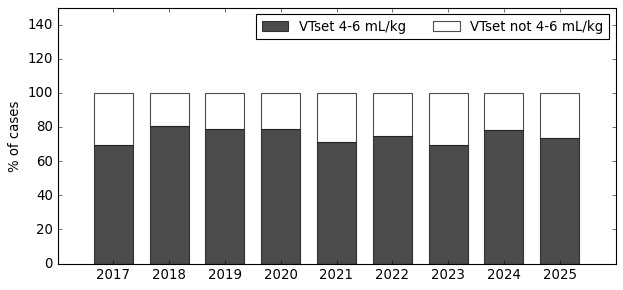

In [318]:
filetype='jpg'; dpi=200

fig, ax = plt.subplots(figsize = [9,4])

ax.bar(np.arange(len(VG_in_target_years_pc)), VG_in_target_years_pc['in_target_range'], width=0.7, color='black', alpha=0.7)
ax.bar(np.arange(len(VG_in_target_years_pc)), VG_in_target_years_pc['not_in_target_range'], 
       bottom=VG_in_target_years_pc['in_target_range'], width=0.7, color='white', alpha=0.7)

ax.set_xticks(np.arange(len(VG_in_target_years_pc)), VG_in_target_years_pc.index, rotation=0)
ax.set_xlim(-1, len(VG_in_target_years_pc))
ax.set_ylim(0, 150)
ax.set_xlabel('', size = 12)
ax.set_ylabel('% of cases', size = 12)
ax.legend(['VTset 4-6 mL/kg', 'VTset not 4-6 mL/kg'], fontsize = 12, ncols=2)
   
fig.savefig(os.path.join(DIR_WRITE, f'Figure_3A.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

##### Figure 3B

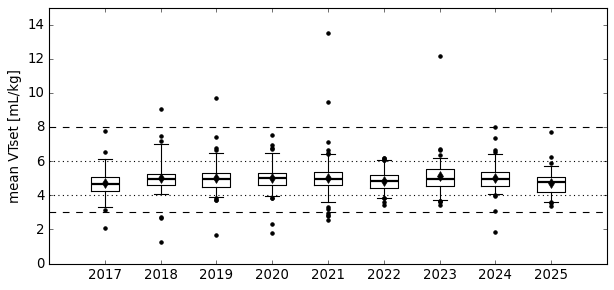

In [320]:
filetype='jpg'; dpi=200

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-'}; whiskerprops = {'color': 'black', 'linestyle': '-'}
capprops = {'color': 'black', 'linestyle': '-'}; flierprops = {'color': 'black', 'marker': '.'}

fig, ax = plt.subplots(figsize = [9,4])

VG_set_kg_mean = {}
for year in clin_dta_years:
    VG_set_kg_mean[year] = VG_in_target[VG_in_target['year'] == year]['VTset_mean [mL/kg]']

ax.boxplot(VG_set_kg_mean.values(), tick_labels = VG_set_kg_mean.keys(), whis = [5, 95], showfliers = True, showmeans = True, 
    meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)
ax.hlines(6, 0, len(clin_dta_years)+1, linestyle='dotted', color='black')
ax.hlines(4, 0, len(clin_dta_years)+1, linestyle='dotted', color='black')
ax.hlines(8, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')
ax.hlines(3, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')

ax.set_ylabel('mean VTset [mL/kg]')
ax.set_ylim(0, 15)

fig.savefig(os.path.join(DIR_WRITE, f'Figure_3B.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

##### Figure 3C

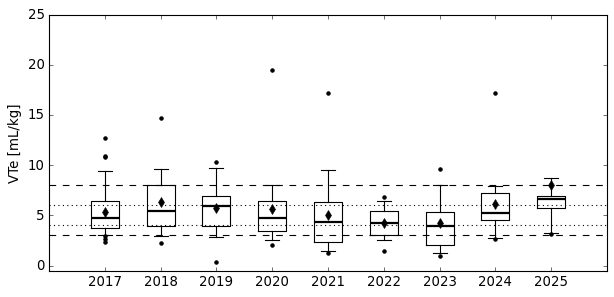

In [322]:
filetype='jpg'; dpi=200

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-'}; whiskerprops = {'color': 'black', 'linestyle': '-'}
capprops = {'color': 'black', 'linestyle': '-'}; flierprops = {'color': 'black', 'marker': '.'}

fig, ax = plt.subplots(figsize = [9,4])

VTemand_kg = {}
for year in clin_dta_years:
    VTemand_kg[year] = novg_VTemand[novg_VTemand['year'] == year]['VTemand_mean [mL/kg]'].dropna()

ax.boxplot(VTemand_kg.values(), tick_labels=VTemand_kg.keys(), whis = [5, 95], showfliers = True, showmeans = True, 
    meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.hlines(6, 0, len(clin_dta_years)+1, linestyle='dotted', color='black')
ax.hlines(4, 0, len(clin_dta_years)+1, linestyle='dotted', color='black')
ax.hlines(8, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')
ax.hlines(3, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')

ax.set_ylabel('VTe [mL/kg]')
ax.set_ylim(-0.5, 25)

fig.savefig(os.path.join(DIR_WRITE, f'Figure_3C.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

##### Figure 3D

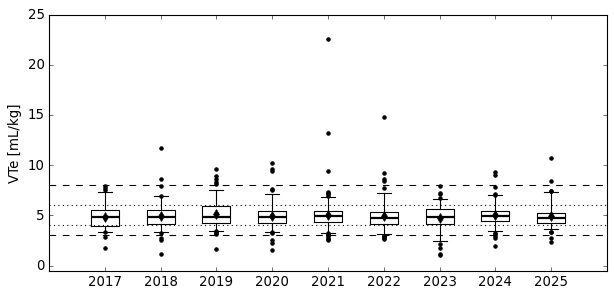

In [324]:
filetype='jpg'; dpi=200

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-'}; whiskerprops = {'color': 'black', 'linestyle': '-'}
capprops = {'color': 'black', 'linestyle': '-'}; flierprops = {'color': 'black', 'marker': '.'}

fig, ax = plt.subplots(figsize = [9,4])

VTemand_kg = {}
for year in clin_dta_years:
    VTemand_kg[year] = vg_VTemand[vg_VTemand['year'] == year]['VTemand_mean [mL/kg]'].dropna()

ax.boxplot(VTemand_kg.values(), tick_labels=VTemand_kg.keys(), whis = [5, 95], showfliers = True, showmeans = True, 
    meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.hlines(6, 0, len(clin_dta_years)+1, linestyle='dotted', color='black')
ax.hlines(4, 0, len(clin_dta_years)+1, linestyle='dotted', color='black')
ax.hlines(8, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')
ax.hlines(3, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')

ax.set_ylabel('VTe [mL/kg]')
ax.set_ylim(-0.5, 25)

fig.savefig(os.path.join(DIR_WRITE, f'Figure_3D.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

##### Figure 3 combined

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


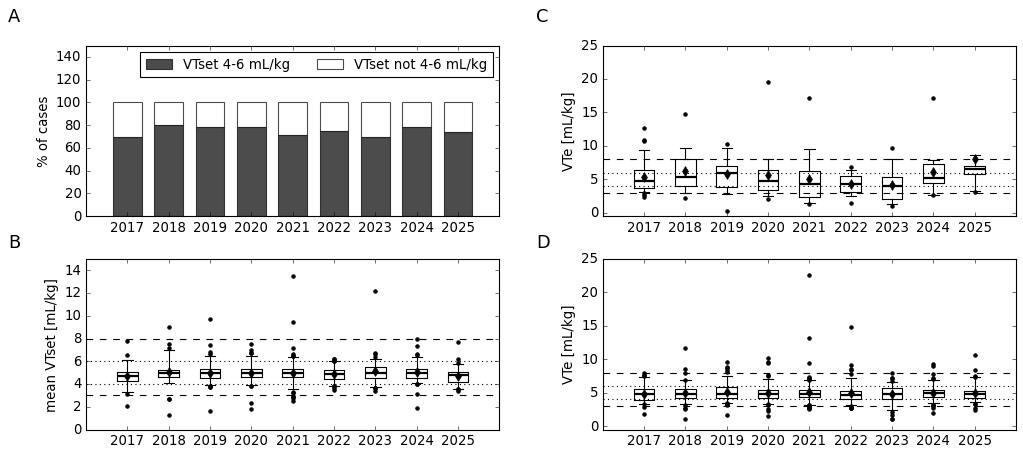

In [326]:
filetypes= ['jpg', 'eps', 'tiff']; dpis = [600, 600, 300]

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-'}; whiskerprops = {'color': 'black', 'linestyle': '-'}
capprops = {'color': 'black', 'linestyle': '-'}; flierprops = {'color': 'black', 'marker': '.'}

fig, ax = plt.subplots(2, 2, figsize = [15, 6])
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, hspace=0.25, wspace=0.25)

# Figure 3A

ax[0,0].bar(np.arange(len(VG_in_target_years_pc)), VG_in_target_years_pc['in_target_range'], width=0.7, color='black', alpha=0.7)
ax[0,0].bar(np.arange(len(VG_in_target_years_pc)), VG_in_target_years_pc['not_in_target_range'], 
       bottom=VG_in_target_years_pc['in_target_range'], width=0.7, color='white', alpha=0.7)

ax[0,0].set_xticks(np.arange(len(VG_in_target_years_pc)), VG_in_target_years_pc.index, rotation=0)
ax[0,0].set_xlim(-1, len(VG_in_target_years_pc))
ax[0,0].set_ylim(0, 150)
ax[0,0].set_xlabel('', size = 12)
ax[0,0].set_ylabel('% of cases', size = 12)
ax[0,0].legend(['VTset 4-6 mL/kg', 'VTset not 4-6 mL/kg'], fontsize = 12, ncols=2)

# Figure 3B

VG_set_kg_mean = {}
for year in clin_dta_years:
    VG_set_kg_mean[year] = VG_in_target[VG_in_target['year'] == year]['VTset_mean [mL/kg]']

ax[1,0].boxplot(VG_set_kg_mean.values(), tick_labels = VG_set_kg_mean.keys(), whis = [5, 95], showfliers = True, showmeans = True, 
    meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)
ax[1,0].hlines(6, 0, len(clin_dta_years)+1, linestyle='dotted', color='black')
ax[1,0].hlines(4, 0, len(clin_dta_years)+1, linestyle='dotted', color='black')
ax[1,0].hlines(8, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')
ax[1,0].hlines(3, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')

ax[1,0].set_ylabel('mean VTset [mL/kg]')
ax[1,0].set_ylim(0, 15)

# Figure 3C

VTemand_kg = {}
for year in clin_dta_years:
    VTemand_kg[year] = novg_VTemand[novg_VTemand['year'] == year]['VTemand_mean [mL/kg]'].dropna()

ax[0,1].boxplot(VTemand_kg.values(), tick_labels=VTemand_kg.keys(), whis = [5, 95], showfliers = True, showmeans = True, 
    meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)
ax[0,1].hlines(6, 0, len(clin_dta_years)+1, linestyle='dotted', color='black')
ax[0,1].hlines(4, 0, len(clin_dta_years)+1, linestyle='dotted', color='black')
ax[0,1].hlines(8, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')
ax[0,1].hlines(3, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')

ax[0,1].set_ylabel('VTe [mL/kg]')
ax[0,1].set_ylim(-0.5, 25)

# Figure 3D

VTemand_kg = {}
for year in clin_dta_years:
    VTemand_kg[year] = vg_VTemand[vg_VTemand['year'] == year]['VTemand_mean [mL/kg]'].dropna()

ax[1,1].boxplot(VTemand_kg.values(), tick_labels=VTemand_kg.keys(), whis = [5, 95], showfliers = True, showmeans = True, 
    meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)
ax[1,1].hlines(6, 0, len(clin_dta_years)+1, linestyle='dotted', color='black')
ax[1,1].hlines(4, 0, len(clin_dta_years)+1, linestyle='dotted', color='black')
ax[1,1].hlines(8, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')
ax[1,1].hlines(3, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')

ax[1,1].set_ylabel('VTe [mL/kg]')
ax[1,1].set_ylim(-0.5, 25)

fig.text(0.06, 0.95, 'A', fontsize = 16); fig.text(0.06, 0.48, 'B', fontsize = 16);
fig.text(0.5, 0.95, 'C', fontsize = 16); fig.text(0.5, 0.48, 'D', fontsize = 16)

for filetype, dpi in zip(filetypes, dpis):
    fig.savefig(os.path.join(DIR_WRITE, f'Figure_3.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

#### C. Figure 4

##### Figure 4A

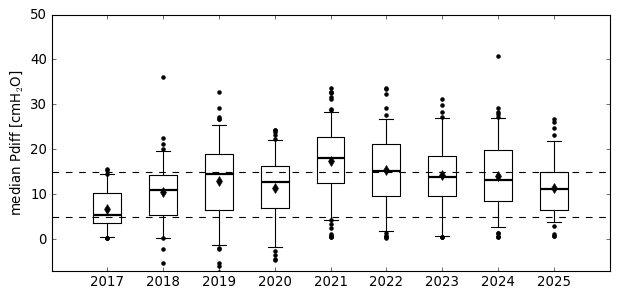

In [329]:
filetype='jpg'; dpi=200

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-'}; whiskerprops = {'color': 'black', 'linestyle': '-'}
capprops = {'color': 'black', 'linestyle': '-'}; flierprops = {'color': 'black', 'marker': '.'}

fig, ax = plt.subplots(figsize = [9,4])

Pdiff_median.groupby('year').boxplot(ax=ax, column=['Pdiff (median)'], whis = [5, 95], subplots=False, showfliers = True, 
    showmeans = True, grid=False, meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, 
    capprops=capprops, flierprops = flierprops)
ax.hlines(5, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')
ax.hlines(15, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')

ax.set_xticks(np.arange(1, len(Pdiff_median.groupby('year').groups)+1), np.arange(2017, 2026), rotation=0)
ax.set_ylabel('median Pdiff [cmH$_2$O]')
ax.set_ylim(-7,50)

fig.savefig(os.path.join(DIR_WRITE, f'Figure_4A.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

##### Figure 4B

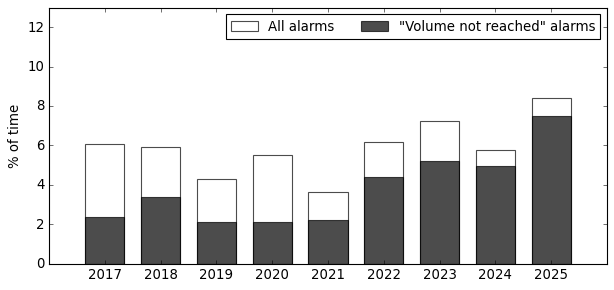

In [331]:
filetype='jpg'; dpi=200

fig, ax = plt.subplots(figsize = [9,4])

ax.bar(np.arange(len(alarm_duration_years)), alarm_duration_years['Alarm_active'], width=0.7, color='white', alpha=0.7)
ax.bar(np.arange(len(alarm_duration_years)), alarm_duration_years['Alarm_volume_not_reached'], width=0.7, color='black', alpha=0.7)

ax.set_xticks(np.arange(len(alarm_duration_years)), alarm_duration_years.index, rotation=0)
ax.set_xlim(-1, len(VG_in_target_years_pc))
ax.set_ylim(0, 13)
ax.set_xlabel('', size = 12)
ax.set_ylabel('% of time', size = 12)
ax.legend(['All alarms', '"Volume not reached" alarms'], fontsize = 12, ncols=2)
   
fig.savefig(os.path.join(DIR_WRITE, f'Figure_4B.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

##### Figure 4 Combined

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


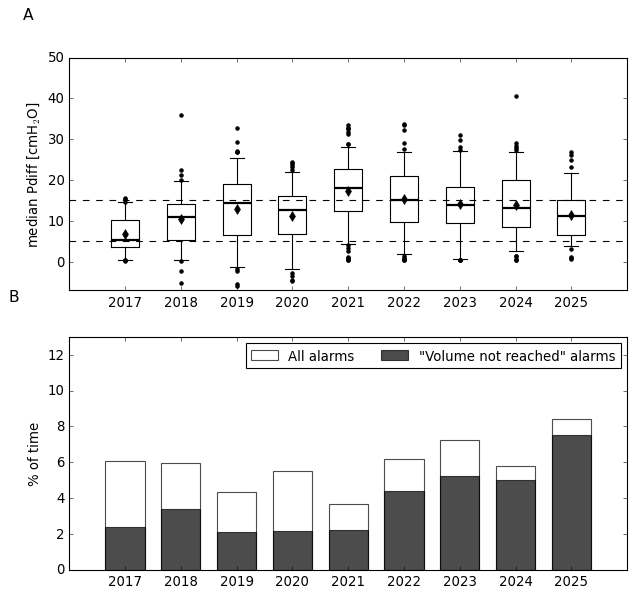

In [333]:
filetypes= ['jpg', 'eps', 'tiff']; dpis = [600, 600, 300]

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-'}; whiskerprops = {'color': 'black', 'linestyle': '-'}
capprops = {'color': 'black', 'linestyle': '-'}; flierprops = {'color': 'black', 'marker': '.'}

fig, ax = plt.subplots(2, figsize = [9, 8])
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, hspace=0.20, wspace=None)

# Figure 4A

Pdiff_median.groupby('year').boxplot(ax=ax[0], column=['Pdiff (median)'], whis = [5, 95], subplots=False, showfliers = True, 
    showmeans = True, grid=False, meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, 
    capprops=capprops, flierprops = flierprops)
ax[0].hlines(5, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')
ax[0].hlines(15, 0, len(clin_dta_years)+1, linestyle='dashed', color='black')

ax[0].set_xticks(np.arange(1, len(Pdiff_median.groupby('year').groups)+1), np.arange(2017, 2026), rotation=0)
ax[0].set_ylabel('median Pdiff [cmH$_2$O]')
ax[0].set_ylim(-7,50)

# Figure 4B

ax[1].bar(np.arange(len(alarm_duration_years)), alarm_duration_years['Alarm_active'], width=0.7, color='white', alpha=0.7)
ax[1].bar(np.arange(len(alarm_duration_years)), alarm_duration_years['Alarm_volume_not_reached'], width=0.7, color='black', alpha=0.7)

ax[1].set_xticks(np.arange(len(alarm_duration_years)), alarm_duration_years.index, rotation=0)
ax[1].set_xlim(-1, len(VG_in_target_years_pc))
ax[1].set_ylim(0, 13)
ax[1].set_xlabel('', size = 12)
ax[1].set_ylabel('% of time', size = 12)
ax[1].legend(['All alarms', '"Volume not reached" alarms'], fontsize = 12, ncols=2)

fig.text(0.06, 0.96, 'A', fontsize = 14); fig.text(0.04, 0.52, 'B', fontsize = 14)

for filetype, dpi in zip(filetypes, dpis):
    fig.savefig(os.path.join(DIR_WRITE, f'Figure_4.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)

plt.show();

### 24. Online resources of the paper

Online resources 1, 2 and 4 are not produced by this Notebook

#### A. Online resource 3

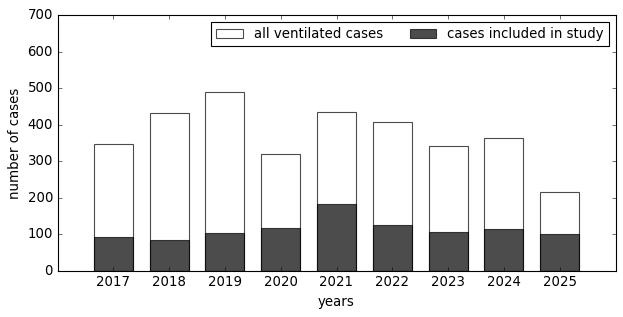

In [336]:
filetype='pdf'; dpi=600

fig, ax = plt.subplots(figsize = [9,4])

ax.bar(np.arange(len(service_activity.index)), service_activity['Number of cases'],  width=0.7, color='white', alpha=0.7)
ax.bar(np.arange(len(vent_modes_used)), vent_modes_used['total'], width=0.7, color='black', alpha=0.7)

ax.set_xticks(np.arange(len(vent_modes_used)), vent_modes_used.index, rotation=0)
ax.set_xlim(-1, len(vent_modes_used))
ax.set_ylim(0, 700)
ax.set_xlabel('years', size = 12)
ax.set_ylabel('number of cases', size = 12)
ax.legend(['all ventilated cases', 'cases included in study',], fontsize = 12, ncols=2)
   
fig.savefig(os.path.join(DIR_WRITE, f'Online_resource_3.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)
plt.show();

#### B. Online resource 5

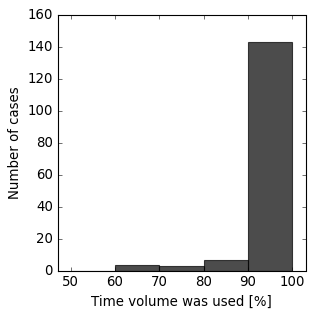

In [338]:
filetype='pdf'; dpi=600
bins = np.arange(50, 105, 10)

# Of those who had VG during >50% of time
dta = VG_duration_below32[VG_duration_below32['proportion'] > 0.5]

fig, ax = plt.subplots(figsize = [4,4])
ax.hist(dta['proportion'] * 100, bins=bins, color = 'black', alpha = 0.7) 

ax.set_xlim(47, 103)
ax.set_ylim(0, 160)
ax.set_xlabel('Time volume was used [%]', size = 12)
ax.set_ylabel('Number of cases', size = 12)
   
fig.savefig(os.path.join(DIR_WRITE, f'Online_ressource_5.{filetype}'), dpi = dpi, format = filetype, 
    bbox_inches='tight', pad_inches=0.1)

plt.show();

#### C. Online resource 6

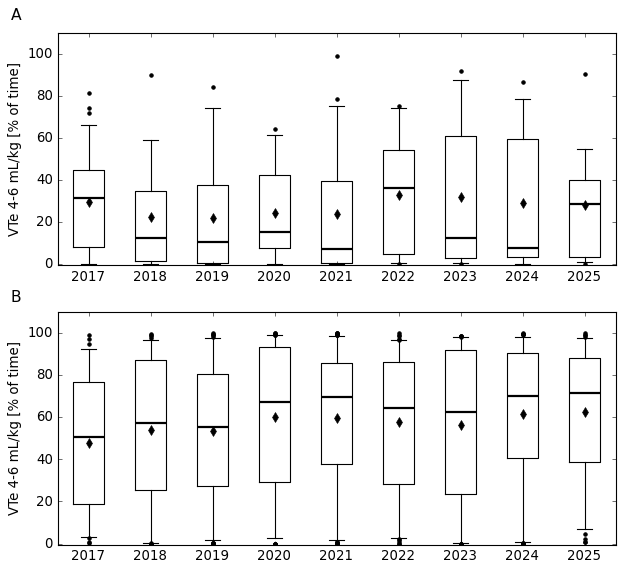

In [603]:
filetype='pdf'; dpis = [600, 600, 300]

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-'}; whiskerprops = {'color': 'black', 'linestyle': '-'}
capprops = {'color': 'black', 'linestyle': '-'}; flierprops = {'color': 'black', 'marker': '.'}

fig, ax = plt.subplots(2, figsize = [9, 8])
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, hspace=0.20, wspace=None)

# Supplementary Figure 4A

VTemand_kg = {}
for year in clin_dta_years:
    VTemand_kg[year] = novg_VTemand[novg_VTemand['year'] == year]['VTemand_4_6 [%]'].dropna()
ax[0].boxplot(VTemand_kg.values(), tick_labels=VTemand_kg.keys(), whis = [5, 95], showfliers = True, showmeans = True, 
    meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)
ax[0].set_ylabel('VTe 4-6 mL/kg [% of time]')
ax[0].set_ylim(-0.5, 110)

# Supplementary Figure 4B

VTemand_kg = {}
for year in clin_dta_years:
    VTemand_kg[year] = vg_VTemand[vg_VTemand['year'] == year]['VTemand_4_6 [%]'].dropna()
ax[1].boxplot(VTemand_kg.values(), tick_labels=VTemand_kg.keys(), whis = [5, 95], showfliers = True, showmeans = True, 
    meanprops = meanprops, medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)
ax[1].set_ylabel('VTe 4-6 mL/kg [% of time]')
ax[1].set_ylim(-0.5, 110)

fig.text(0.06, 0.92, 'A', fontsize = 14); fig.text(0.06, 0.48, 'B', fontsize = 14)

fig.savefig(os.path.join(DIR_WRITE, f'Online_resource_6.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1)

plt.show();